# PARCIAL PRÁCTICO

# Ejercicio 1: Análisis Exploratorio de Datos

## *1.1 Carga y preparación de datos*

In [2]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')
 
# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(4999, 6)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4999 entries, 2010-07-18 to 2024-03-24
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     4999 non-null   float64
 1   Open      4999 non-null   float64
 2   High      4999 non-null   float64
 3   Low       4999 non-null   float64
 4   Vol.      4993 non-null   float64
 5   Change %  4999 non-null   float64
dtypes: float64(6)
memory usage: 273.4 KB
None
Price       0
Open        0
High        0
Low         0
Vol.        6
Change %    0
dtype: int64


In [4]:
print(df.head())

            Price  Open  High  Low    Vol.  Change %
Date                                                
2010-07-18    0.1   0.0   0.1  0.1    80.0       0.0
2010-07-19    0.1   0.1   0.1  0.1   570.0       0.0
2010-07-20    0.1   0.1   0.1  0.1   260.0       0.0
2010-07-21    0.1   0.1   0.1  0.1   580.0       0.0
2010-07-22    0.1   0.1   0.1  0.1  2160.0       0.0


In [5]:
print(df[df.isnull().any(axis=1)])

            Price  Open  High   Low  Vol.  Change %
Date                                               
2011-06-20   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-21   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-22   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-23   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-24   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-25   17.5  17.5  17.5  17.5   NaN       0.0


In [6]:
# Contar valores nulos en cada columna
valores_faltantes = df.isnull().sum()

# Filtrar solo las columnas que tienen valores nulos
valores_faltantes = valores_faltantes[valores_faltantes > 0]

# Mostrar resultado
print("Valores faltantes por columna:")
print(valores_faltantes)

Valores faltantes por columna:
Vol.    6
dtype: int64


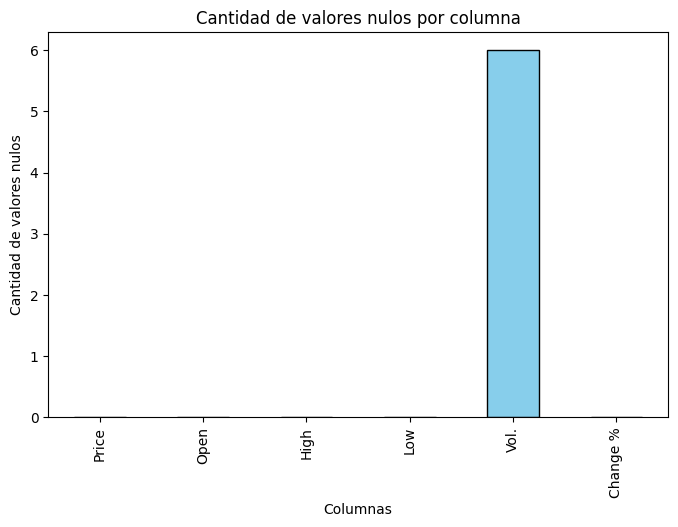

In [7]:
# Gráfica de Barras (Conteo de Valores Faltantes)

df.isnull().sum().plot(kind='bar', color='skyblue', figsize=(8, 5), edgecolor='black')

# Título y etiquetas
plt.title("Cantidad de valores nulos por columna")
plt.xlabel("Columnas")
plt.ylabel("Cantidad de valores nulos")
plt.show()

In [8]:
# Contar valores faltantes por columna
missing_values = df.isnull().sum()

# Mostrar solo columnas con valores faltantes
missing_values = missing_values[missing_values > 0]

# Imprimir el resultado
print(missing_values)

Vol.    6
dtype: int64


In [9]:
# Imputación combinada: Imputación por propagación hacia adelante y hacia atras (ffill + bfill).
df.fillna(method='bfill', inplace=True)  # Usa el siguiente valor disponible
df.fillna(method='ffill', inplace=True)  # Usa el valor anterior si sigue habiendo nulos

In [10]:
# Verificar si los valores faltantes fueron imputados
missing_values_after = df['Price'].isna().sum()
print(f"Número de valores faltantes después de la imputación: {missing_values_after}")

Número de valores faltantes después de la imputación: 0


## *1.2 Visualización y análisis descriptivo*

In [11]:
# Graficar la serie de precios
import plotly.express as px  
graph_price = px.line(df, x=df.index, y='Price', title='Serie Temporal del Precio de Bitcoin')
graph_price.show()

In [12]:
# Gráfico de velas con Plotly
import plotly.graph_objects as go
fig_candlestick = go.Figure(data=[
    go.Candlestick(x=df.index,
                   open=df['Open'], high=df['High'],
                   low=df['Low'], close=df['Price'])
])
fig_candlestick.update_layout(title='Gráfico de Velas de Bitcoin')
fig_candlestick.show()

In [22]:
import plotly.express as px

# Crear histograma con escala logarítmica en Y
g = px.histogram(df, x='Vol.', title='Histograma del Vol.n Tradeado')

# Ajustar escala logarítmica en el eje Y y autoajuste en X
g.update_layout(
    yaxis_type="log",
    
)

g.show()


In [14]:
# Histograma del Vol.n tradeado
g = px.histogram(df, x='Vol.', nbins=50, title='Histograma del Vol.n Tradeado')
g.show()

In [ ]:
# Conviersión de todas las columnas de tipo Period a str antes de graficar:

df['Year'] = df.index.to_period('Y').astype(str)
df['Month'] = df.index.to_period('M').astype(str)  # Convertir 'Month' a string
df['Week'] = df.index.to_period('W').astype(str)   # Convertir 'Week' a string

# Gráficos de subseries por semana, mes y año.
fig_weekly = px.box(df, x='Week', y='Price', title='Distribución del Precio por Semana')
fig_weekly.show()

fig_monthly = px.box(df, x='Month', y='Price', title='Distribución del Precio por Mes')
fig_monthly.show()

fig_yearly = px.box(df, x='Year', y='Price', title='Distribución del Precio por Año')
fig_yearly.show()

## *1.3 Análisis de estacionariedad*

<Figure size 1000x500 with 0 Axes>

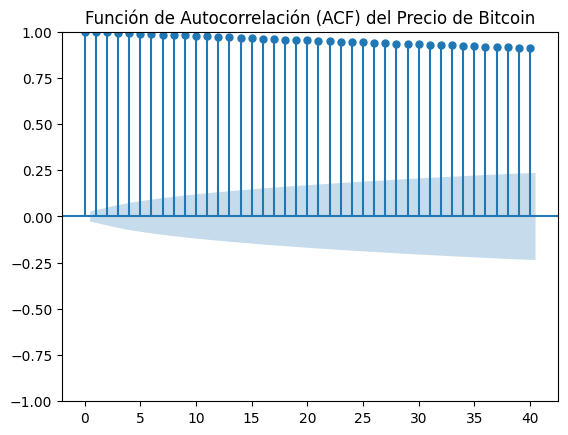

In [25]:
# Análisis de estacionariedad con ACF
plt.figure(figsize=(10,5))
sm.graphics.tsa.plot_acf(df['Price'].dropna(), lags=40)
plt.title('Función de Autocorrelación (ACF) del Precio de Bitcoin')
plt.show()

In [26]:
# Análisis de estacionariedad con Dickey Fuller
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Price'])
print(f"Dickey-Fuller p-value: {result[1]}")

Dickey-Fuller p-value: 0.942637225609157


In [27]:
# Prueba de independencia de residuos con Ljung-Box
ljung_box_results = q_stat(acf(df['Price'], nlags=20, fft=True)[1:], len(df))
print(f"Ljung-Box p-values: {ljung_box_results[1]}")

Ljung-Box p-values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


                                     SARIMAX Results                                      
Dep. Variable:                              Price   No. Observations:                 4999
Model:             SARIMAX(2, 1, 1)x(1, 0, 1, 48)   Log Likelihood              -39386.839
Date:                            Sun, 16 Mar 2025   AIC                          78785.678
Time:                                    17:44:42   BIC                          78824.718
Sample:                                         0   HQIC                         78799.368
                                           - 4999                                         
Covariance Type:                           approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9279      0.019     47.621      0.000       0.890       0.966
ar.L2          0.0597      0.015   

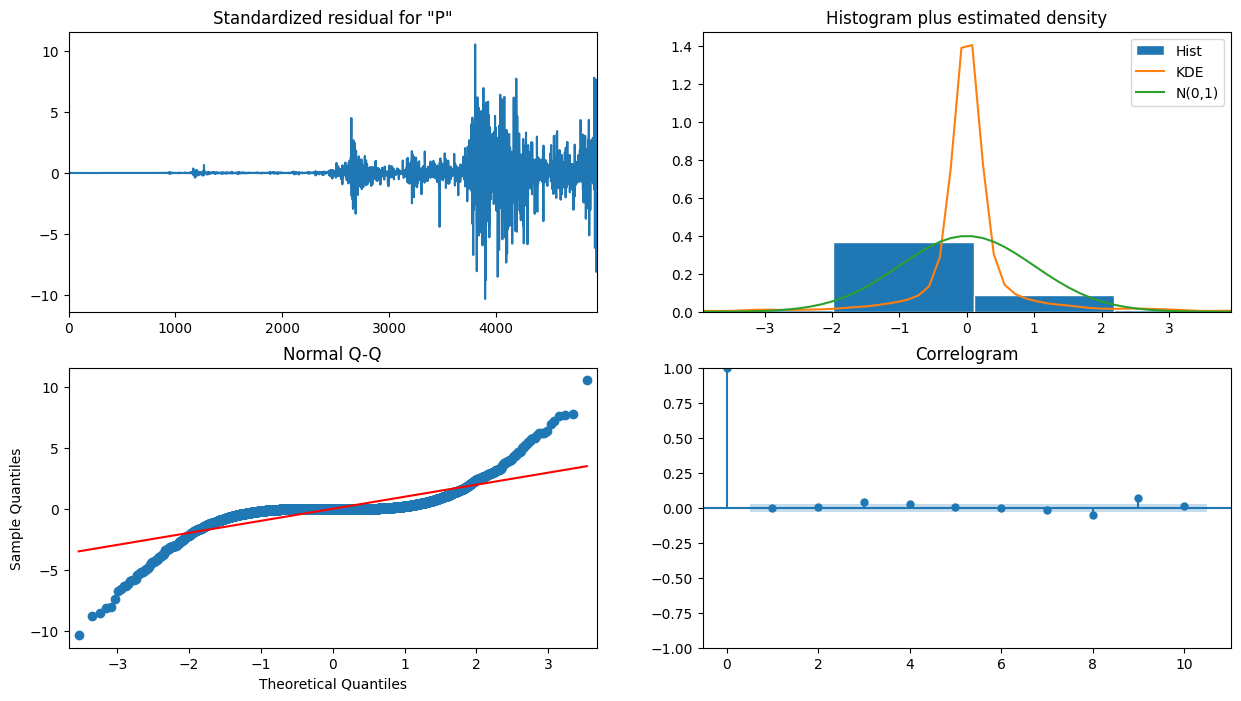

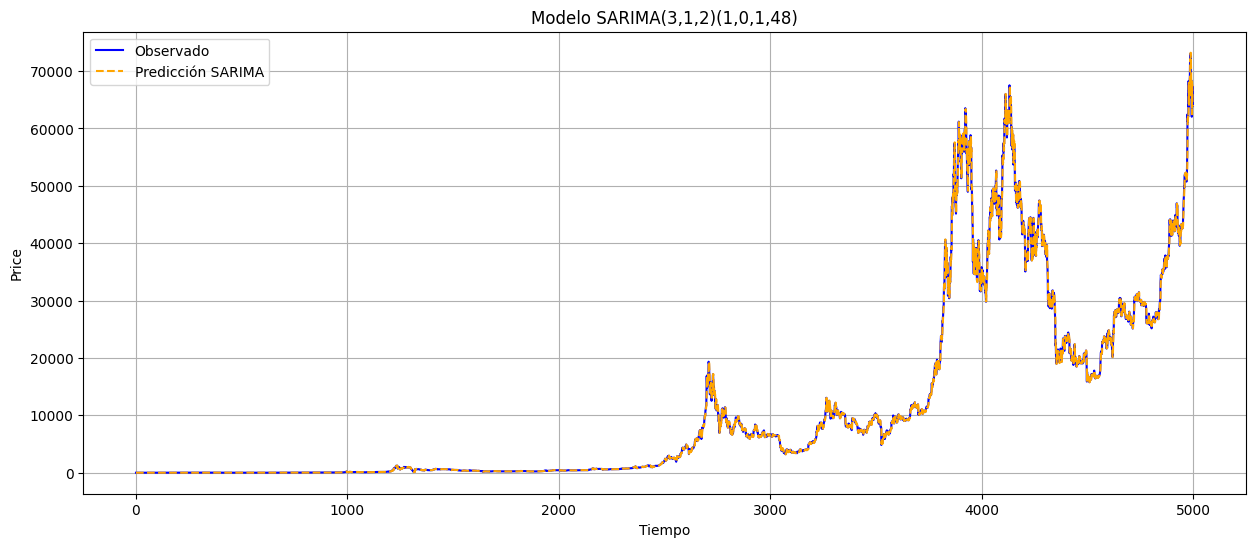

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
 
# Ajustamos el modelo SARIMA(3,1,2)(1,0,1,48)
order = (2, 1, 1)  # ARIMA(p,d,q)
seasonal_order = (1, 0, 1, 48)  # Estacional (P,D,Q,s)
 
# Entrenamos el modelo
model = SARIMAX(df['Price'], order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(low_memory=True)
 
# Resumen del modelo
print(results.summary())
 
# Diagnóstico de residuos
results.plot_diagnostics(figsize=(15, 8))
plt.show()
 
# Predicción
df['forecast'] = results.predict(start=0, end=len(df)-1, dynamic=False)
 
# Visualización
plt.figure(figsize=(15,6))
plt.plot(df['Price'], label='Observado', color='blue')
plt.plot(df['forecast'], label='Predicción SARIMA', color='orange', linestyle='dashed')
plt.legend()
plt.title('Modelo SARIMA(3,1,2)(1,0,1,48)')
plt.xlabel('Tiempo')
plt.ylabel('Price')
plt.grid()
plt.show()
 
 

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np
price_series = df["Price"]
log_price = np.log(price_series + 1)  # Evita log(0)
log_price_diff = log_price.diff().dropna()
ljung_box_log = acorr_ljungbox(log_price_diff, lags=[1], return_df=True)
print(ljung_box_log)
 

   lb_stat  lb_pvalue
1  0.41889   0.517492


## *1.4 Análisis de agregaciones y estadísticas móviles*

In [ ]:
import pandas as pd
import plotly.graph_objects as go
import plotly.subplots as sp

# Asegurar que la columna 'Date' está en formato datetime
df['Date'] = pd.to_datetime(df.index)

# Crear columnas adicionales para semana, mes, día y año
df['Week'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day

# Agrupar por semana, mes, día y año
weekly_data = df.groupby('Week').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
monthly_data = df.groupby('Month').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
daily_data = df.groupby('Day').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
yearly_data = df.groupby('Year').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()

# Crear subgráficos 2x2
fig = sp.make_subplots(rows=2, cols=2, subplot_titles=[
    "Precio Promedio Diario", "Precio Promedio Semanal", 
    "Precio Promedio Mensual", "Precio Promedio Anual"])

# Configuración de línea verde
line_style = dict(color='green', width=2)

# Gráfico Diario
fig.add_trace(go.Scatter(x=daily_data['Day'].sort_values(), y=daily_data['Price'], mode='lines', name='Diario', line=line_style),
              row=1, col=1)

# Gráfico Semanal
fig.add_trace(go.Scatter(x=weekly_data['Week'].sort_values(), y=weekly_data['Price'], mode='lines', name='Semanal', line=line_style),
              row=1, col=2)

# Gráfico Mensual
fig.add_trace(go.Scatter(x=monthly_data['Month'].sort_values(), y=monthly_data['Price'], mode='lines', name='Mensual', line=line_style),
              row=2, col=1)

# Gráfico Anual
fig.add_trace(go.Scatter(x=yearly_data['Year'].sort_values(), y=yearly_data['Price'], mode='lines', name='Anual', line=line_style),
              row=2, col=2)

# Ajustes generales
fig.update_layout(
    title="Series de Tiempo del Precio Promedio",
    template="plotly_white",  # Fondo claro
    height=800, width=1000
)

# Mostrar figura
fig.show()


In [ ]:
# Agregación por grupos

import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
 
# Asegurarse de que la columna 'Date' está en formato datetime
df['Date'] = df.index
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = pd.to_datetime(df['Date'])
 
# Crear columnas adicionales para semana, mes, día y año
df['Week'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day
 
# Agrupar por semana, mes, día y año
weekly_data = df.groupby('Week').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
monthly_data = df.groupby('Month').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
daily_data = df.groupby('Day').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
yearly_data = df.groupby('Year').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
 
# Gráfico de serie de tiempo para cada subserie
fig_weekly = go.Figure()
fig_weekly.add_trace(go.Scatter(x=weekly_data['Week'], y=weekly_data['Price'], mode='lines', name='Precio Promedio Semanal'))
fig_weekly.update_layout(title="Serie de Tiempo - Precio Promedio Semanal",
                         xaxis_title="Semana", yaxis_title="Precio de Cierre",
                         template="plotly_dark")
fig_monthly = go.Figure()
fig_monthly.add_trace(go.Scatter(x=monthly_data['Month'], y=monthly_data['Price'], mode='lines', name='Precio Promedio Mensual'))
fig_monthly.update_layout(title="Serie de Tiempo - Precio Promedio Mensual",
                          xaxis_title="Mes", yaxis_title="Precio de Cierre",
                          template="plotly_dark")
fig_daily = go.Figure()
fig_daily.add_trace(go.Scatter(x=daily_data['Day'], y=daily_data['Price'], mode='lines', name='Precio Promedio Diario'))
fig_daily.update_layout(title="Serie de Tiempo - Precio Promedio Diario",
                        xaxis_title="Día", yaxis_title="Precio de Cierre",
                        template="plotly_dark")
fig_yearly = go.Figure()
fig_yearly.add_trace(go.Scatter(x=yearly_data['Year'], y=yearly_data['Price'], mode='lines', name='Precio Promedio Anual'))
fig_yearly.update_layout(title="Serie de Tiempo - Precio Promedio Anual",
                         xaxis_title="Año", yaxis_title="Precio de Cierre",
                         template="plotly_dark")
 
# Mostrar los gráficos de series de tiempo
fig_weekly.show()
fig_monthly.show()
fig_daily.show()
fig_yearly.show()
 
# Calcular estadísticas móviles (promedio móvil y desviación estándar)
df['Moving_Avg_7'] = df['Price'].rolling(window=7).mean()
df['Moving_Std_7'] = df['Price'].rolling(window=7).std()
df['Moving_Avg_30'] = df['Price'].rolling(window=30).mean()
df['Moving_Std_30'] = df['Price'].rolling(window=30).std()
 
# Boxplot para analizar las subseries por semana, mes, día y año
fig_weekly_box = px.box(df, x='Week', y='Price', title="Boxplot del Precio de Cierre por Semana")
fig_monthly_box = px.box(df, x='Month', y='Price', title="Boxplot del Precio de Cierre por Mes")
fig_daily_box = px.box(df, x='Day', y='Price', title="Boxplot del Precio de Cierre por Día")
fig_yearly_box = px.box(df, x='Year', y='Price', title="Boxplot del Precio de Cierre por Año")
 
# Mostrar los boxplots
fig_weekly_box.show()
fig_monthly_box.show()
fig_daily_box.show()
fig_yearly_box.show()
 
# Calcular distribución de frecuencias para diferentes lags
df['Lag_1'] = df['Price'].shift(1)
df['Lag_7'] = df['Price'].shift(7)
df['Lag_30'] = df['Price'].shift(30)
 
# Histograma para visualizar la distribución de frecuencias de los lags
fig_lag_1 = px.histogram(df, x='Lag_1', title='Distribución de Frecuencia - Lag 1')
fig_lag_7 = px.histogram(df, x='Lag_7', title='Distribución de Frecuencia - Lag 7')
fig_lag_30 = px.histogram(df, x='Lag_30', title='Distribución de Frecuencia - Lag 30')
 
# Mostrar histogramas
fig_lag_1.show()
fig_lag_7.show()
fig_lag_30.show()

 

In [ ]:
# Cálculo de estadísticos móviles
df['Rolling_Mean_7'] = df['Price'].rolling(window=7).mean()
df['Rolling_Std_7'] = df['Price'].rolling(window=7).std()

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Paso 1: Definir los lags y calcular las diferencias ---
lags = [1, 5, 10, 20]
for lag in lags:
    df_reset[f'Price_{lag}'] = df_reset['Price'].diff(lag)  # Reemplaza "Price_diff" por "Price"

# --- Paso 2: Crear subplots (2x2) ---
fig = make_subplots(rows=2, cols=2, 
                    subplot_titles=[f'Distribución de Price (lag={lag})' for lag in lags])

# --- Paso 3: Agregar histogramas a la figura ---
positions = [(1, 1), (1, 2), (2, 1), (2, 2)]  # Coordenadas en la figura

for i, lag in enumerate(lags):
    diff_data = df_reset[f'Price_{lag}'].dropna()

    fig.add_trace(go.Histogram(x=diff_data, nbinsx=50, name=f'Lag {lag}'), 
                  row=positions[i][0], col=positions[i][1])

# --- Paso 4: Ajustar diseño ---
fig.update_layout(height=800, width=900, title_text="Distribución de Price para Diferentes Lags",
                  showlegend=False, template="plotly_white")

# Etiquetas de ejes
for i in range(1, 3):
    fig.update_xaxes(title_text="Price", row=i, col=1)
    fig.update_xaxes(title_text="Price", row=i, col=2)
    fig.update_yaxes(title_text="Frecuencia", row=i, col=1)
    fig.update_yaxes(title_text="Frecuencia", row=i, col=2)

# Mostrar la figura
fig.show()


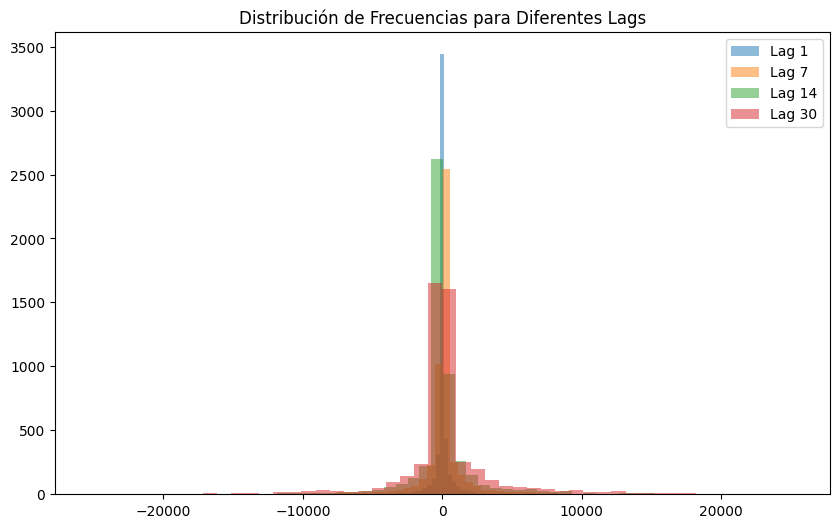

In [ ]:
# Distribución de frecuencias para diferentes lags
lags = [1, 7, 14, 30]
plt.figure(figsize=(10,6))
for lag in lags:
    plt.hist(df['Price'].diff(lag).dropna(), bins=50, alpha=0.5, label=f'Lag {lag}')
plt.legend()
plt.title("Distribución de Frecuencias para Diferentes Lags")
plt.show()

In [ ]:
# Medias móviles
df['SMA_7'] = df['Price'].rolling(window=7).mean()
df['SMA_14'] = df['Price'].rolling(window=14).mean()

In [ ]:
# Graficar medias móviles
fig_ma = px.line(df, x=df.index, y=['Price', 'SMA_7', 'SMA_14'], title='Medias Móviles del Precio de Bitcoin')
fig_ma.show()

## *1.5 Aplicación de medias móviles*

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# Calcular medias móviles
df['cM2_t'] = df['Price'].rolling(window=2).mean()
df['cM2_t_t1'] = df['Price'].rolling(window=2).mean().shift(-1)
df['cM3_t'] = df['Price'].rolling(window=3).mean()
df['cM3_t_t1'] = df['Price'].rolling(window=3).mean().shift(-1)
df['cM3_t_t-1'] = df['Price'].rolling(window=3, center=True).mean()
df['cM4_t'] = df['Price'].rolling(window=4).mean()
df['cM4_t_t1'] = df['Price'].rolling(window=4).mean().shift(-1)
 
# Lista de columnas de medias móviles
ma_columns = ['cM2_t', 'cM2_t_t1', 'cM3_t', 'cM3_t_t1', 'cM3_t_t-1', 'cM4_t', 'cM4_t_t1']
 
# Remover tendencia para cada media móvil
for col in ma_columns:
    df[f'detrended_{col}'] = df['Price'] - df[col]
 
# Prueba de Dickey-Fuller para verificar estacionariedad en cada detrended
print("Resultados de la Prueba de Dickey-Fuller:")
for col in ma_columns:
    detrended_col = f'detrended_{col}'
    adf_test = adfuller(df[detrended_col].dropna())
    print(f"\n{detrended_col}:")
    print(f"  Estadístico: {adf_test[0]}")
    print(f"  P-valor: {adf_test[1]}")
 
# Prueba de Ljung-Box para independencia de residuos en cada detrended
print("\nResultados de la Prueba de Ljung-Box:")
for col in ma_columns:
    detrended_col = f'detrended_{col}'
    ljung_box_test = acorr_ljungbox(df[detrended_col].dropna(), lags=[10], return_df=True)
    print(f"\n{detrended_col}:")
    print(ljung_box_test)

Resultados de la Prueba de Dickey-Fuller:

detrended_cM2_t:
  Estadístico: -9.886578088339864
  P-valor: 3.6505273415731896e-17

detrended_cM2_t_t1:
  Estadístico: -9.886578088339824
  P-valor: 3.6505273415740586e-17

detrended_cM3_t:
  Estadístico: -9.515926723298962
  P-valor: 3.157399273322918e-16

detrended_cM3_t_t1:
  Estadístico: -22.671517074530176
  P-valor: 0.0

detrended_cM3_t_t-1:
  Estadístico: -22.671517074530176
  P-valor: 0.0

detrended_cM4_t:
  Estadístico: -9.249080004579433
  P-valor: 1.509310071203713e-15

detrended_cM4_t_t1:
  Estadístico: -10.313327846709523
  P-valor: 3.1437135226531228e-18

Resultados de la Prueba de Ljung-Box:

detrended_cM2_t:
     lb_stat     lb_pvalue
10  72.61667  1.381782e-11

detrended_cM2_t_t1:
     lb_stat     lb_pvalue
10  72.61667  1.381782e-11

detrended_cM3_t:
      lb_stat      lb_pvalue
10  748.84869  2.029879e-154

detrended_cM3_t_t1:
        lb_stat  lb_pvalue
10  1483.553462        0.0

detrended_cM3_t_t-1:
        lb_stat  lb_p

## *1.6 Descomposición de la serie temporal*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# --- Paso 1: Preparar los datos ---
# Se asume que 'df' ya está cargado y contiene las columnas "Date" y "Price"
# Convertir 'Date' a datetime y 'Price' a numérico (quitando comas, si es necesario)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
if df['Price'].dtype == 'object':
    df['Price'] = pd.to_numeric(df['Price'].str.replace(',', ''), errors='coerce')
else:
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Establecer "Date" como índice y ordenar (para análisis de series de tiempo)
df_ts = df.set_index('Date').sort_index()

# --- Paso 2: Evaluar la estacionariedad de la serie original ---
serie_original = df_ts['Price'].dropna()
adf_result_orig = adfuller(serie_original)
print("Prueba ADF - Serie Original")
print(f"Estadístico de prueba: {adf_result_orig[0]:.4f}")
print(f"p-value: {adf_result_orig[1]:.4f}")
print("Valores críticos:")
for key, value in adf_result_orig[4].items():
    print(f"   {key}: {value:.4f}")
print("\n")

# En general, si p-value > 0.05, la serie no es estacionaria.

# --- Paso 3: Aplicar transformación logarítmica ---
# Nota: Solo se puede aplicar log si los valores son positivos.
df_ts['Price_log'] = np.log(serie_original)

adf_result_log = adfuller(df_ts['Price_log'].dropna())
print("Prueba ADF - Serie Log(Price)")
print(f"Estadístico de prueba: {adf_result_log[0]:.4f}")
print(f"p-value: {adf_result_log[1]:.4f}")
print("Valores críticos:")
for key, value in adf_result_log[4].items():
    print(f"   {key}: {value:.4f}")
print("\n")

# Si la serie logarítmica aún no es estacionaria, aplicamos la diferenciación.

# --- Paso 4: Diferenciar la serie logarítmica ---
df_ts['Price_log_diff'] = df_ts['Price_log'].diff()
serie_diff = df_ts['Price_log_diff'].dropna()

adf_result_diff = adfuller(serie_diff)
print("Prueba ADF - Serie Diferenciada (Log(Price))")
print(f"Estadístico de prueba: {adf_result_diff[0]:.4f}")
print(f"p-value: {adf_result_diff[1]:.4f}")
print("Valores críticos:")
for key, value in adf_result_diff[4].items():
    print(f"   {key}: {value:.4f}")
print("\n")

# --- Paso 5: Graficar las series para visualizar las transformaciones ---
plt.figure(figsize=(14,10))

plt.subplot(3,1,1)
plt.plot(serie_original, label='Precio Original')
plt.title('Serie Original')
plt.legend()

plt.subplot(3,1,2)
plt.plot(df_ts['Price_log'], label='Log(Precio)', color='orange')
plt.title('Serie Logarítmica')
plt.legend()

plt.subplot(3,1,3)
plt.plot(serie_diff, label='Diferencia de Log(Precio)', color='green')
plt.title('Serie Diferenciada (Log(Precio)) - Stationaria')
plt.legend()

plt.tight_layout()
plt.show()

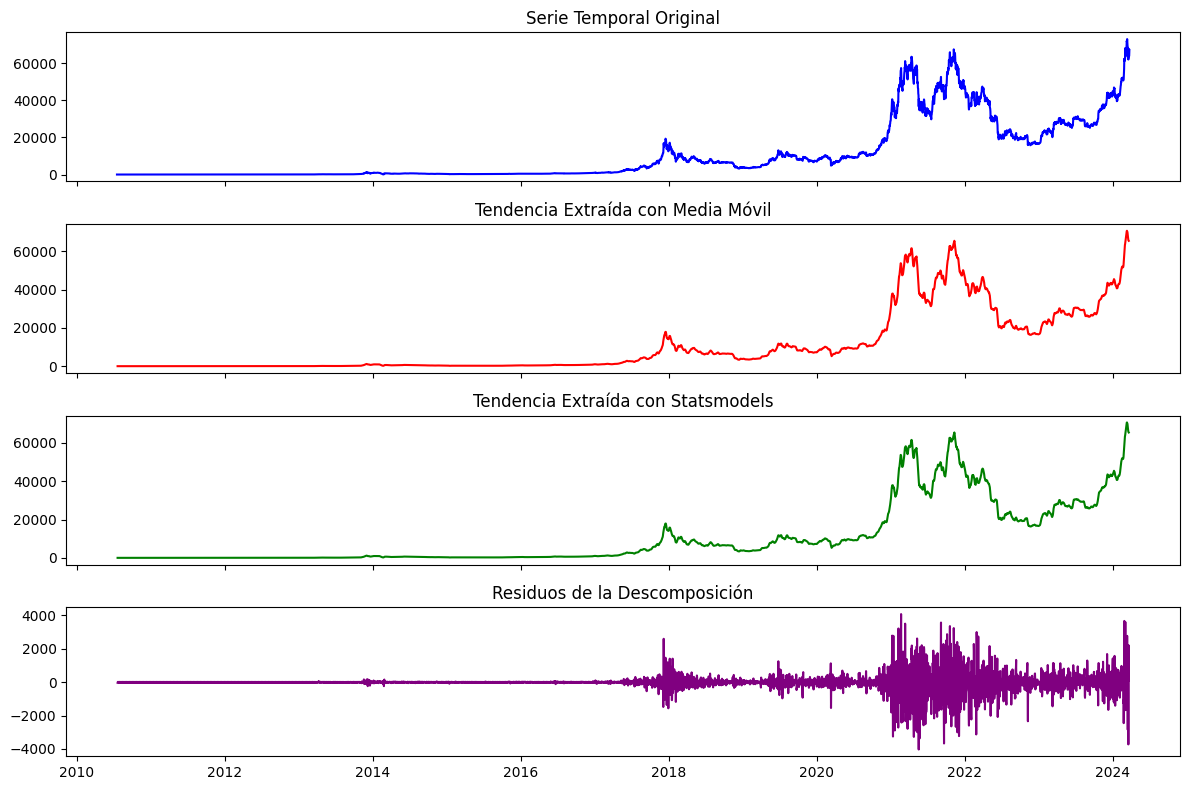


Prueba de Ljung-Box sobre los residuos:
        lb_stat      lb_pvalue
10  1026.374408  3.889671e-214


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox

# -------------------------------------------
# 1. DESCOMPOSICIÓN USANDO MEDIAS MÓVILES
# -------------------------------------------
df['Trend_MA'] = df['Price'].rolling(window=7, center=True).mean()  # Media móvil de 7 días
df['Detrended_MA'] = df['Price'] - df['Trend_MA']  # Eliminando la tendencia

# -------------------------------------------
# 2. DESCOMPOSICIÓN USANDO STATSMODELS
# -------------------------------------------
decomp = seasonal_decompose(df['Price'], model='additive', period=7)  # Periodo de 7 días

# Extraer componentes
df['Trend_SM'] = decomp.trend
df['Seasonal_SM'] = decomp.seasonal
df['Residual_SM'] = decomp.resid

# -------------------------------------------
# 3. VERIFICACIÓN DE INDEPENDENCIA CON LJUNG-BOX
# -------------------------------------------
ljung_box_test = acorr_ljungbox(df['Residual_SM'].dropna(), lags=[10], return_df=True)

# -------------------------------------------
# 4. VISUALIZACIÓN DE LOS RESULTADOS
# -------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df['Price'], label="Serie Original", color='skyblue')
axes[0].set_title("Serie Original")
axes[1].plot(df['Trend_MA'], label="Tendencia (Media Móvil)", color='red')
axes[1].set_title("Tendencia con Media Móvil")
axes[2].plot(df['Trend_SM'], label="Tendencia (Statsmodels)", color='yellow')
axes[2].set_title("Tendencia con Statsmodels")
axes[3].plot(df['Residual_SM'], label="Residuos", color='green')
axes[3].set_title("Residuos de la descomposición")
plt.tight_layout()
plt.show()

# -------------------------------------------
# 5. RESULTADOS DE LJUNG-BOX
# -------------------------------------------
print("\nPrueba de Ljung-Box sobre los residuos:")
print(ljung_box_test)


## *1.7 Repetición del análisis para retorno acumulado y volatilidad*

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
 
# =========================================
# 1. Lectura de datos y limpieza
# =========================================

# Cargar datos
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4999 entries, 2024-03-24 to 2010-07-18
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     4999 non-null   float64
 1   Open      4999 non-null   float64
 2   High      4999 non-null   float64
 3   Low       4999 non-null   float64
 4   Vol.      4993 non-null   float64
 5   Change %  4999 non-null   float64
dtypes: float64(6)
memory usage: 273.4 KB


In [ ]:
df["Return"] = df["Price"].pct_change()
df["Return"].iloc[0] = 0  # Reemplazar el primer NaN con 0
 
# Calcular el retorno acumulado diario
df["Cumulative Return"] = df["Return"].cumsum()
 
# Ventanas de tiempo para la volatilidad
windows = [7, 14, 21, 28]
 
# Calcular la volatilidad con ventanas móviles
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

In [ ]:
df

,Price,Open,High,Low,Vol.,Change %,Return,Cumulative Return,Volatility_7d,Volatility_14d,Volatility_21d,Volatility_28d
Date,,,,,,,,,,,,
2024-03-24,67211.9,64036.5,67587.8,63812.9,65590.0,4.96,0.000000,0.000000,NaN,NaN,NaN,NaN
2024-03-23,64037.8,63785.6,65972.4,63074.9,35110.0,0.40,-0.047225,-0.047225,0.033393,0.033393,0.033393,0.033393
2024-03-22,63785.5,65501.5,66633.3,62328.3,72430.0,-2.62,-0.003940,-0.051165,0.026202,0.026202,0.026202,0.026202
2024-03-21,65503.8,67860.0,68161.7,64616.1,75260.0,-3.46,0.026939,-0.024226,0.030685,0.030685,0.030685,0.030685
2024-03-20,67854.0,62046.8,68029.5,60850.9,133530.0,9.35,0.035879,0.011652,0.032525,0.032525,0.032525,0.032525
...,...,...,...,...,...,...,...,...,...,...,...,...
2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.00,0.000000,-4.322978,0.000000,0.000000,0.000000,0.000000
2010-07-21,0.1,0.1,0.1,0.1,580.0,0.00,0.000000,-4.322978,0.000000,0.000000,0.000000,0.000000
2010-07-20,0.1,0.1,0.1,0.1,260.0,0.00,0.000000,-4.322978,0.000000,0.000000,0.000000,0.000000


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')
 
# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

In [ ]:
cols = ["Volatility_7d", "Volatility_14d", "Volatility_21d", "Volatility_28d"]
df[cols] = df[cols].fillna(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4999 entries, 2010-07-18 to 2024-03-24
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              4999 non-null   float64
 1   Open               4999 non-null   float64
 2   High               4999 non-null   float64
 3   Low                4999 non-null   float64
 4   Vol.               4993 non-null   float64
 5   Change %           4999 non-null   float64
 6   Return             4999 non-null   float64
 7   Cumulative_Return  4999 non-null   float64
 8   Volatility_7d      4999 non-null   float64
 9   Volatility_14d     4999 non-null   float64
 10  Volatility_21d     4999 non-null   float64
 11  Volatility_28d     4999 non-null   float64
dtypes: float64(12)
memory usage: 507.7 KB


In [ ]:
df.isna().sum()

Price                0
Open                 0
High                 0
Low                  0
Vol.                 6
Change %             0
Return               0
Cumulative_Return    0
Volatility_7d        0
Volatility_14d       0
Volatility_21d       0
Volatility_28d       0
dtype: int64

In [ ]:
# Imputación combinada: Imputación por propagación hacia adelante y hacia atras (ffill + bfill).
df.fillna(method='bfill', inplace=True)  # Usa el siguiente valor disponible
df.fillna(method='ffill', inplace=True)  # Usa el valor anterior si sigue habiendo nulos

In [ ]:
df.isna().sum()

Price                0
Open                 0
High                 0
Low                  0
Vol.                 0
Change %             0
Return               0
Cumulative_Return    0
Volatility_7d        0
Volatility_14d       0
Volatility_21d       0
Volatility_28d       0
dtype: int64

In [ ]:
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

In [ ]:
df

,Price,Open,High,Low,Volume,Change,Return,Cumulative_Return,Volatility_7d,Volatility_14d,Volatility_21d,Volatility_28d
Date,,,,,,,,,,,,
2010-07-18,0.1,0.0,0.1,0.1,80.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-07-19,0.1,0.1,0.1,0.1,570.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-07-20,0.1,0.1,0.1,0.1,260.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-07-21,0.1,0.1,0.1,0.1,580.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-20,67854.0,62046.8,68029.5,60850.9,133530.0,9.35,0.093537,23.719802,0.060681,0.044544,0.044059,0.043374
2024-03-21,65503.8,67860.0,68161.7,64616.1,75260.0,-3.46,-0.034636,23.685166,0.061287,0.045543,0.044563,0.044045
2024-03-22,63785.5,65501.5,66633.3,62328.3,72430.0,-2.62,-0.026232,23.658934,0.061256,0.045630,0.044883,0.044397


# Ejercicio 2: Aplicación de Modelos Estadísticos

## *Simple Exponential Smoothing (Sin librería)*

Resultados para τ = 7
                 Métrica                   Valor
0                    MAE             1667.915794
1                    MSE          4003802.195792
2                   RMSE             2000.950323
3                   MAPE                3.563091
4                     R2                0.081828
5    Ljung-Box (p-value)                0.009285
6          BDS (p-value)  1.2274647250301175e-15
7  Jarque-Bera (p-value)                 0.68794


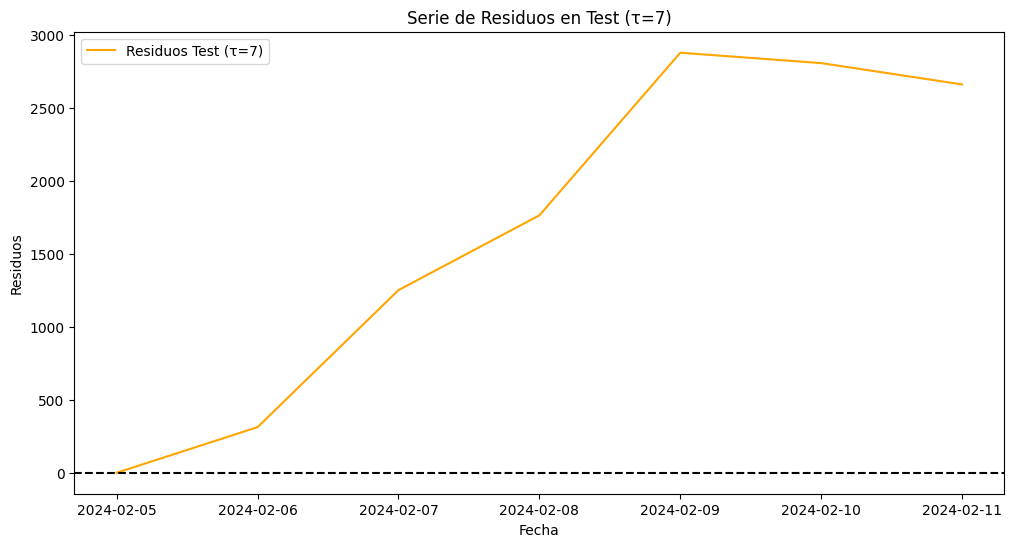

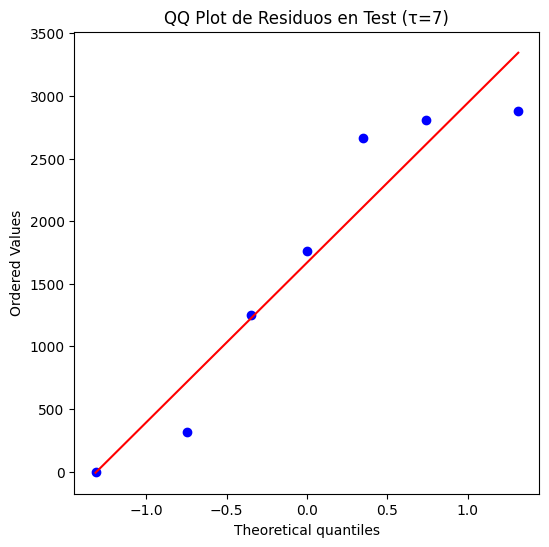

<Figure size 1000x500 with 0 Axes>

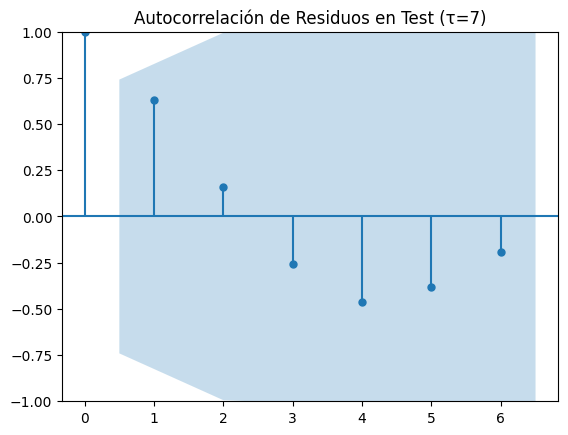

Resultados para τ = 14
                 Métrica                  Valor
0                    MAE              592.99957
1                    MSE          563144.080626
2                   RMSE             750.429264
3                   MAPE               1.145405
4                     R2               0.026111
5    Ljung-Box (p-value)               0.046531
6          BDS (p-value)  6.859181491635466e-17
7  Jarque-Bera (p-value)               0.789756


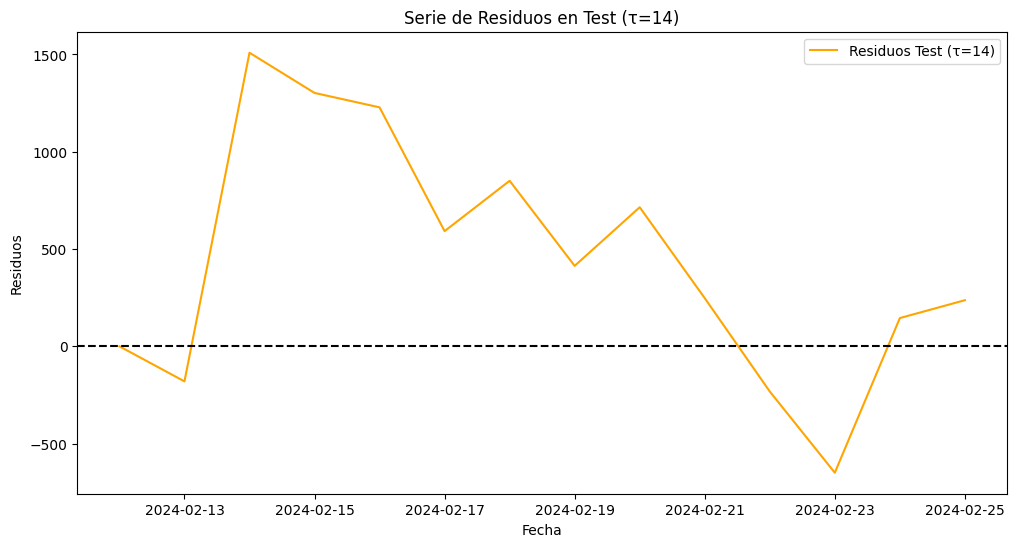

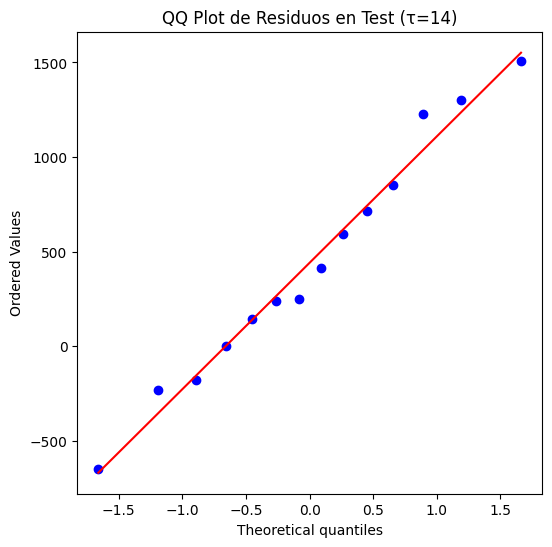

<Figure size 1000x500 with 0 Axes>

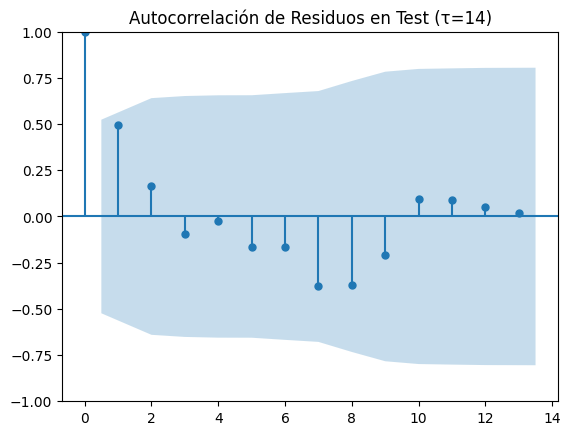

Resultados para τ = 21
                 Métrica                  Valor
0                    MAE            2814.462051
1                    MSE        12741228.084718
2                   RMSE            3569.485689
3                   MAPE               4.447895
4                     R2               0.716172
5    Ljung-Box (p-value)               0.000088
6          BDS (p-value)  2.579386964705035e-09
7  Jarque-Bera (p-value)               0.724956


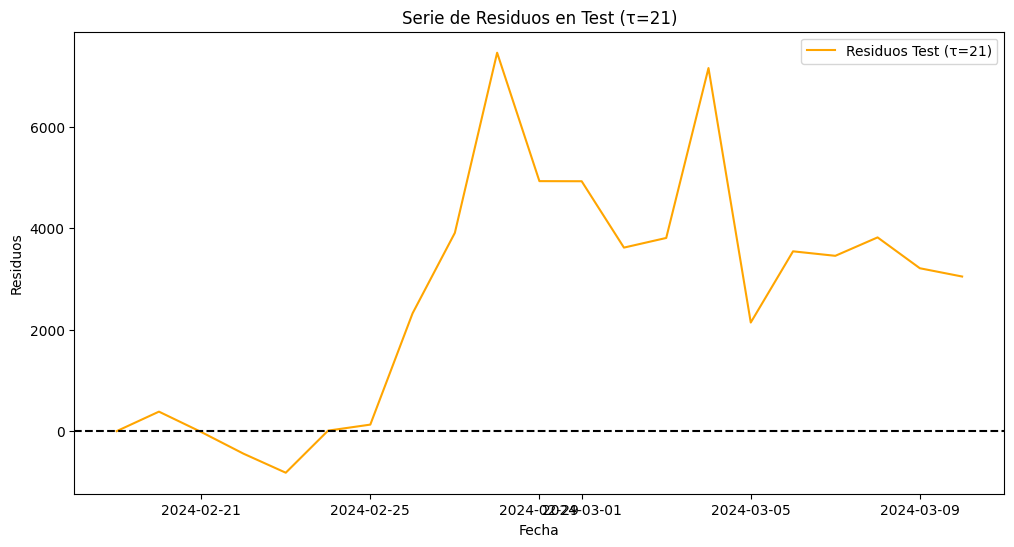

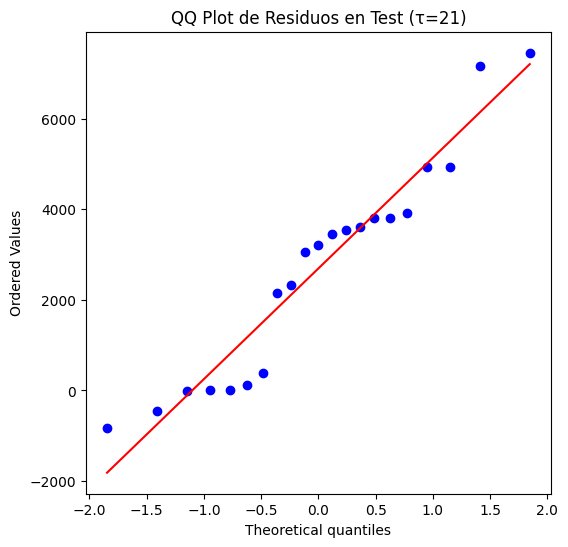

<Figure size 1000x500 with 0 Axes>

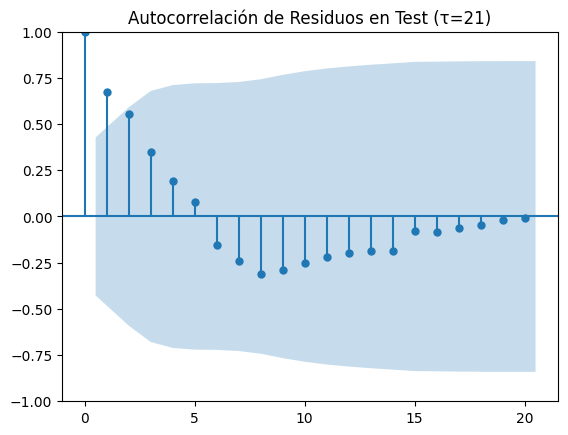

Resultados para τ = 28
                 Métrica                  Valor
0                    MAE            2759.089026
1                    MSE         10437558.14384
2                   RMSE            3230.720994
3                   MAPE               4.192194
4                     R2               0.427494
5    Ljung-Box (p-value)               0.000029
6          BDS (p-value)  1.865654328691599e-05
7  Jarque-Bera (p-value)               0.505192


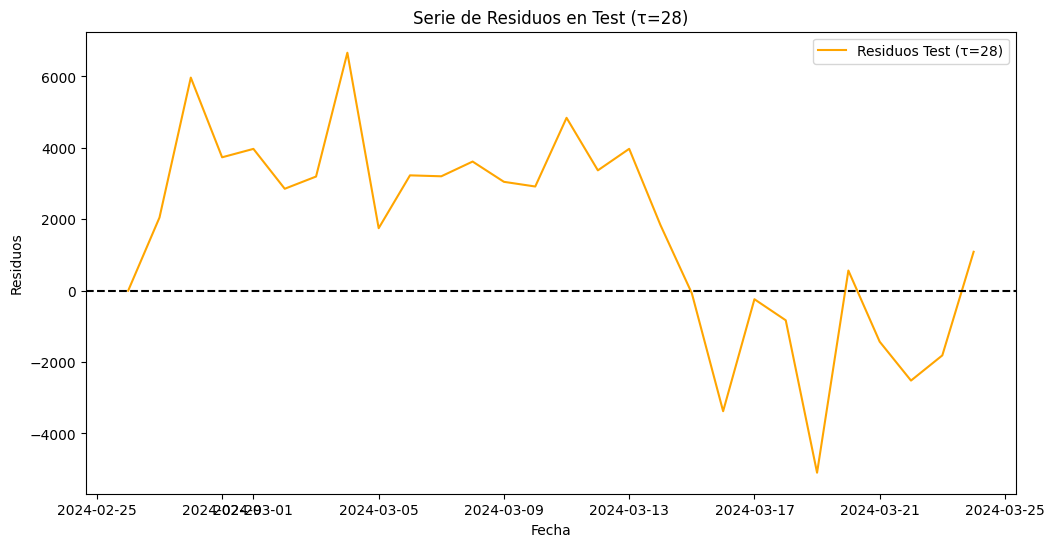

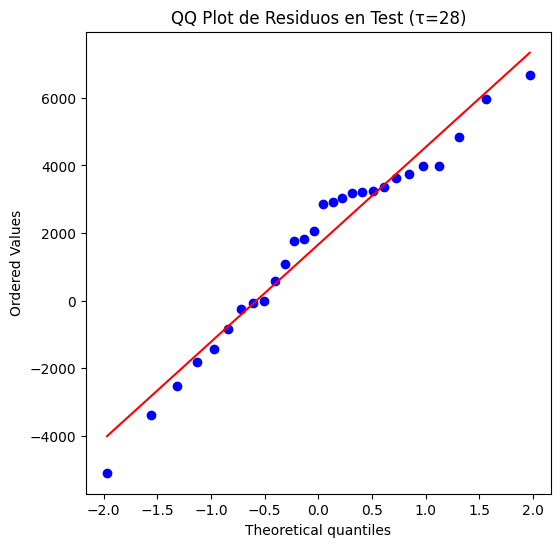

<Figure size 1000x500 with 0 Axes>

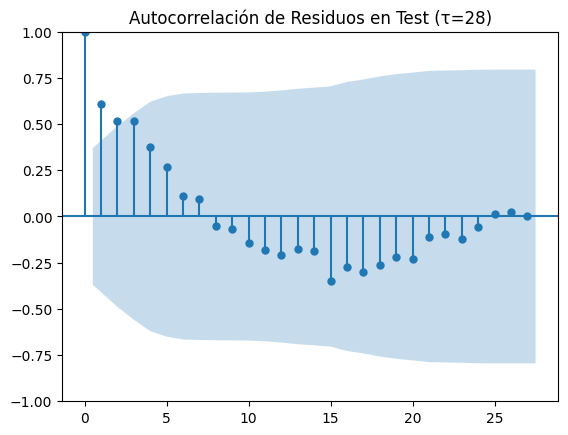

In [ ]:
# Simple Exponential Smoothing (Sin Librería) para la columna "Precio"

import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# Función para Suavizamiento Exponencial Simple (SES)
def simple_exponential_smoothing(series, alpha):
    """
    Aplica el Suavizamiento Exponencial Simple (SES) a una serie temporal.
    Parámetros:
        series (array-like): Serie de tiempo original.
        alpha (float): Factor de suavizado (0 < alpha ≤ 1).
    Retorna:
        np.array: Serie suavizada.
    """
    smoothed_values = np.zeros(len(series))
    smoothed_values[0] = series[0]  # Inicializar con el primer valor
    for t in range(1, len(series)):
        smoothed_values[t] = alpha * series[t] + (1 - alpha) * smoothed_values[t-1]
    return smoothed_values

# Definir los tamaños de validación y test
tau_values = [7, 14, 21, 28]
for tau in tau_values:
    val_size = tau
    test_size = tau
    train_size = len(df) - (28 + 28)
    
    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:train_size + val_size + test_size]
    
    # Extraer la columna de precios
    train_series = train_data['Price'].values
    val_series = val_data['Price'].values
    test_series = test_data['Price'].values
    
    # Aplicar SES con un alpha de 0.2
    alpha = 0.2
    smoothed_train = simple_exponential_smoothing(train_series, alpha)
    smoothed_val = simple_exponential_smoothing(val_series, alpha)
    smoothed_test = simple_exponential_smoothing(test_series, alpha)
    
    # Calcular residuos
    test_residuals = test_series - smoothed_test

    # Evaluar en test
    test_mae, test_mse, test_rmse, test_mape, test_r2 = mean_absolute_error(test_series, smoothed_test), \
                                                         mean_squared_error(test_series, smoothed_test), \
                                                         np.sqrt(mean_squared_error(test_series, smoothed_test)), \
                                                         np.mean(np.abs((test_series - smoothed_test) / test_series)) * 100, \
                                                         r2_score(test_series, smoothed_test)
    
    # Ajustar número de lags para Ljung-Box
    max_lags = min(10, len(test_residuals) - 1)
    test_ljung_box_pvalue = acorr_ljungbox(test_residuals, lags=[max_lags], return_df=True)['lb_pvalue'].values[0] if max_lags > 0 else np.nan
    
    test_bds_stat, test_bds_pvalue = bds(test_residuals)
    test_jarque_bera_pvalue = jarque_bera(test_residuals)[1]
    
    # Crear DataFrame de resultados en test
    test_results = pd.DataFrame({
        'Métrica': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Ljung-Box (p-value)', 'BDS (p-value)', 'Jarque-Bera (p-value)'],
        'Valor': [test_mae, test_mse, test_rmse, test_mape, test_r2, test_ljung_box_pvalue, test_bds_pvalue, test_jarque_bera_pvalue]
    })
    print(f"Resultados para τ = {tau}")
    print(test_results)
    
    # Graficar residuos en test
    plt.figure(figsize=(12,6))
    plt.plot(test_data.index, test_residuals, label=f'Residuos Test (τ={tau})', color='orange')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Fecha')
    plt.ylabel('Residuos')
    plt.title(f'Serie de Residuos en Test (τ={tau})')
    plt.legend()
    plt.show()
    
    # QQPlot en test
    plt.figure(figsize=(6,6))
    probplot(test_residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot de Residuos en Test (τ={tau})")
    plt.show()
    
    # ACF de Residuos en test
    max_lags_acf = min(30, len(test_residuals) - 1)  # Ajustar lags para evitar errores
    if max_lags_acf > 0:
        plt.figure(figsize=(10,5))
        plot_acf(test_residuals, lags=max_lags_acf)
        plt.title(f"Autocorrelación de Residuos en Test (τ={tau})")
        plt.show()


Resultados para τ = 7
                 Métrica                  Valor
0                    MAE               0.037563
1                    MSE               0.002014
2                   RMSE               0.044873
3                   MAPE               0.161077
4                     R2               0.073466
5    Ljung-Box (p-value)               0.010624
6          BDS (p-value)  7.993565503834804e-25
7  Jarque-Bera (p-value)               0.689301


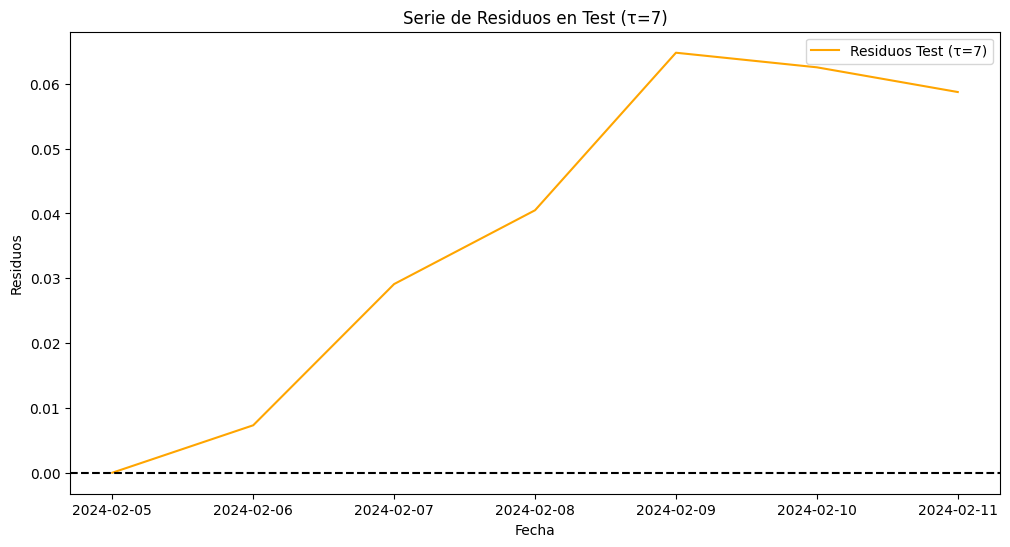

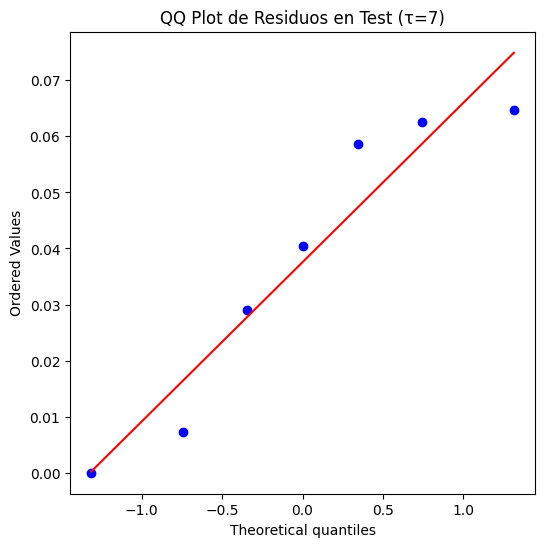

<Figure size 1000x500 with 0 Axes>

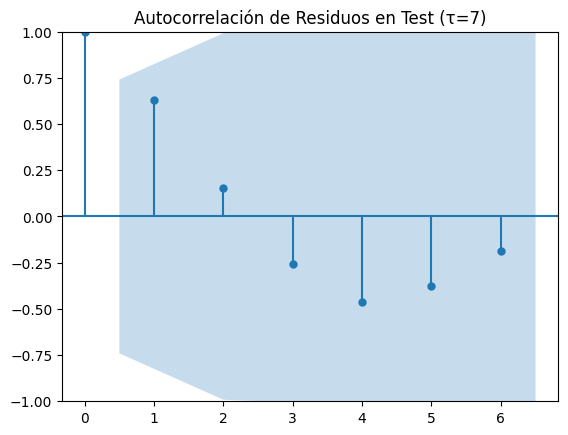

Resultados para τ = 14
                 Métrica                  Valor
0                    MAE               0.011867
1                    MSE               0.000225
2                   RMSE               0.015016
3                   MAPE               0.050663
4                     R2                0.02469
5    Ljung-Box (p-value)                0.05065
6          BDS (p-value)  7.586718562477651e-16
7  Jarque-Bera (p-value)                0.78198


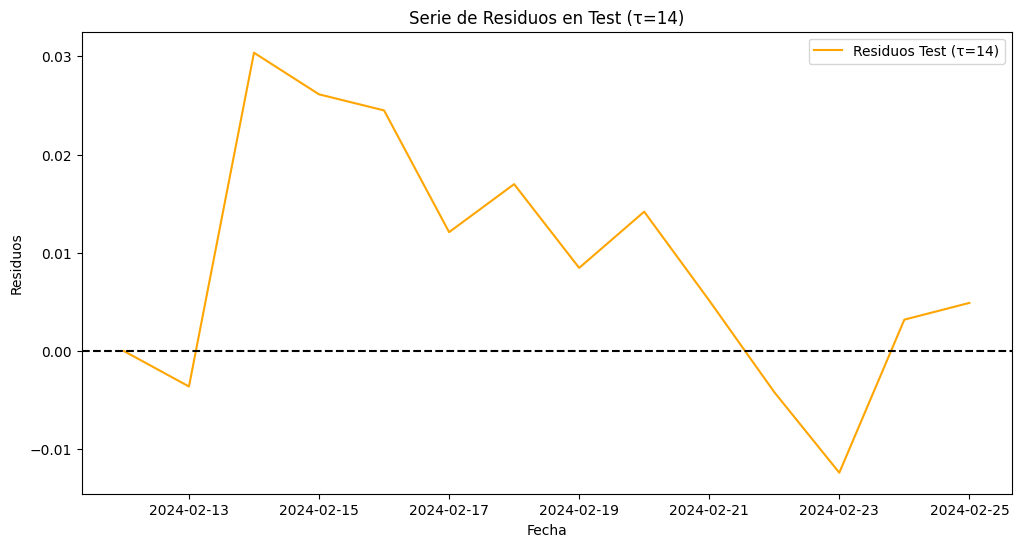

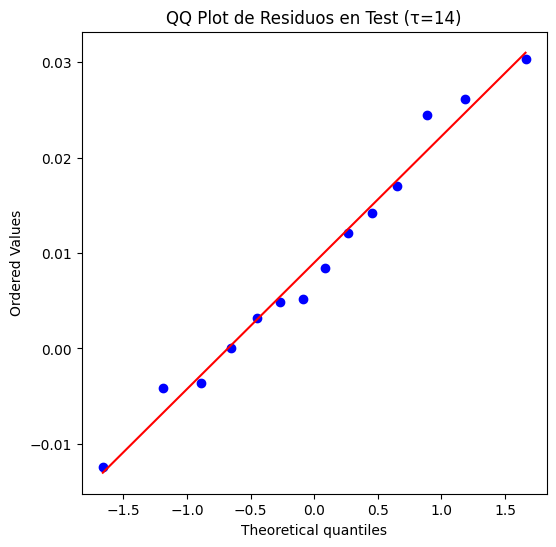

<Figure size 1000x500 with 0 Axes>

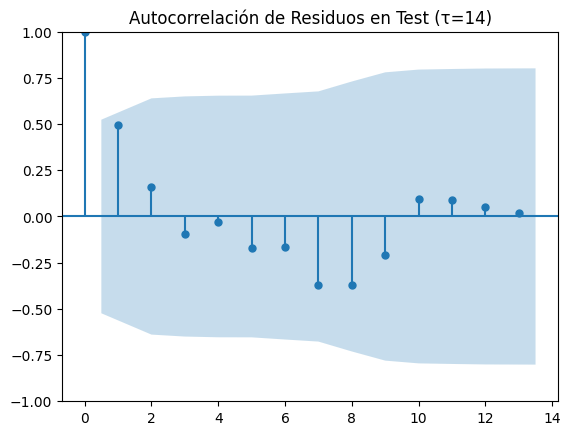

Resultados para τ = 21
                 Métrica                 Valor
0                    MAE               0.05015
1                    MSE              0.004001
2                   RMSE              0.063254
3                   MAPE              0.212219
4                     R2              0.716682
5    Ljung-Box (p-value)              0.000018
6          BDS (p-value)  9.23583906434974e-13
7  Jarque-Bera (p-value)               0.73229


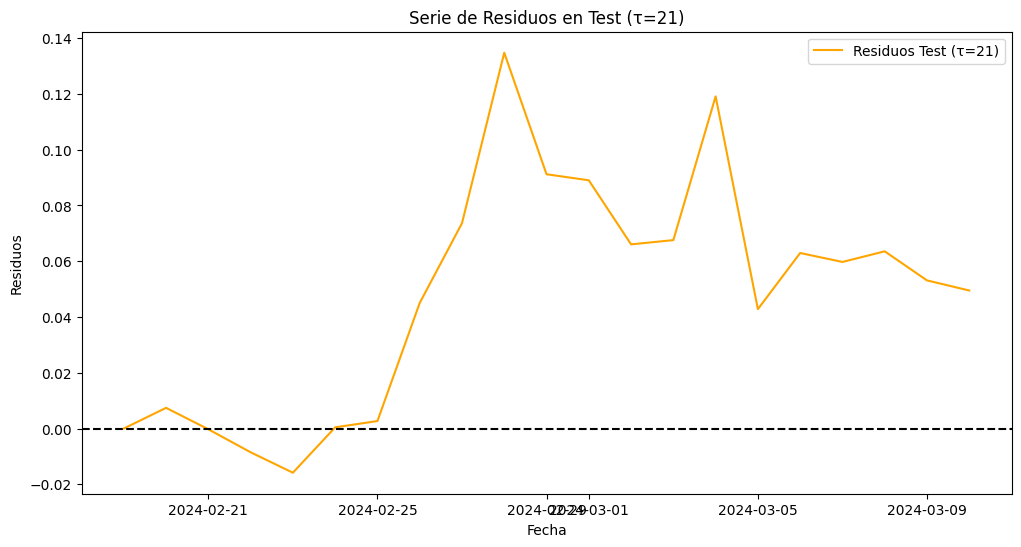

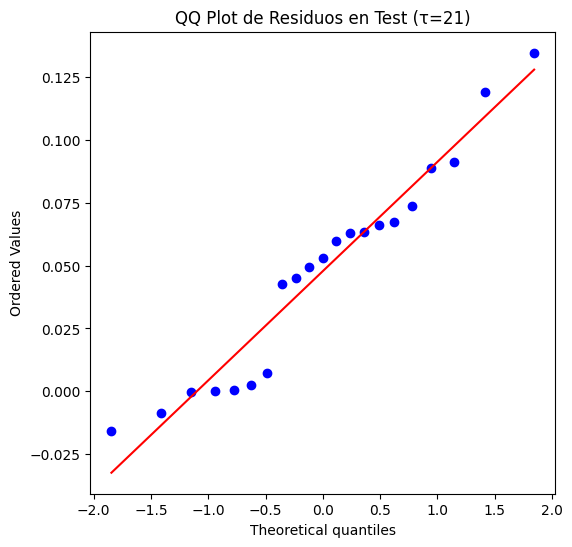

<Figure size 1000x500 with 0 Axes>

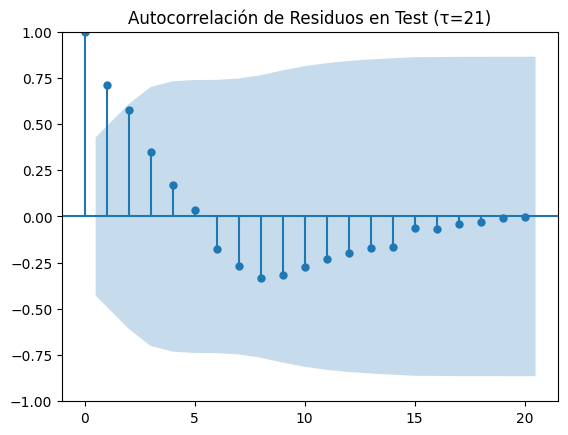

Resultados para τ = 28
                 Métrica                   Valor
0                    MAE                0.044853
1                    MSE                0.002801
2                   RMSE                0.052924
3                   MAPE                0.189446
4                     R2                0.428621
5    Ljung-Box (p-value)                0.000026
6          BDS (p-value)  3.0056614975136057e-05
7  Jarque-Bera (p-value)                0.622324


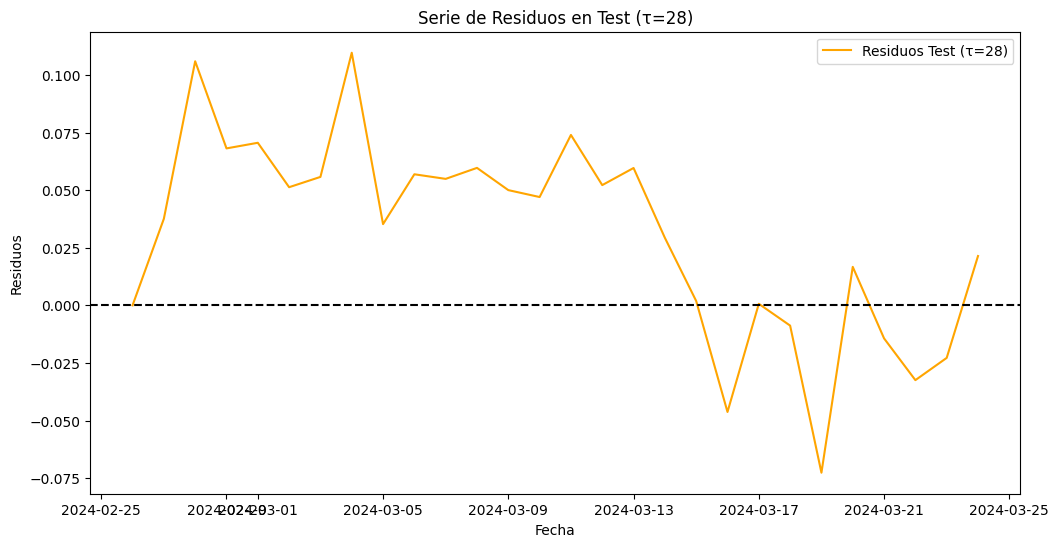

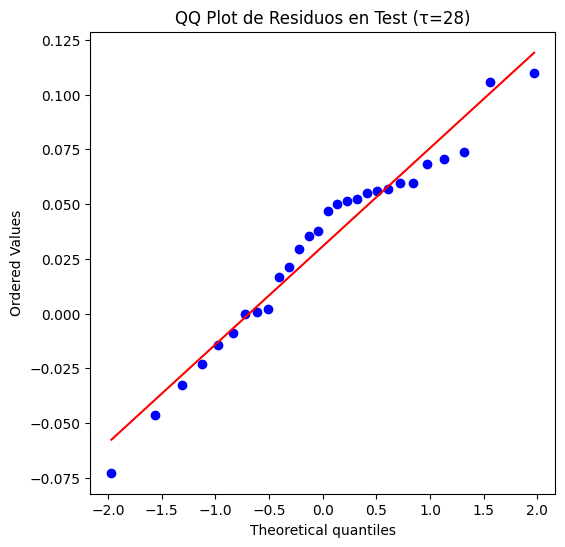

<Figure size 1000x500 with 0 Axes>

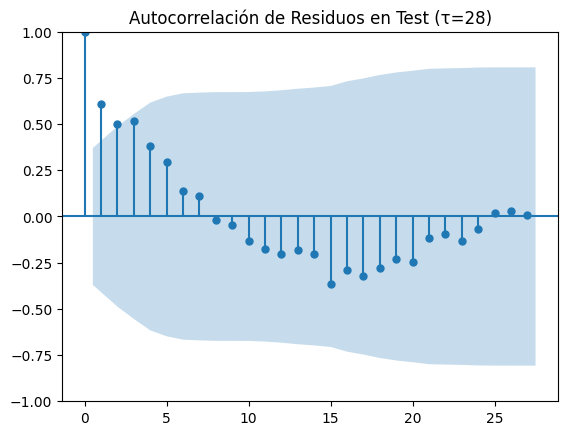

In [ ]:
# Simple Exponential Smoothing (Sin Librería) para la columna "Cumulative_Return"

import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Función para Suavizamiento Exponencial Simple (SES)
def simple_exponential_smoothing(series, alpha):
    """
    Aplica el Suavizamiento Exponencial Simple (SES) a una serie temporal.
    Parámetros:
        series (array-like): Serie de tiempo original.
        alpha (float): Factor de suavizado (0 < alpha ≤ 1).
    Retorna:
        np.array: Serie suavizada.
    """
    smoothed_values = np.zeros(len(series))
    smoothed_values[0] = series[0]  # Inicializar con el primer valor
    for t in range(1, len(series)):
        smoothed_values[t] = alpha * series[t] + (1 - alpha) * smoothed_values[t-1]
    return smoothed_values

# Definir los tamaños de validación y test
tau_values = [7, 14, 21, 28]
for tau in tau_values:
    val_size = tau
    test_size = tau
    train_size = len(df) - (28 + 28)
    
    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:train_size + val_size + test_size]
    
    # Extraer la columna del Retorno Acumulado
    train_series = train_data['Cumulative_Return'].values
    val_series = val_data['Cumulative_Return'].values
    test_series = test_data['Cumulative_Return'].values
    
    # Aplicar SES con un alpha de 0.2
    alpha = 0.2
    smoothed_train = simple_exponential_smoothing(train_series, alpha)
    smoothed_val = simple_exponential_smoothing(val_series, alpha)
    smoothed_test = simple_exponential_smoothing(test_series, alpha)
    
    # Calcular residuos
    test_residuals = test_series - smoothed_test

    # Evaluar en test
    test_mae, test_mse, test_rmse, test_mape, test_r2 = mean_absolute_error(test_series, smoothed_test), \
                                                         mean_squared_error(test_series, smoothed_test), \
                                                         np.sqrt(mean_squared_error(test_series, smoothed_test)), \
                                                         np.mean(np.abs((test_series - smoothed_test) / test_series)) * 100, \
                                                         r2_score(test_series, smoothed_test)
    
    # Ajustar número de lags para Ljung-Box
    max_lags = min(10, len(test_residuals) - 1)
    test_ljung_box_pvalue = acorr_ljungbox(test_residuals, lags=[max_lags], return_df=True)['lb_pvalue'].values[0] if max_lags > 0 else np.nan
    
    test_bds_stat, test_bds_pvalue = bds(test_residuals)
    test_jarque_bera_pvalue = jarque_bera(test_residuals)[1]
    
    # Crear DataFrame de resultados en test
    test_results = pd.DataFrame({
        'Métrica': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Ljung-Box (p-value)', 'BDS (p-value)', 'Jarque-Bera (p-value)'],
        'Valor': [test_mae, test_mse, test_rmse, test_mape, test_r2, test_ljung_box_pvalue, test_bds_pvalue, test_jarque_bera_pvalue]
    })
    print(f"Resultados para τ = {tau}")
    print(test_results)
    
    # Graficar residuos en test
    plt.figure(figsize=(12,6))
    plt.plot(test_data.index, test_residuals, label=f'Residuos Test (τ={tau})', color='orange')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Fecha')
    plt.ylabel('Residuos')
    plt.title(f'Serie de Residuos en Test (τ={tau})')
    plt.legend()
    plt.show()
    
    # QQPlot en test
    plt.figure(figsize=(6,6))
    probplot(test_residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot de Residuos en Test (τ={tau})")
    plt.show()
    
    # ACF de Residuos en test
    max_lags_acf = min(30, len(test_residuals) - 1)  # Ajustar lags para evitar errores
    if max_lags_acf > 0:
        plt.figure(figsize=(10,5))
        plot_acf(test_residuals, lags=max_lags_acf)
        plt.title(f"Autocorrelación de Residuos en Test (τ={tau})")
        plt.show()


Resultados para τ = 7
                 Métrica      Valor
0                    MAE   0.002732
1                    MSE   0.000013
2                   RMSE   0.003619
3                   MAPE  17.865763
4                     R2  -0.007839
5    Ljung-Box (p-value)   0.149633
6          BDS (p-value)        0.0
7  Jarque-Bera (p-value)   0.773878


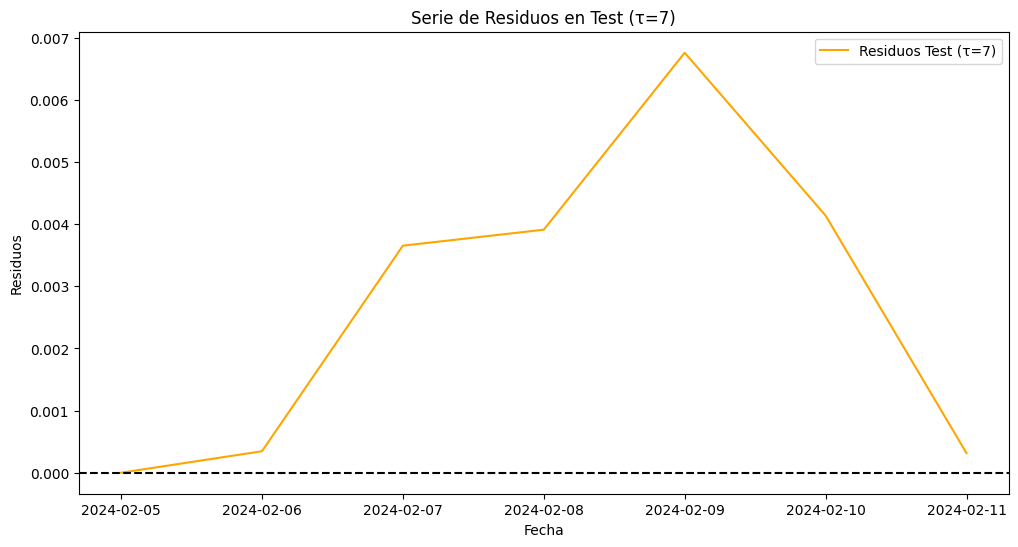

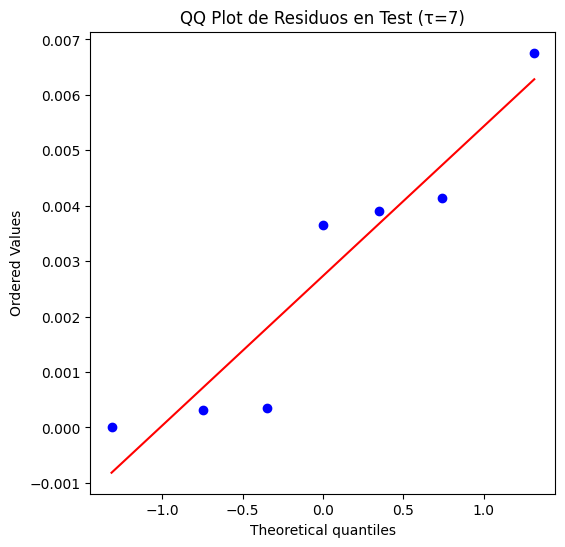

<Figure size 1000x500 with 0 Axes>

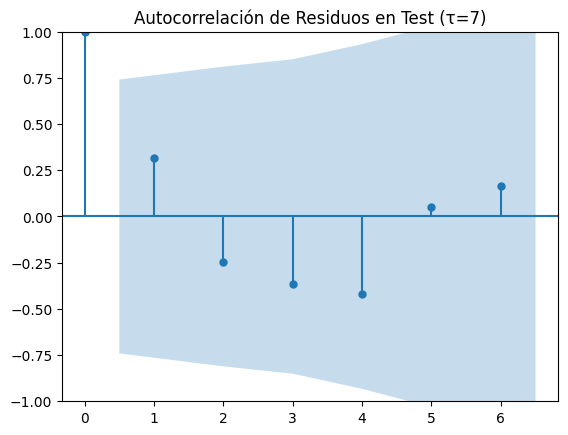

Resultados para τ = 14
                 Métrica                  Valor
0                    MAE               0.002634
1                    MSE               0.000011
2                   RMSE               0.003266
3                   MAPE              22.404583
4                     R2               0.345103
5    Ljung-Box (p-value)               0.000327
6          BDS (p-value)  4.168743262433421e-07
7  Jarque-Bera (p-value)               0.521452


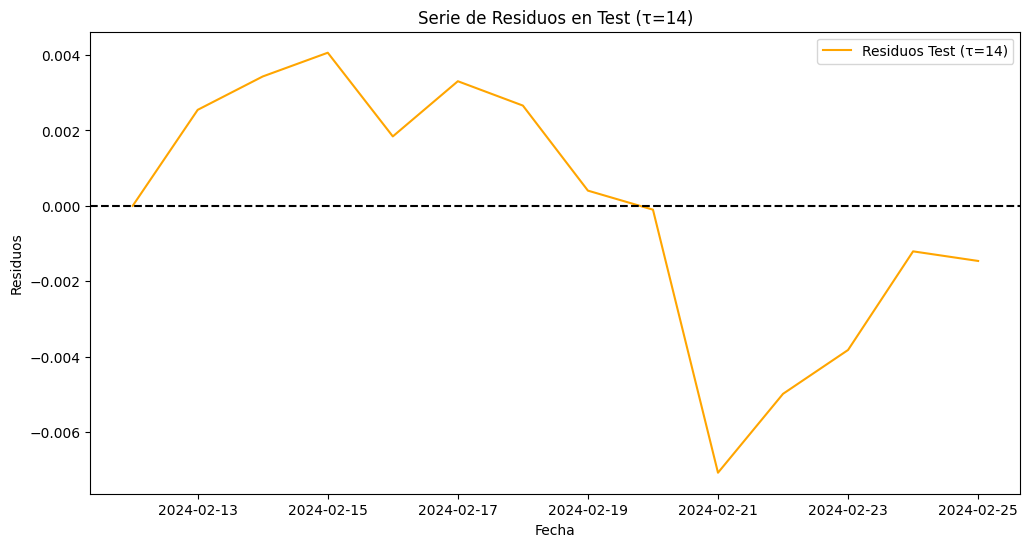

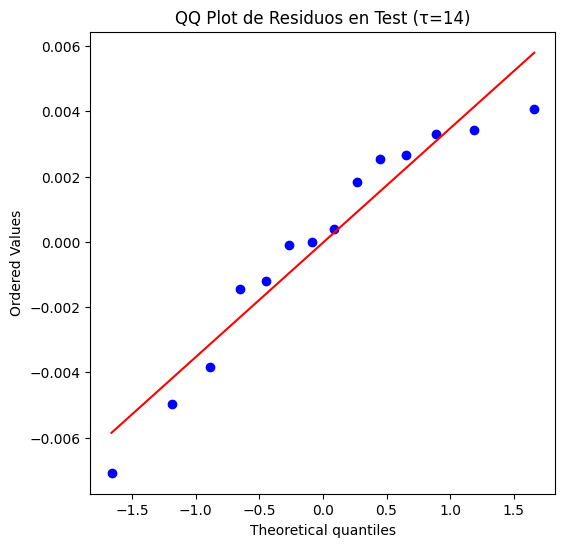

<Figure size 1000x500 with 0 Axes>

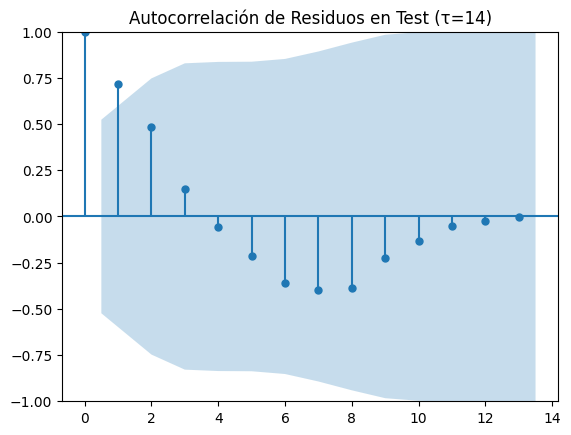

Resultados para τ = 21
                 Métrica                  Valor
0                    MAE               0.006694
1                    MSE               0.000073
2                   RMSE               0.008559
3                   MAPE              25.518433
4                     R2               0.682919
5    Ljung-Box (p-value)               0.000001
6          BDS (p-value)  1.101019285304143e-31
7  Jarque-Bera (p-value)               0.662067


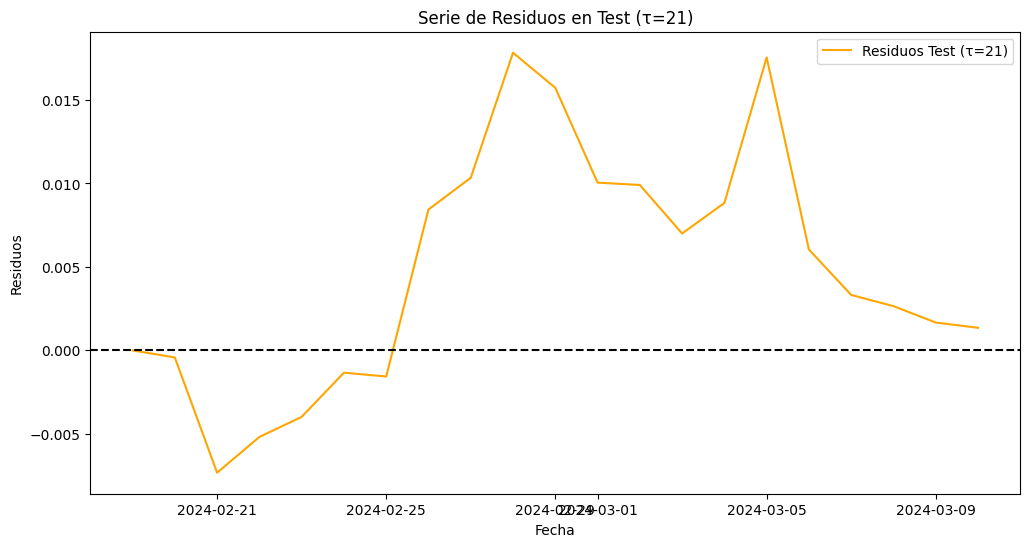

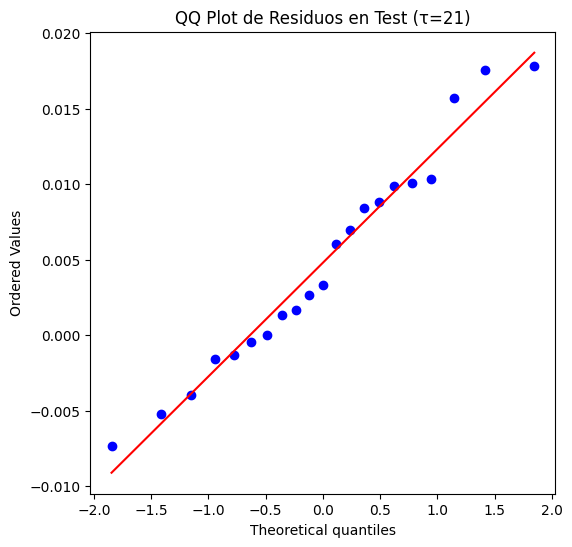

<Figure size 1000x500 with 0 Axes>

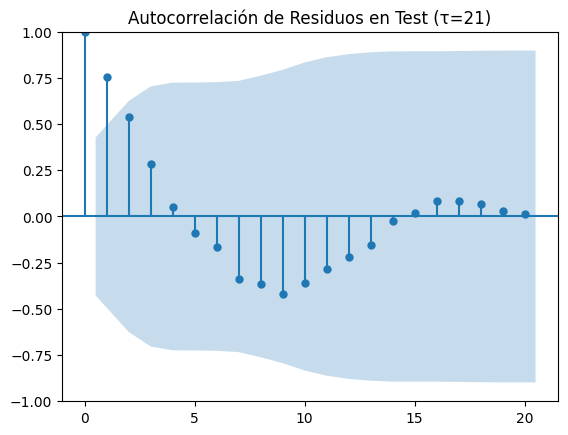

Resultados para τ = 28
                 Métrica                  Valor
0                    MAE               0.007826
1                    MSE               0.000092
2                   RMSE                0.00961
3                   MAPE              21.829471
4                     R2               0.405954
5    Ljung-Box (p-value)                    0.0
6          BDS (p-value)  5.805413304284706e-08
7  Jarque-Bera (p-value)               0.276391


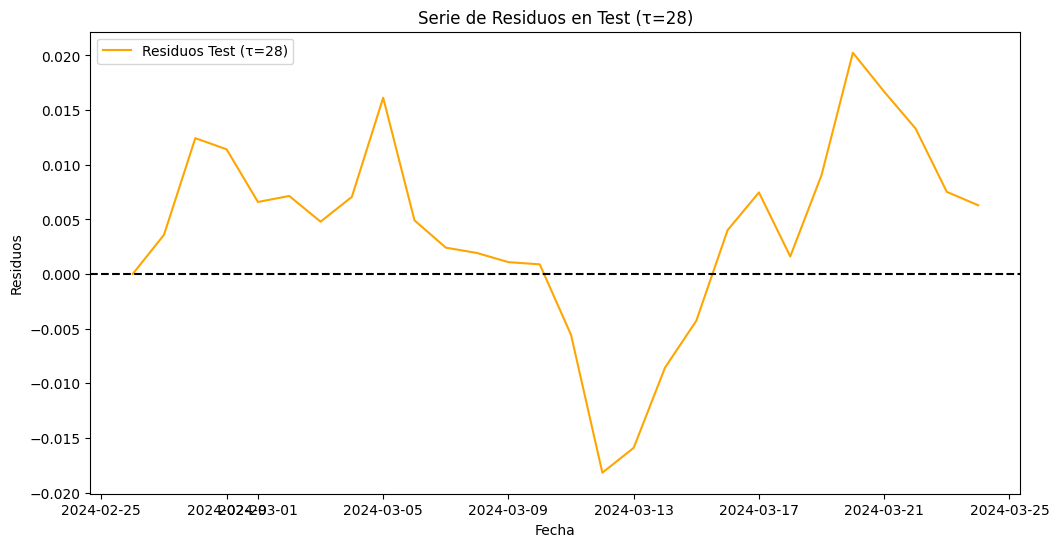

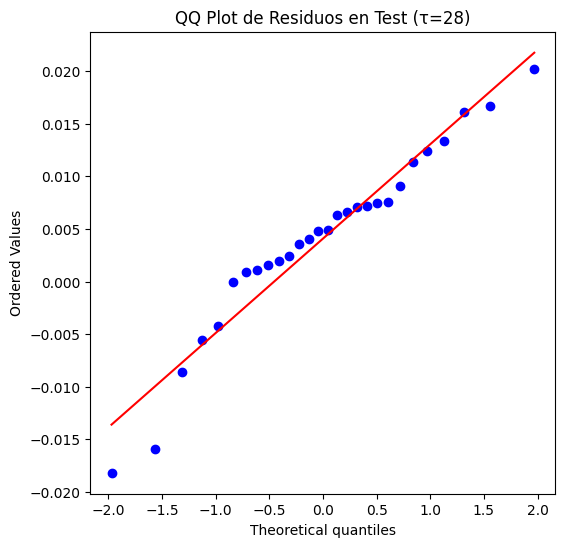

<Figure size 1000x500 with 0 Axes>

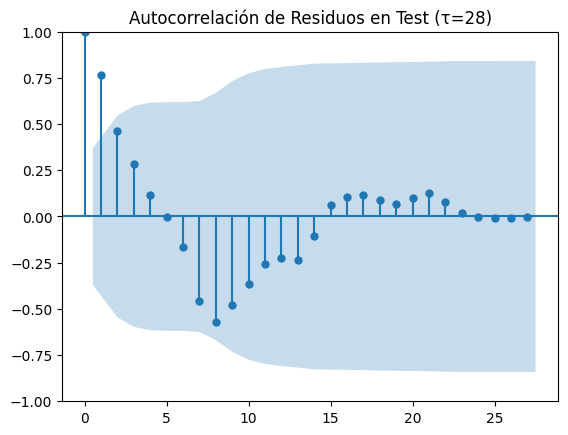

In [ ]:
# Simple Exponential Smoothing (Sin Librería) para la columna "Volatility_7d"

import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_7d"]]

# Función para Suavizamiento Exponencial Simple (SES)
def simple_exponential_smoothing(series, alpha):
    """
    Aplica el Suavizamiento Exponencial Simple (SES) a una serie temporal.
    Parámetros:
        series (array-like): Serie de tiempo original.
        alpha (float): Factor de suavizado (0 < alpha ≤ 1).
    Retorna:
        np.array: Serie suavizada.
    """
    smoothed_values = np.zeros(len(series))
    smoothed_values[0] = series[0]  # Inicializar con el primer valor
    for t in range(1, len(series)):
        smoothed_values[t] = alpha * series[t] + (1 - alpha) * smoothed_values[t-1]
    return smoothed_values

# Definir los tamaños de validación y test
tau_values = [7, 14, 21, 28]
for tau in tau_values:
    val_size = tau
    test_size = tau
    train_size = len(df) - (28 + 28)
    
    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:train_size + val_size + test_size]
    
    # Extraer la columna de la Volatilidad para 07 dias
    train_series = train_data['Volatility_7d'].values
    val_series = val_data['Volatility_7d'].values
    test_series = test_data['Volatility_7d'].values
    
    # Aplicar SES con un alpha de 0.2
    alpha = 0.2
    smoothed_train = simple_exponential_smoothing(train_series, alpha)
    smoothed_val = simple_exponential_smoothing(val_series, alpha)
    smoothed_test = simple_exponential_smoothing(test_series, alpha)
    
    # Calcular residuos
    test_residuals = test_series - smoothed_test

    # Evaluar en test
    test_mae, test_mse, test_rmse, test_mape, test_r2 = mean_absolute_error(test_series, smoothed_test), \
                                                         mean_squared_error(test_series, smoothed_test), \
                                                         np.sqrt(mean_squared_error(test_series, smoothed_test)), \
                                                         np.mean(np.abs((test_series - smoothed_test) / test_series)) * 100, \
                                                         r2_score(test_series, smoothed_test)
    
    # Ajustar número de lags para Ljung-Box
    max_lags = min(10, len(test_residuals) - 1)
    test_ljung_box_pvalue = acorr_ljungbox(test_residuals, lags=[max_lags], return_df=True)['lb_pvalue'].values[0] if max_lags > 0 else np.nan
    
    test_bds_stat, test_bds_pvalue = bds(test_residuals)
    test_jarque_bera_pvalue = jarque_bera(test_residuals)[1]
    
    # Crear DataFrame de resultados en test
    test_results = pd.DataFrame({
        'Métrica': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Ljung-Box (p-value)', 'BDS (p-value)', 'Jarque-Bera (p-value)'],
        'Valor': [test_mae, test_mse, test_rmse, test_mape, test_r2, test_ljung_box_pvalue, test_bds_pvalue, test_jarque_bera_pvalue]
    })
    print(f"Resultados para τ = {tau}")
    print(test_results)
    
    # Graficar residuos en test
    plt.figure(figsize=(12,6))
    plt.plot(test_data.index, test_residuals, label=f'Residuos Test (τ={tau})', color='orange')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Fecha')
    plt.ylabel('Residuos')
    plt.title(f'Serie de Residuos en Test (τ={tau})')
    plt.legend()
    plt.show()
    
    # QQPlot en test
    plt.figure(figsize=(6,6))
    probplot(test_residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot de Residuos en Test (τ={tau})")
    plt.show()
    
    # ACF de Residuos en test
    max_lags_acf = min(30, len(test_residuals) - 1)  # Ajustar lags para evitar errores
    if max_lags_acf > 0:
        plt.figure(figsize=(10,5))
        plot_acf(test_residuals, lags=max_lags_acf)
        plt.title(f"Autocorrelación de Residuos en Test (τ={tau})")
        plt.show()


Resultados para τ = 7
                 Métrica                 Valor
0                    MAE              0.000346
1                    MSE                   0.0
2                   RMSE              0.000501
3                   MAPE              2.070731
4                     R2              0.106068
5    Ljung-Box (p-value)              0.458791
6          BDS (p-value)  0.054807398814541865
7  Jarque-Bera (p-value)              0.592149


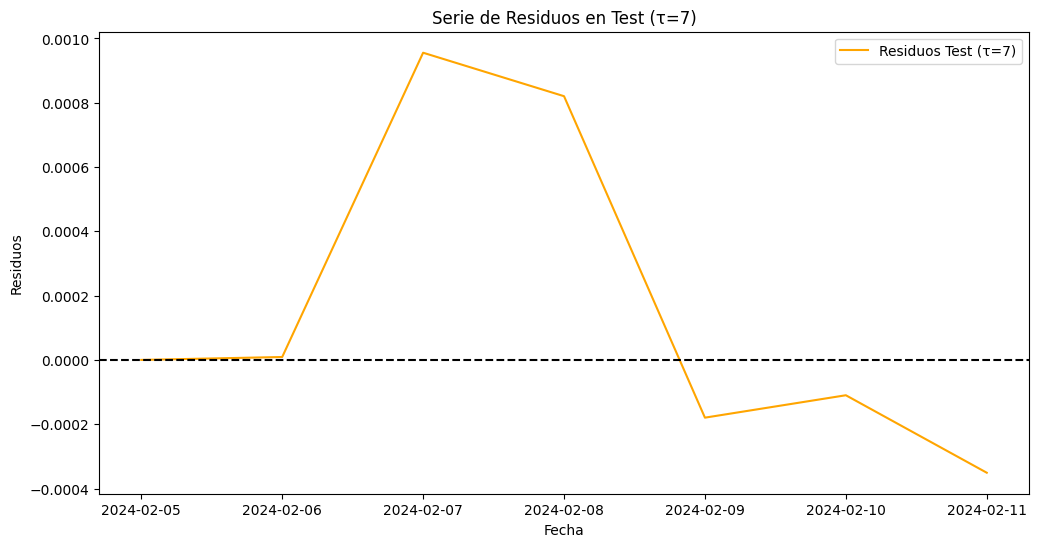

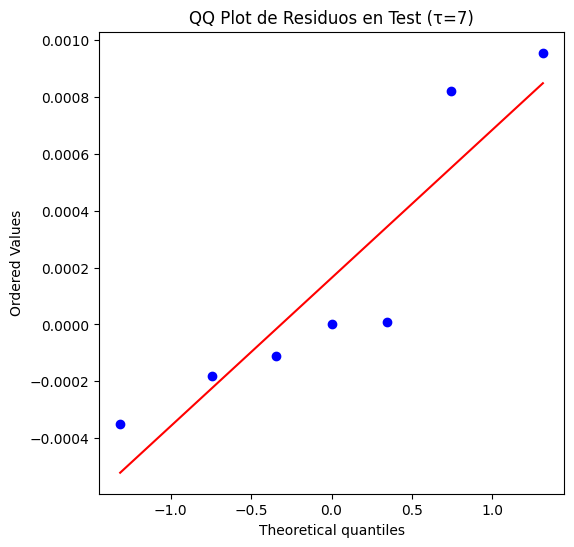

<Figure size 1000x500 with 0 Axes>

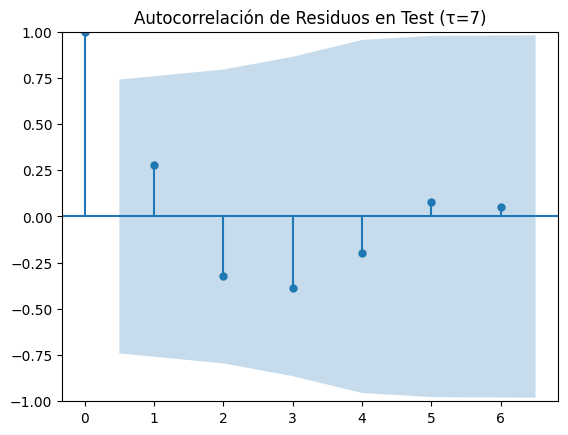

Resultados para τ = 14
                 Métrica                  Valor
0                    MAE               0.000455
1                    MSE                    0.0
2                   RMSE               0.000512
3                   MAPE               2.681394
4                     R2               0.190148
5    Ljung-Box (p-value)               0.150867
6          BDS (p-value)  5.797264284597484e-50
7  Jarque-Bera (p-value)                0.56783


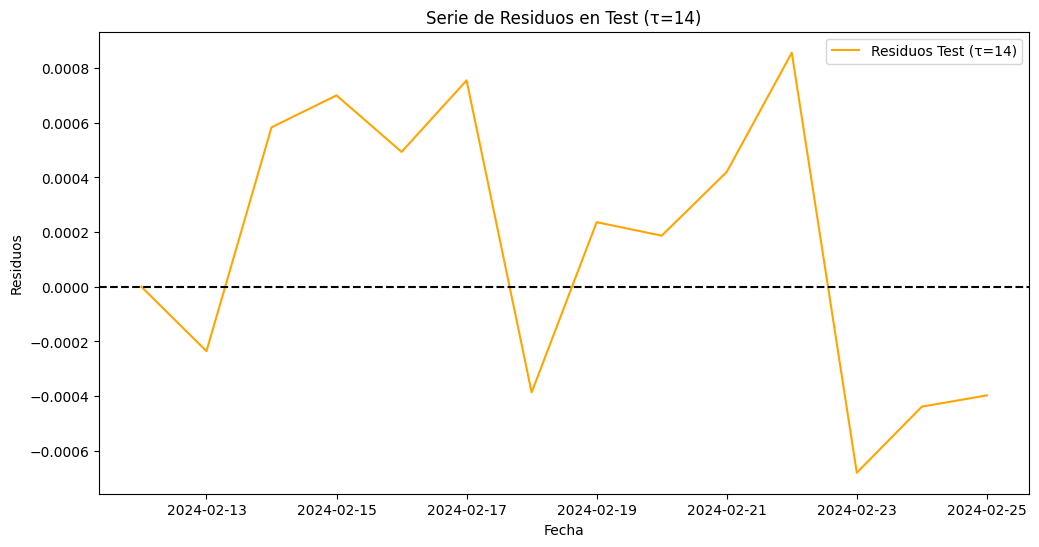

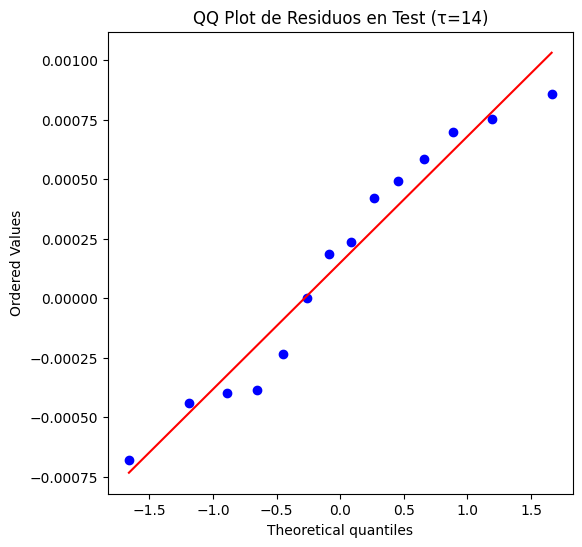

<Figure size 1000x500 with 0 Axes>

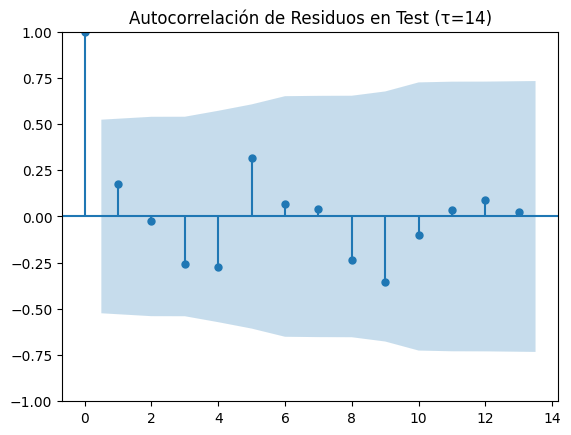

Resultados para τ = 21
                 Métrica                  Valor
0                    MAE               0.004176
1                    MSE               0.000029
2                   RMSE               0.005413
3                   MAPE              12.580723
4                     R2               0.718553
5    Ljung-Box (p-value)               0.000004
6          BDS (p-value)  5.609924367454026e-37
7  Jarque-Bera (p-value)               0.485836


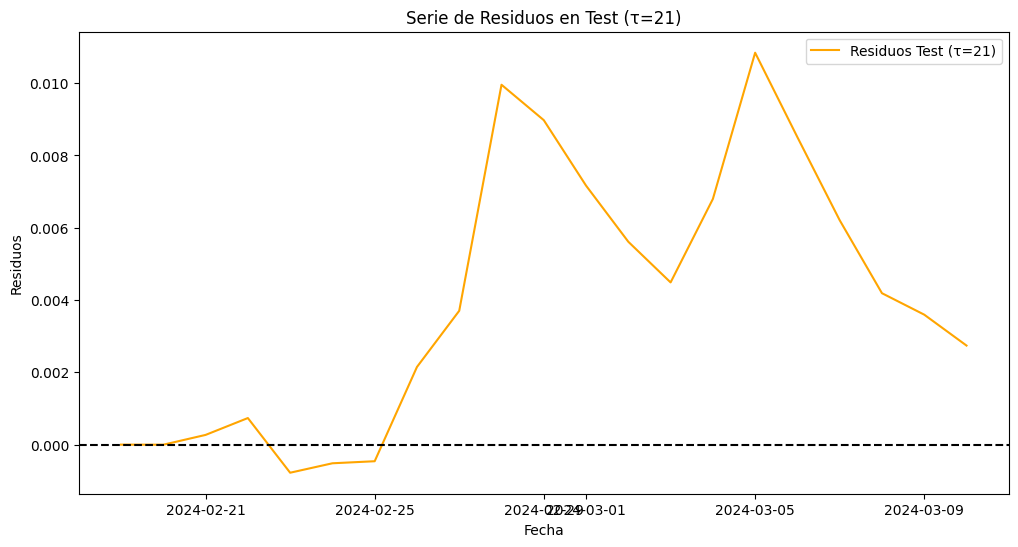

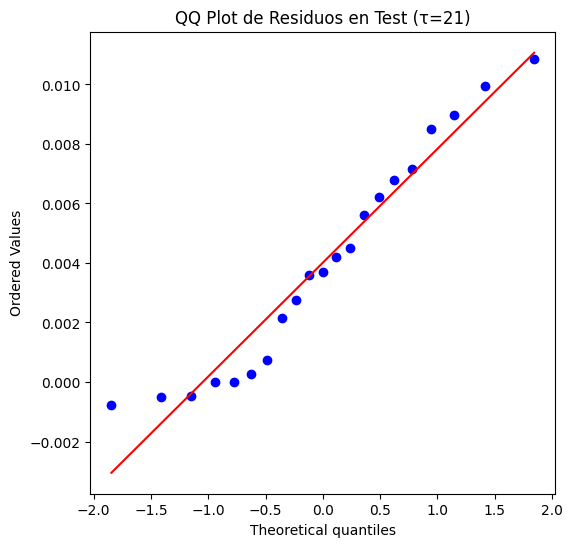

<Figure size 1000x500 with 0 Axes>

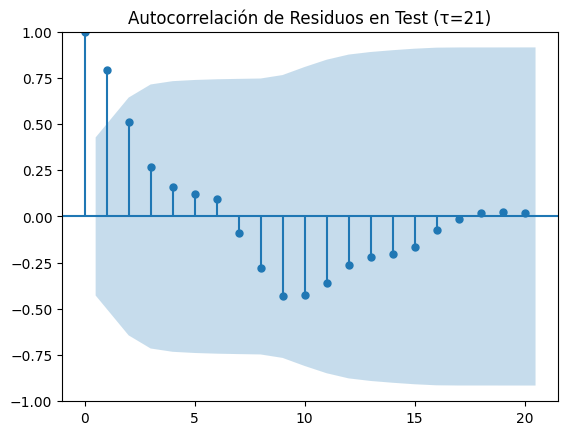

Resultados para τ = 28
                 Métrica                   Valor
0                    MAE                0.004206
1                    MSE                0.000024
2                   RMSE                0.004903
3                   MAPE               11.249736
4                     R2                0.467024
5    Ljung-Box (p-value)                0.000004
6          BDS (p-value)  2.9615956508120335e-05
7  Jarque-Bera (p-value)                0.782821


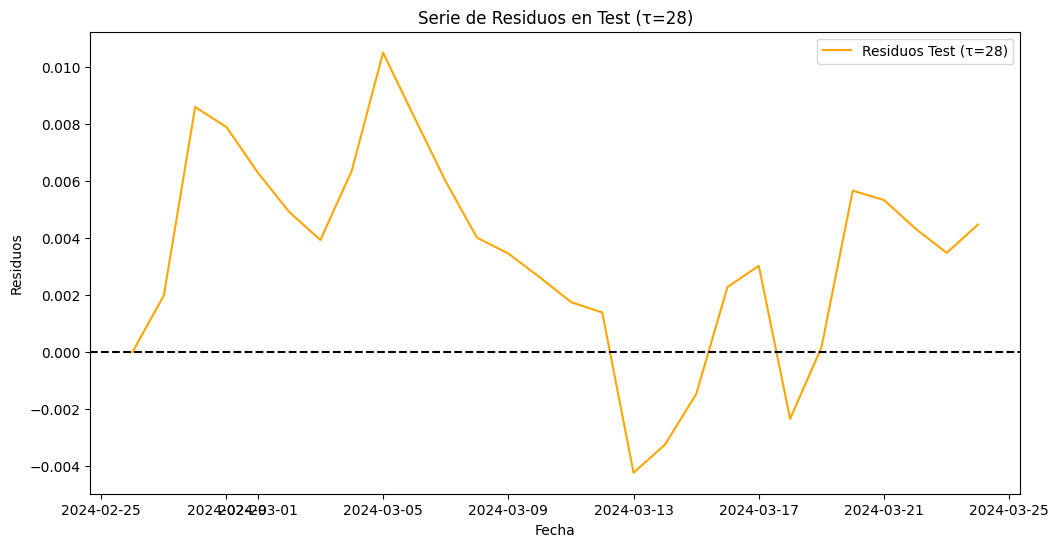

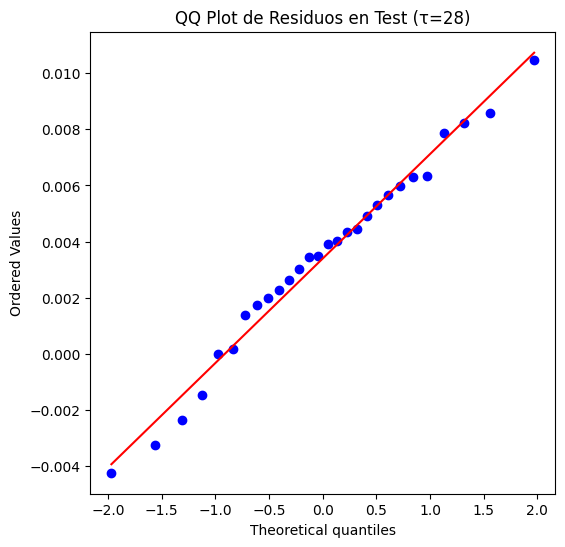

<Figure size 1000x500 with 0 Axes>

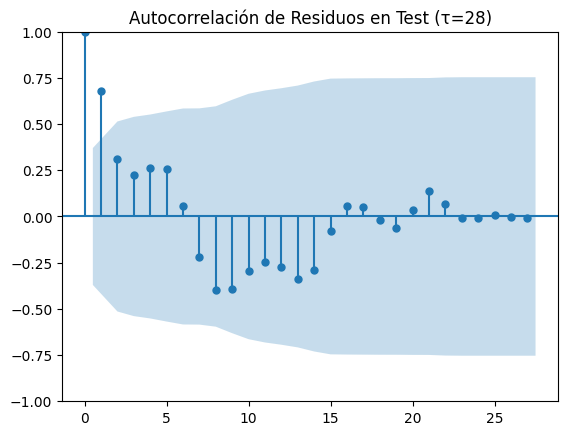

In [ ]:
# Simple Exponential Smoothing (Sin Librería) para la columna "Volatility_14d"

import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_14d"]]

# Función para Suavizamiento Exponencial Simple (SES)
def simple_exponential_smoothing(series, alpha):
    """
    Aplica el Suavizamiento Exponencial Simple (SES) a una serie temporal.
    Parámetros:
        series (array-like): Serie de tiempo original.
        alpha (float): Factor de suavizado (0 < alpha ≤ 1).
    Retorna:
        np.array: Serie suavizada.
    """
    smoothed_values = np.zeros(len(series))
    smoothed_values[0] = series[0]  # Inicializar con el primer valor
    for t in range(1, len(series)):
        smoothed_values[t] = alpha * series[t] + (1 - alpha) * smoothed_values[t-1]
    return smoothed_values

# Definir los tamaños de validación y test
tau_values = [7, 14, 21, 28]
for tau in tau_values:
    val_size = tau
    test_size = tau
    train_size = len(df) - (28 + 28)
    
    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:train_size + val_size + test_size]
    
    # Extraer la columna de la Volatilidad para 14 dias
    train_series = train_data['Volatility_14d'].values
    val_series = val_data['Volatility_14d'].values
    test_series = test_data['Volatility_14d'].values
    
    # Aplicar SES con un alpha de 0.2
    alpha = 0.2
    smoothed_train = simple_exponential_smoothing(train_series, alpha)
    smoothed_val = simple_exponential_smoothing(val_series, alpha)
    smoothed_test = simple_exponential_smoothing(test_series, alpha)
    
    # Calcular residuos
    test_residuals = test_series - smoothed_test

    # Evaluar en test
    test_mae, test_mse, test_rmse, test_mape, test_r2 = mean_absolute_error(test_series, smoothed_test), \
                                                         mean_squared_error(test_series, smoothed_test), \
                                                         np.sqrt(mean_squared_error(test_series, smoothed_test)), \
                                                         np.mean(np.abs((test_series - smoothed_test) / test_series)) * 100, \
                                                         r2_score(test_series, smoothed_test)
    
    # Ajustar número de lags para Ljung-Box
    max_lags = min(10, len(test_residuals) - 1)
    test_ljung_box_pvalue = acorr_ljungbox(test_residuals, lags=[max_lags], return_df=True)['lb_pvalue'].values[0] if max_lags > 0 else np.nan
    
    test_bds_stat, test_bds_pvalue = bds(test_residuals)
    test_jarque_bera_pvalue = jarque_bera(test_residuals)[1]
    
    # Crear DataFrame de resultados en test
    test_results = pd.DataFrame({
        'Métrica': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Ljung-Box (p-value)', 'BDS (p-value)', 'Jarque-Bera (p-value)'],
        'Valor': [test_mae, test_mse, test_rmse, test_mape, test_r2, test_ljung_box_pvalue, test_bds_pvalue, test_jarque_bera_pvalue]
    })
    print(f"Resultados para τ = {tau}")
    print(test_results)
    
    # Graficar residuos en test
    plt.figure(figsize=(12,6))
    plt.plot(test_data.index, test_residuals, label=f'Residuos Test (τ={tau})', color='orange')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Fecha')
    plt.ylabel('Residuos')
    plt.title(f'Serie de Residuos en Test (τ={tau})')
    plt.legend()
    plt.show()
    
    # QQPlot en test
    plt.figure(figsize=(6,6))
    probplot(test_residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot de Residuos en Test (τ={tau})")
    plt.show()
    
    # ACF de Residuos en test
    max_lags_acf = min(30, len(test_residuals) - 1)  # Ajustar lags para evitar errores
    if max_lags_acf > 0:
        plt.figure(figsize=(10,5))
        plot_acf(test_residuals, lags=max_lags_acf)
        plt.title(f"Autocorrelación de Residuos en Test (τ={tau})")
        plt.show()


Resultados para τ = 7
                 Métrica                 Valor
0                    MAE              0.000445
1                    MSE                   0.0
2                   RMSE              0.000514
3                   MAPE              2.227228
4                     R2              0.218705
5    Ljung-Box (p-value)              0.897904
6          BDS (p-value)  0.006375035730260818
7  Jarque-Bera (p-value)              0.693142


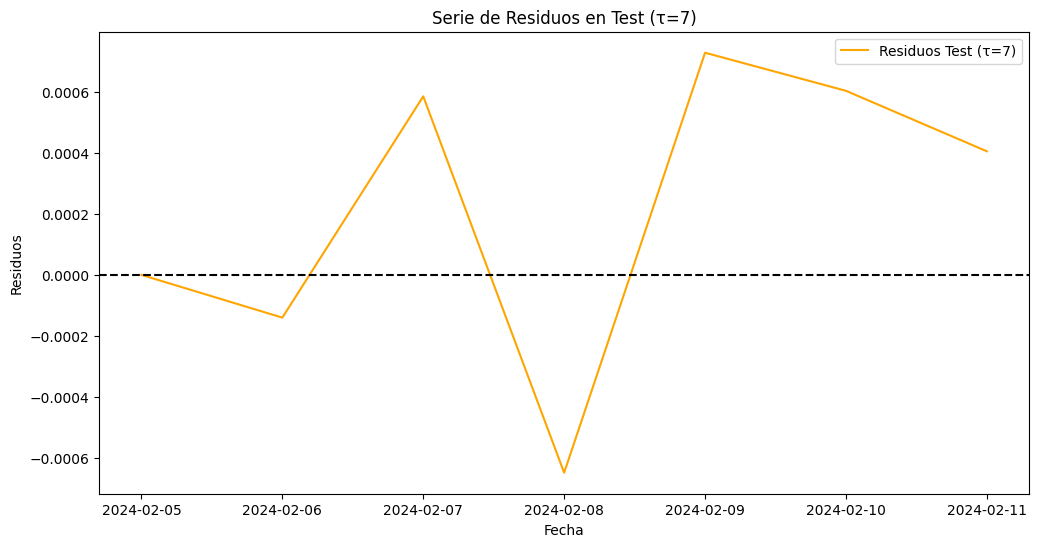

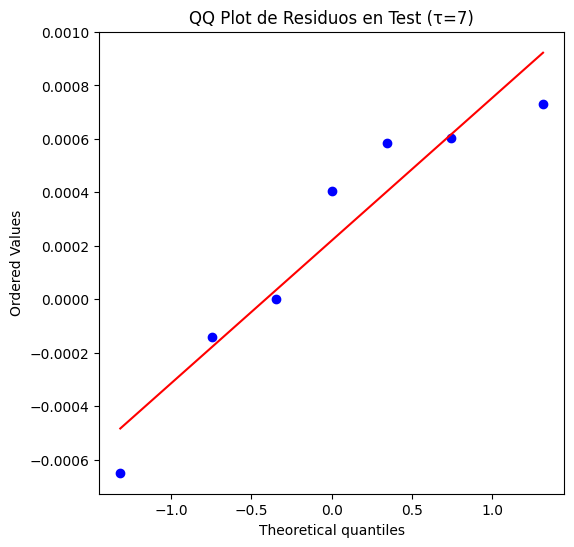

<Figure size 1000x500 with 0 Axes>

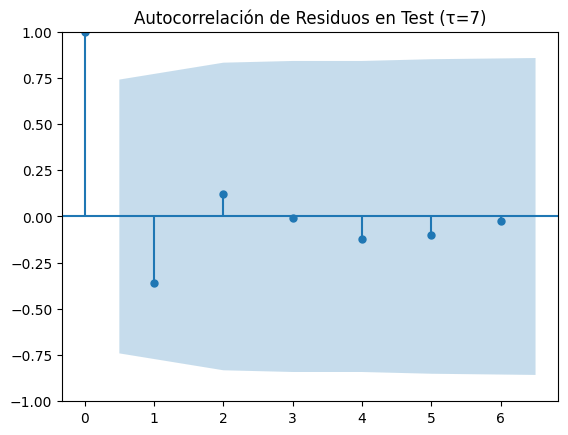

Resultados para τ = 14
                 Métrica               Valor
0                    MAE            0.000439
1                    MSE                 0.0
2                   RMSE            0.000548
3                   MAPE            2.610016
4                     R2            0.317536
5    Ljung-Box (p-value)            0.220962
6          BDS (p-value)  0.0822081976222411
7  Jarque-Bera (p-value)            0.605898


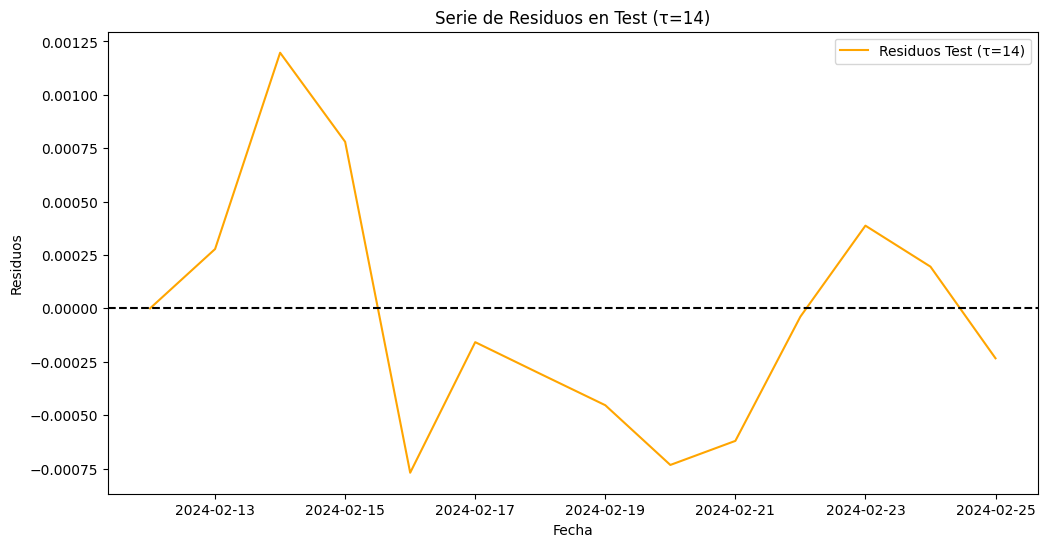

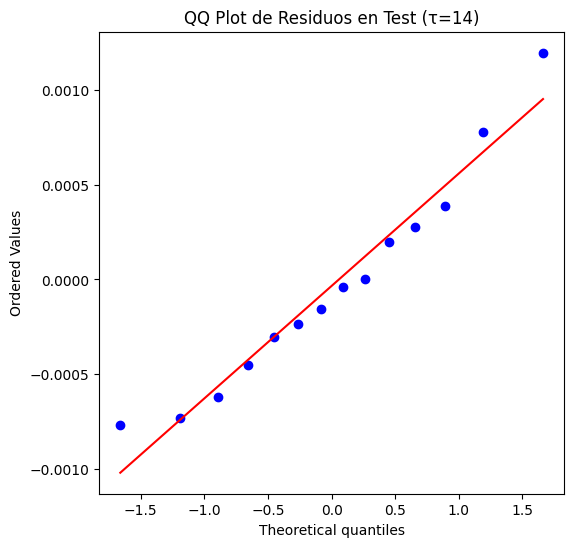

<Figure size 1000x500 with 0 Axes>

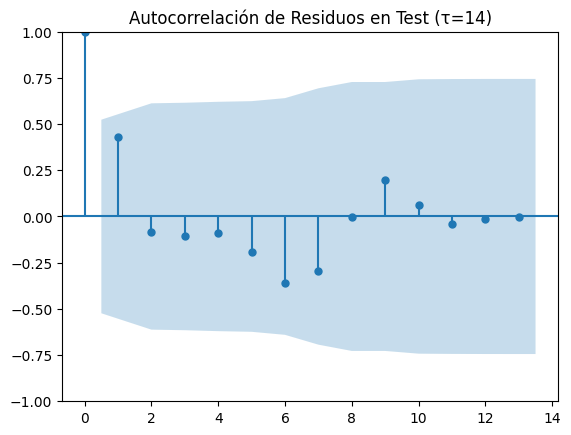

Resultados para τ = 21
                 Métrica                  Valor
0                    MAE               0.003218
1                    MSE               0.000017
2                   RMSE               0.004125
3                   MAPE              11.029666
4                     R2               0.725984
5    Ljung-Box (p-value)               0.000002
6          BDS (p-value)  1.807509024911329e-57
7  Jarque-Bera (p-value)               0.486947


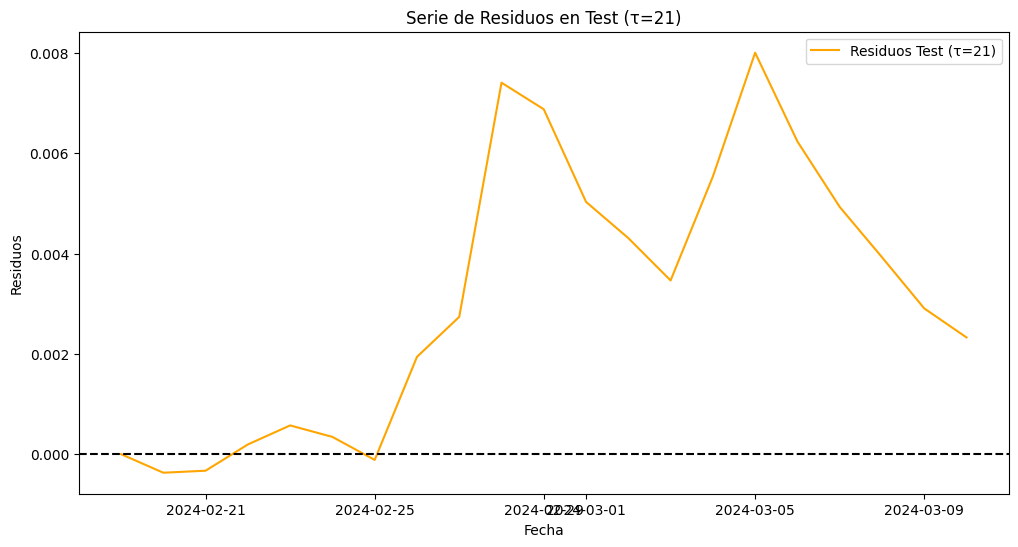

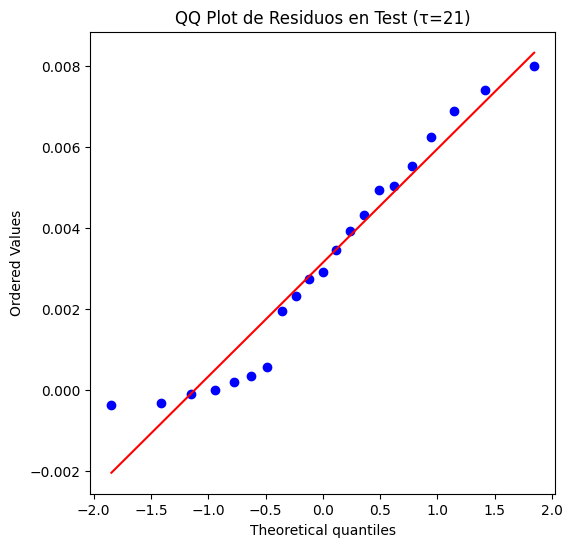

<Figure size 1000x500 with 0 Axes>

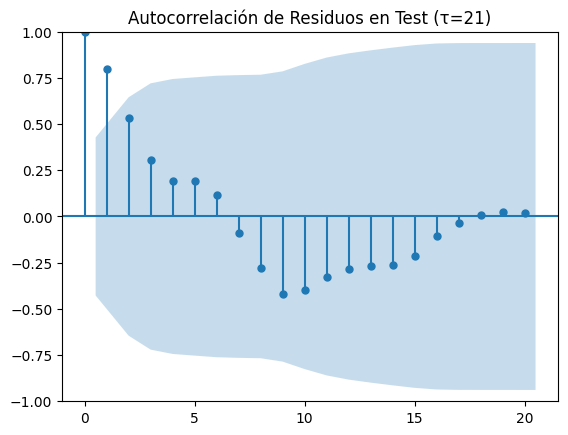

Resultados para τ = 28
                 Métrica                Valor
0                    MAE             0.003462
1                    MSE             0.000015
2                   RMSE             0.003872
3                   MAPE             9.998507
4                     R2             0.707474
5    Ljung-Box (p-value)             0.002078
6          BDS (p-value)  0.05892935377347646
7  Jarque-Bera (p-value)             0.729403


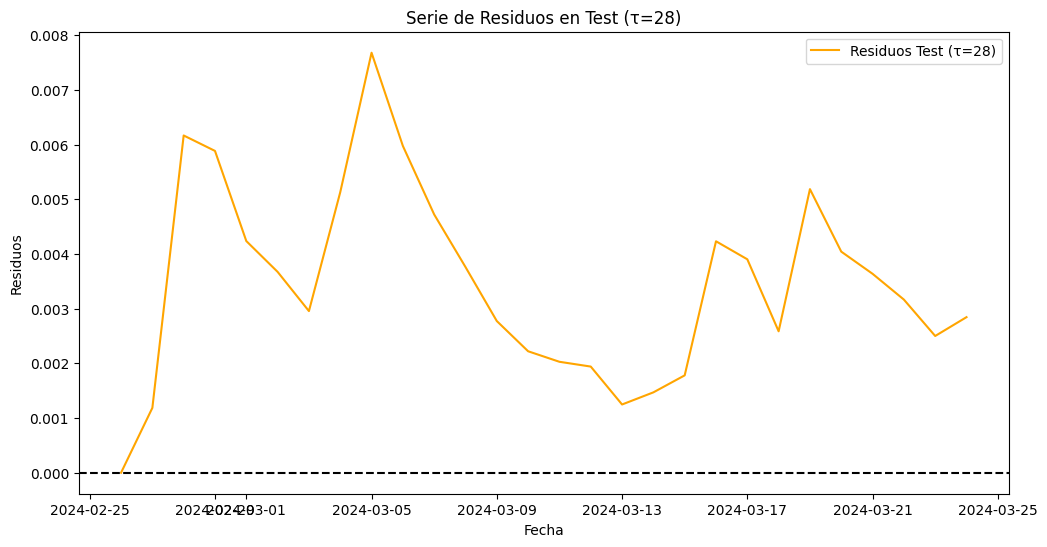

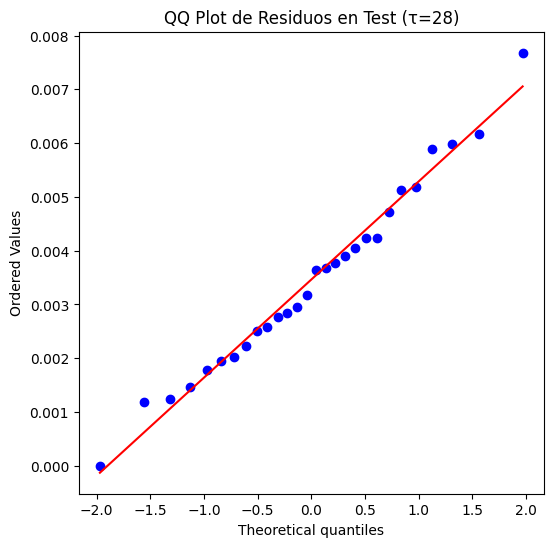

<Figure size 1000x500 with 0 Axes>

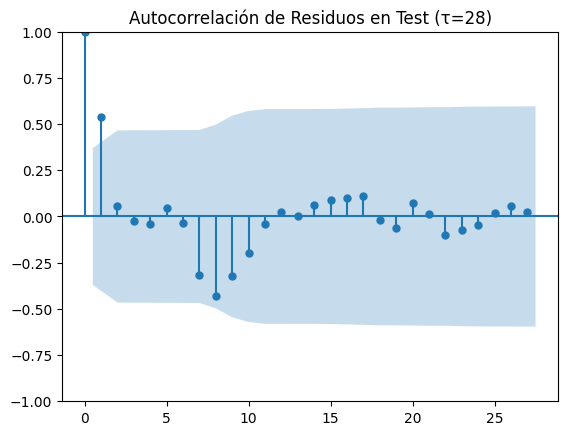

In [ ]:
# Simple Exponential Smoothing (Sin Librería) para la columna "Volatility_21d"

import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_21d"]]

# Función para Suavizamiento Exponencial Simple (SES)
def simple_exponential_smoothing(series, alpha):
    """
    Aplica el Suavizamiento Exponencial Simple (SES) a una serie temporal.
    Parámetros:
        series (array-like): Serie de tiempo original.
        alpha (float): Factor de suavizado (0 < alpha ≤ 1).
    Retorna:
        np.array: Serie suavizada.
    """
    smoothed_values = np.zeros(len(series))
    smoothed_values[0] = series[0]  # Inicializar con el primer valor
    for t in range(1, len(series)):
        smoothed_values[t] = alpha * series[t] + (1 - alpha) * smoothed_values[t-1]
    return smoothed_values

# Definir los tamaños de validación y test
tau_values = [7, 14, 21, 28]
for tau in tau_values:
    val_size = tau
    test_size = tau
    train_size = len(df) - (28 + 28)
    
    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:train_size + val_size + test_size]
    
    # Extraer la columna de la Volatilidad para 21 dias
    train_series = train_data['Volatility_21d'].values
    val_series = val_data['Volatility_21d'].values
    test_series = test_data['Volatility_21d'].values
    
    # Aplicar SES con un alpha de 0.2
    alpha = 0.2
    smoothed_train = simple_exponential_smoothing(train_series, alpha)
    smoothed_val = simple_exponential_smoothing(val_series, alpha)
    smoothed_test = simple_exponential_smoothing(test_series, alpha)
    
    # Calcular residuos
    test_residuals = test_series - smoothed_test

    # Evaluar en test
    test_mae, test_mse, test_rmse, test_mape, test_r2 = mean_absolute_error(test_series, smoothed_test), \
                                                         mean_squared_error(test_series, smoothed_test), \
                                                         np.sqrt(mean_squared_error(test_series, smoothed_test)), \
                                                         np.mean(np.abs((test_series - smoothed_test) / test_series)) * 100, \
                                                         r2_score(test_series, smoothed_test)
    
    # Ajustar número de lags para Ljung-Box
    max_lags = min(10, len(test_residuals) - 1)
    test_ljung_box_pvalue = acorr_ljungbox(test_residuals, lags=[max_lags], return_df=True)['lb_pvalue'].values[0] if max_lags > 0 else np.nan
    
    test_bds_stat, test_bds_pvalue = bds(test_residuals)
    test_jarque_bera_pvalue = jarque_bera(test_residuals)[1]
    
    # Crear DataFrame de resultados en test
    test_results = pd.DataFrame({
        'Métrica': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Ljung-Box (p-value)', 'BDS (p-value)', 'Jarque-Bera (p-value)'],
        'Valor': [test_mae, test_mse, test_rmse, test_mape, test_r2, test_ljung_box_pvalue, test_bds_pvalue, test_jarque_bera_pvalue]
    })
    print(f"Resultados para τ = {tau}")
    print(test_results)
    
    # Graficar residuos en test
    plt.figure(figsize=(12,6))
    plt.plot(test_data.index, test_residuals, label=f'Residuos Test (τ={tau})', color='orange')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Fecha')
    plt.ylabel('Residuos')
    plt.title(f'Serie de Residuos en Test (τ={tau})')
    plt.legend()
    plt.show()
    
    # QQPlot en test
    plt.figure(figsize=(6,6))
    probplot(test_residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot de Residuos en Test (τ={tau})")
    plt.show()
    
    # ACF de Residuos en test
    max_lags_acf = min(30, len(test_residuals) - 1)  # Ajustar lags para evitar errores
    if max_lags_acf > 0:
        plt.figure(figsize=(10,5))
        plot_acf(test_residuals, lags=max_lags_acf)
        plt.title(f"Autocorrelación de Residuos en Test (τ={tau})")
        plt.show()


Resultados para τ = 7
                 Métrica                 Valor
0                    MAE              0.001095
1                    MSE              0.000002
2                   RMSE              0.001456
3                   MAPE               5.28325
4                     R2              0.272089
5    Ljung-Box (p-value)              0.262786
6          BDS (p-value)  0.025237089354517666
7  Jarque-Bera (p-value)              0.618571


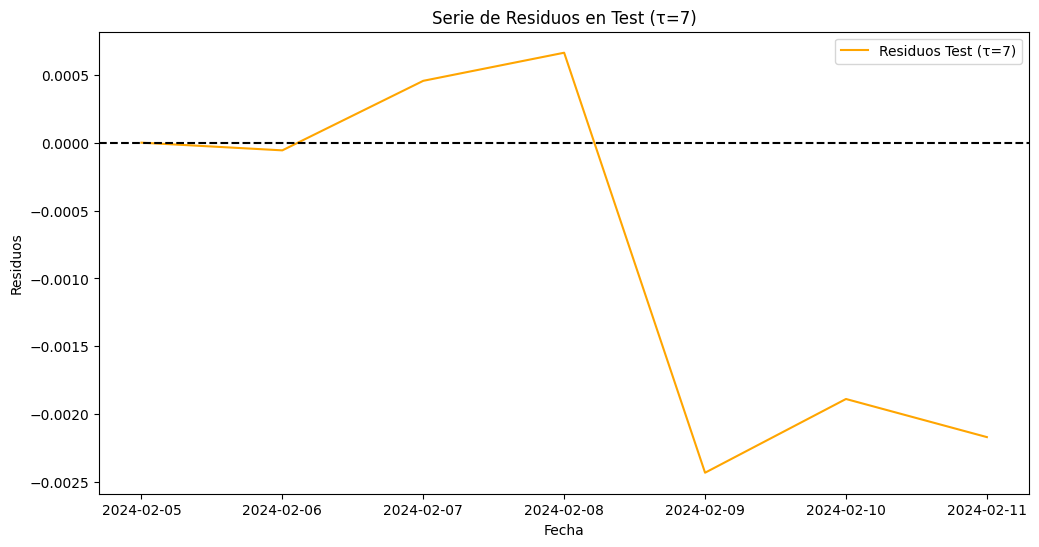

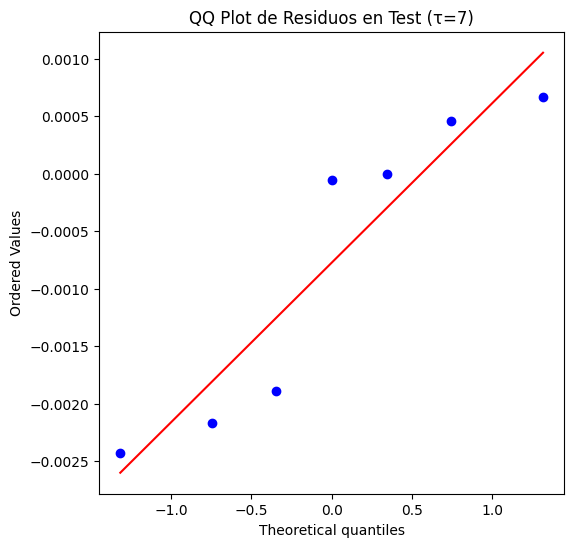

<Figure size 1000x500 with 0 Axes>

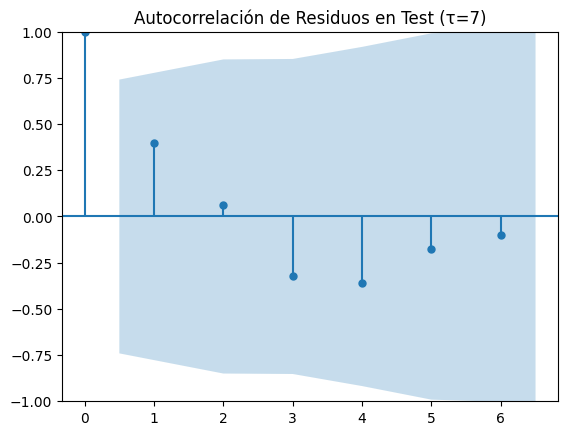

Resultados para τ = 14
                 Métrica                Valor
0                    MAE             0.001021
1                    MSE             0.000002
2                   RMSE             0.001299
3                   MAPE             5.995267
4                     R2             0.529255
5    Ljung-Box (p-value)             0.025611
6          BDS (p-value)  0.06840193413328799
7  Jarque-Bera (p-value)             0.832433


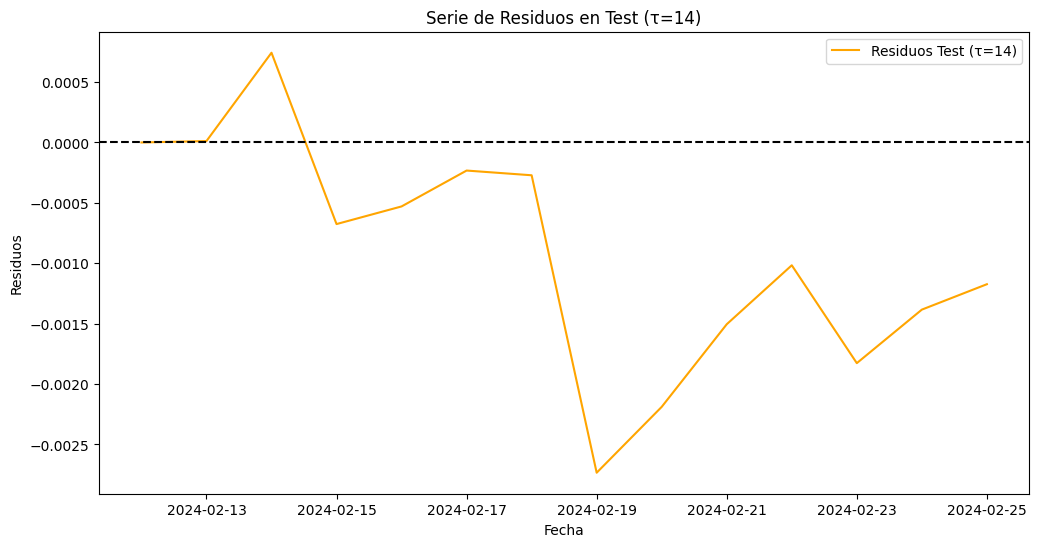

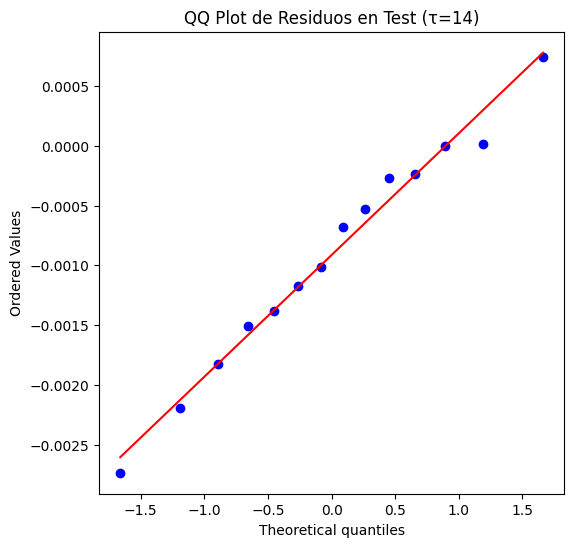

<Figure size 1000x500 with 0 Axes>

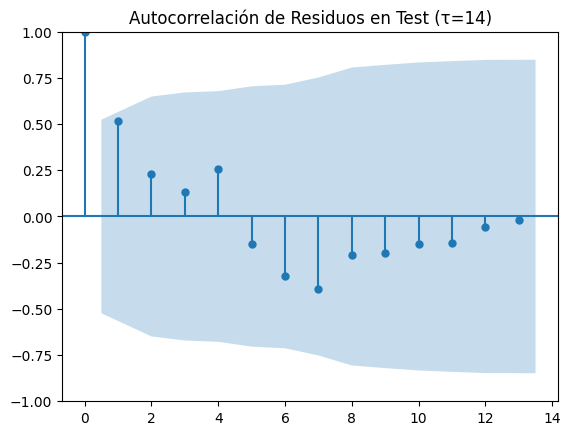

Resultados para τ = 21
                 Métrica                  Valor
0                    MAE               0.002608
1                    MSE               0.000011
2                   RMSE               0.003343
3                   MAPE               9.798349
4                     R2               0.719415
5    Ljung-Box (p-value)               0.000005
6          BDS (p-value)  7.847150532494606e-47
7  Jarque-Bera (p-value)               0.478852


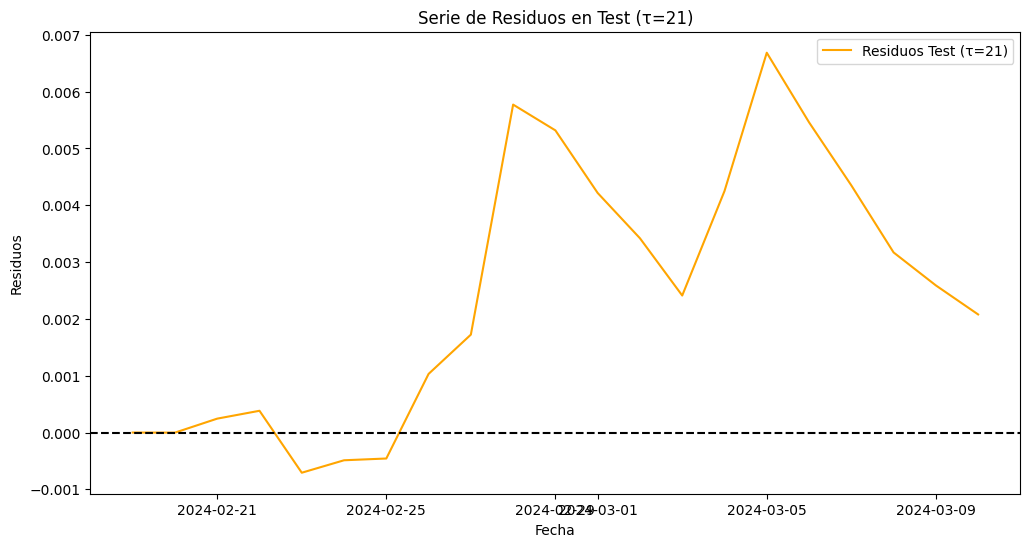

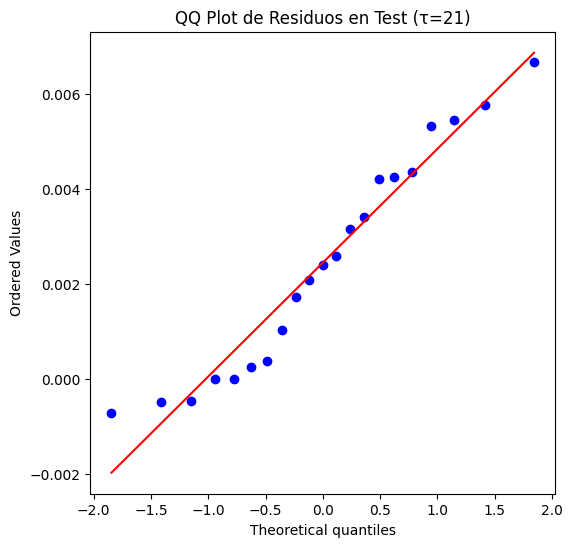

<Figure size 1000x500 with 0 Axes>

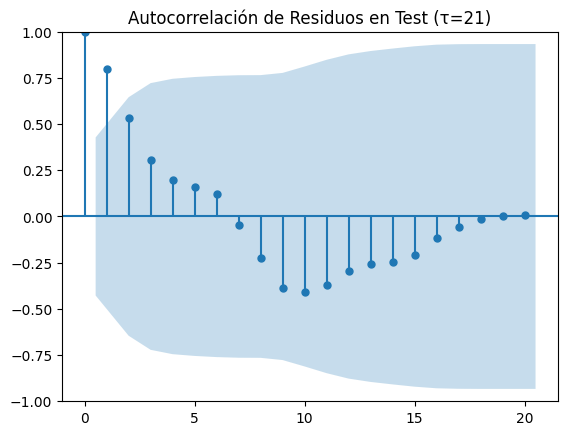

Resultados para τ = 28
                 Métrica                 Valor
0                    MAE              0.003375
1                    MSE              0.000014
2                   RMSE              0.003797
3                   MAPE             10.291224
4                     R2              0.732755
5    Ljung-Box (p-value)              0.000002
6          BDS (p-value)  2.03821140515232e-09
7  Jarque-Bera (p-value)              0.648471


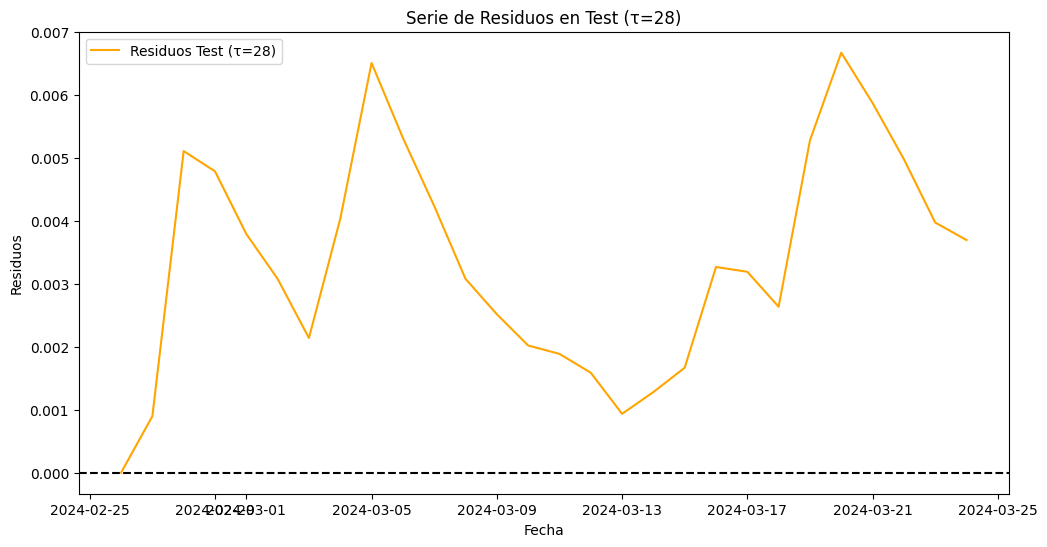

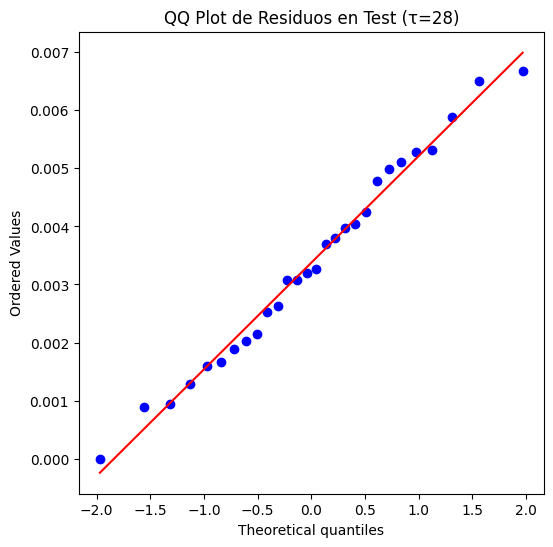

<Figure size 1000x500 with 0 Axes>

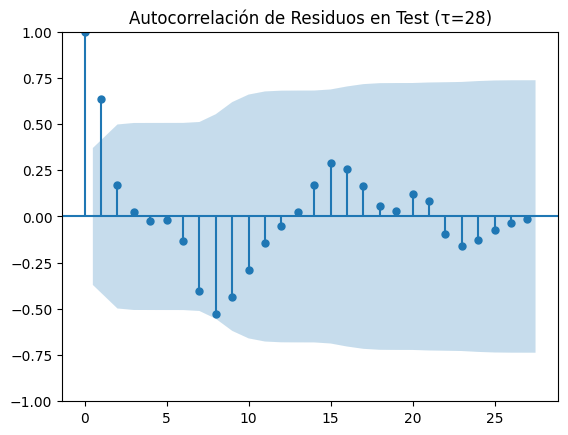

In [ ]:
# Simple Exponential Smoothing (Sin Librería) para la columna "Volatility_28d"

import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_28d"]]

# Función para Suavizamiento Exponencial Simple (SES)
def simple_exponential_smoothing(series, alpha):
    """
    Aplica el Suavizamiento Exponencial Simple (SES) a una serie temporal.
    Parámetros:
        series (array-like): Serie de tiempo original.
        alpha (float): Factor de suavizado (0 < alpha ≤ 1).
    Retorna:
        np.array: Serie suavizada.
    """
    smoothed_values = np.zeros(len(series))
    smoothed_values[0] = series[0]  # Inicializar con el primer valor
    for t in range(1, len(series)):
        smoothed_values[t] = alpha * series[t] + (1 - alpha) * smoothed_values[t-1]
    return smoothed_values

# Definir los tamaños de validación y test
tau_values = [7, 14, 21, 28]
for tau in tau_values:
    val_size = tau
    test_size = tau
    train_size = len(df) - (28 + 28)
    
    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:train_size + val_size + test_size]
    
    # Extraer la columna de la Volatilidad para 28 dias
    train_series = train_data['Volatility_28d'].values
    val_series = val_data['Volatility_28d'].values
    test_series = test_data['Volatility_28d'].values
    
    # Aplicar SES con un alpha de 0.2
    alpha = 0.2
    smoothed_train = simple_exponential_smoothing(train_series, alpha)
    smoothed_val = simple_exponential_smoothing(val_series, alpha)
    smoothed_test = simple_exponential_smoothing(test_series, alpha)
    
    # Calcular residuos
    test_residuals = test_series - smoothed_test

    # Evaluar en test
    test_mae, test_mse, test_rmse, test_mape, test_r2 = mean_absolute_error(test_series, smoothed_test), \
                                                         mean_squared_error(test_series, smoothed_test), \
                                                         np.sqrt(mean_squared_error(test_series, smoothed_test)), \
                                                         np.mean(np.abs((test_series - smoothed_test) / test_series)) * 100, \
                                                         r2_score(test_series, smoothed_test)
    
    # Ajustar número de lags para Ljung-Box
    max_lags = min(10, len(test_residuals) - 1)
    test_ljung_box_pvalue = acorr_ljungbox(test_residuals, lags=[max_lags], return_df=True)['lb_pvalue'].values[0] if max_lags > 0 else np.nan
    
    test_bds_stat, test_bds_pvalue = bds(test_residuals)
    test_jarque_bera_pvalue = jarque_bera(test_residuals)[1]
    
    # Crear DataFrame de resultados en test
    test_results = pd.DataFrame({
        'Métrica': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Ljung-Box (p-value)', 'BDS (p-value)', 'Jarque-Bera (p-value)'],
        'Valor': [test_mae, test_mse, test_rmse, test_mape, test_r2, test_ljung_box_pvalue, test_bds_pvalue, test_jarque_bera_pvalue]
    })
    print(f"Resultados para τ = {tau}")
    print(test_results)
    
    # Graficar residuos en test
    plt.figure(figsize=(12,6))
    plt.plot(test_data.index, test_residuals, label=f'Residuos Test (τ={tau})', color='orange')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Fecha')
    plt.ylabel('Residuos')
    plt.title(f'Serie de Residuos en Test (τ={tau})')
    plt.legend()
    plt.show()
    
    # QQPlot en test
    plt.figure(figsize=(6,6))
    probplot(test_residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot de Residuos en Test (τ={tau})")
    plt.show()
    
    # ACF de Residuos en test
    max_lags_acf = min(30, len(test_residuals) - 1)  # Ajustar lags para evitar errores
    if max_lags_acf > 0:
        plt.figure(figsize=(10,5))
        plot_acf(test_residuals, lags=max_lags_acf)
        plt.title(f"Autocorrelación de Residuos en Test (τ={tau})")
        plt.show()


## *Simple Exponential Smoothing (Usando statsmodels.tsa.holtwinters)*

In [ ]:
# =============================================================================
# Importación de bibliotecas necesarias
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Definición de funciones para el análisis
# =============================================================================

# Función para mostrar tablas sin depender de tabulate
def display_table(df, floatfmt='.4f'):
    """
    Muestra un DataFrame como una tabla formateada sin depender de librerías externas.
    """
    return df.to_string(index=False, float_format=lambda x: f"{x:{floatfmt}}")

# Función para la Suavización Exponencial Simple (SES)
def simple_exponential_smoothing(data, alpha):
    """
    Realiza suavización exponencial simple en una serie de tiempo.

    Parámetros:
    data (array-like): Serie de tiempo original
    alpha (float): Parámetro de suavización, debe estar entre 0 y 1

    Retorna:
    tuple: (Serie suavizada, predicciones)
    """
    if not 0 <= alpha <= 1:
        raise ValueError("El parámetro alpha debe estar entre 0 y 1")

    data = np.array(data)
    n = len(data)

    # Inicialización
    smoothed = np.zeros(n)
    smoothed[0] = data[0]  # El primer valor suavizado es igual al primer valor original

    # Aplicar la fórmula SES: St = alpha * Yt + (1-alpha) * St-1
    for t in range(1, n):
        smoothed[t] = alpha * data[t] + (1 - alpha) * smoothed[t-1]

    # Predicción para el siguiente período
    forecast = smoothed[-1]

    return smoothed, forecast

# Función para realizar pronósticos estándar
def forecast_ses(train_data, forecast_horizon, alpha):
    """
    Realiza pronósticos con el método estándar (un solo valor).

    Parámetros:
    train_data (array-like): Datos de entrenamiento
    forecast_horizon (int): Número de períodos a pronosticar
    alpha (float): Parámetro de suavización

    Retorna:
    array: Pronóstico para el horizonte especificado
    """
    smoothed, last_forecast = simple_exponential_smoothing(train_data, alpha)

    # Para SES estándar, el pronóstico es el mismo valor para todos los períodos futuros
    forecast = np.full(forecast_horizon, last_forecast)

    return forecast

# Función para realizar pronósticos rolling
def rolling_forecast_ses(train_data, forecast_horizon, alpha):
    """
    Realiza pronósticos de suavizado exponencial simple con enfoque rolling.

    Parámetros:
    train_data (array-like): Datos de entrenamiento iniciales
    forecast_horizon (int): Número de períodos a pronosticar
    alpha (float): Parámetro de suavización

    Retorna:
    array: Pronósticos para el horizonte especificado
    """
    forecasts = np.zeros(forecast_horizon)
    data = np.array(train_data).copy()

    for i in range(forecast_horizon):
        # Realizar suavizado exponencial con los datos actuales
        smoothed, next_forecast = simple_exponential_smoothing(data, alpha)

        # Guardar el pronóstico para el siguiente período
        forecasts[i] = next_forecast

        # Actualizar los datos para la siguiente iteración
        # Aquí simulamos que ya conocemos el valor real y lo incorporamos
        if i < forecast_horizon - 1:  # No necesitamos actualizar en la última iteración
            # En un escenario real, aquí iría el valor observado
            # Como no tenemos valores futuros reales, usamos el pronóstico como sustituto
            data = np.append(data, next_forecast)

    return forecasts

In [ ]:
# Función para realizar predicciones con método rolling utilizando datos reales
def rolling_forecast_with_actuals(train_data, test_data, alpha):
    """
    Realiza pronósticos rolling utilizando valores reales para actualizar el modelo.

    Parámetros:
    train_data (array-like): Datos de entrenamiento iniciales
    test_data (array-like): Datos reales de test/validación
    alpha (float): Parámetro de suavización

    Retorna:
    array: Pronósticos para cada punto del conjunto de test
    """
    forecast_horizon = len(test_data)
    forecasts = np.zeros(forecast_horizon)
    data = np.array(train_data).copy()

    for i in range(forecast_horizon):
        # Realizar suavizado exponencial con los datos actuales
        smoothed, next_forecast = simple_exponential_smoothing(data, alpha)

        # Guardar el pronóstico para el siguiente período
        forecasts[i] = next_forecast

        # Actualizar los datos con el valor real observado
        if i < forecast_horizon - 1:  # No necesitamos actualizar en la última iteración
            data = np.append(data, test_data[i])

    return forecasts

# Función para calcular métricas de evaluación
def calculate_metrics(actual, predicted):
    """
    Calcula las métricas de evaluación para los pronósticos.

    Parámetros:
    actual (array-like): Valores reales
    predicted (array-like): Valores pronosticados

    Retorna:
    dict: Métricas calculadas
    """
    actual = np.array(actual)
    predicted = np.array(predicted)

    # Evitar división por cero en MAPE
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    return {
        'MAPE': mape,
        'MAE': mae,
        'RMSE': rmse,
        'MSE': mse,
        'R2': r2
    }

# Función para realizar pruebas estadísticas en los residuos
def residual_tests(residuals):
    """
    Realiza pruebas estadísticas en los residuos.
    Adaptado para manejar series de tiempo cortas.

    Parámetros:
    residuals (array-like): Residuos del modelo

    Retorna:
    dict: Resultados de las pruebas
    """
    # Verificar si hay suficientes datos para las pruebas
    if len(residuals) < 5:
        return {
            'Ljung-Box (p-value)': np.nan,
            'Jarque-Bera (p-value)': np.nan,
            'ARCH (p-value)': np.nan
        }

    # Ljung-Box test para independencia
    # Determinar el número de lags basado en el tamaño de la muestra
    # No debe exceder (n-2)/2 como regla general
    n = len(residuals)
    max_lag = min(10, int((n-2)/2))
    max_lag = max(1, max_lag)  # Asegurar al menos 1 lag

    try:
        lb_test = acorr_ljungbox(residuals, lags=[max_lag])
        lb_pvalue = lb_test.iloc[0, 1]  # p-value
    except:
        # En caso de error, asignar NaN
        lb_pvalue = np.nan

    # Jarque-Bera test para normalidad
    try:
        # Jarque-Bera requiere al menos 8 observaciones según la docs de scipy
        if len(residuals) >= 8:
            jb_stat, jb_pvalue = jarque_bera(residuals)
        else:
            jb_pvalue = np.nan
    except:
        jb_pvalue = np.nan

    # Prueba ARCH para independencia (alternativa a BDS)
    try:
        # Usar prueba ARCH para heteroscedasticidad como alternativa a BDS
        # Determinar nlags apropiado (típicamente no más de n/4)
        nlags = min(5, max(1, len(residuals) // 4))
        _, arch_pvalue, _, _ = het_arch(residuals, nlags=nlags)
    except:
        arch_pvalue = np.nan

    return {
        'Ljung-Box (p-value)': lb_pvalue,
        'Jarque-Bera (p-value)': jb_pvalue,
        'ARCH (p-value)': arch_pvalue
    }

In [ ]:
# Función para visualizar los residuos
def plot_residuals(residuals, title):
    """
    Crea gráficos para el análisis de residuos.
    Adaptado para manejar series de tiempo cortas.

    Parámetros:
    residuals (array-like): Residuos del modelo
    title (str): Título para los gráficos
    """
    # Verificar que hay suficientes datos para graficar
    if len(residuals) < 5:
        print(f"No hay suficientes datos para graficar residuos para {title}")
        return

    fig, axes = plt.subplots(3, 1, figsize=(10, 12))

    # Serie de residuos
    axes[0].plot(residuals)
    axes[0].set_title(f'Serie de Residuos - {title}')
    axes[0].set_xlabel('Índice')
    axes[0].set_ylabel('Residuo')
    axes[0].grid(True, alpha=0.3)

    # QQ Plot
    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].set_title(f'QQ Plot - {title}')
    axes[1].grid(True, alpha=0.3)

    # ACF de residuos (no más de n/3 lags)
    max_lags = min(20, len(residuals) // 3)
    max_lags = max(1, max_lags)
    plot_acf(residuals, lags=max_lags, ax=axes[2])
    axes[2].set_title(f'ACF de Residuos - {title}')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Función para visualizar la serie original y los pronósticos
def plot_forecasts(original, train, validation, test, validation_pred, test_pred, title, tau):
    """
    Visualiza la serie original y los pronósticos.

    Parámetros:
    original (Series): Serie completa
    train (Series): Datos de entrenamiento
    validation (Series): Datos de validación
    test (Series): Datos de prueba
    validation_pred (array): Pronósticos para validación
    test_pred (array): Pronósticos para prueba
    title (str): Título del gráfico
    tau (int): Tamaño de los conjuntos de validación y prueba
    """
    plt.figure(figsize=(12, 6))

    # Convertir índices a posiciones numéricas para el gráfico
    x_train = np.arange(len(train))
    x_val = np.arange(len(train), len(train) + len(validation))
    x_test = np.arange(len(train) + len(validation), len(train) + len(validation) + len(test))

    # Graficar serie original
    plt.plot(np.arange(len(original)), original, 'b-', label='Serie Original', alpha=0.5)

    # Graficar pronósticos
    plt.plot(x_val, validation_pred, 'r-', label='Pronóstico Validación', linewidth=2)
    plt.plot(x_test, test_pred, 'g-', label='Pronóstico Test', linewidth=2)

    # Marcar las divisiones entre conjuntos
    plt.axvline(x=len(train), color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=len(train) + len(validation), color='k', linestyle='--', alpha=0.3)

    plt.title(f'{title} - Serie Completa (τ = {tau})')
    plt.xlabel('Índice de Tiempo')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Función para visualizar las últimas 224 observaciones con pronósticos
def plot_focused_forecasts(original, train, validation, test, validation_pred, test_pred, title, tau):
    """
    Visualiza las últimas 224 observaciones con énfasis en los pronósticos.

    Parámetros:
    original (Series): Serie completa
    train (Series): Datos de entrenamiento
    validation (Series): Datos de validación
    test (Series): Datos de prueba
    validation_pred (array): Pronósticos para validación
    test_pred (array): Pronósticos para prueba
    title (str): Título del gráfico
    tau (int): Tamaño de los conjuntos de validación y prueba
    """
    # Determinar el total de observaciones
    total_obs = len(original)

    # Si tenemos menos de 224 observaciones, usar todas
    if total_obs <= 224:
        focus_start = 0
    else:
        focus_start = total_obs - 224

    # Índices para el gráfico
    train_end = len(train)
    val_start = train_end
    val_end = val_start + len(validation)
    test_start = val_end

    # Recortar para mostrar solo las últimas 224 observaciones
    plt.figure(figsize=(14, 7))

    # Índices para el gráfico
    x_indices = np.arange(total_obs)
    focus_indices = x_indices[focus_start:]

    # Graficar serie original (últimas 224 observaciones)
    plt.plot(focus_indices, original[focus_start:], 'b-', label='Serie Original', alpha=0.5)

    # Determinar qué partes de validación y test están dentro de las últimas 224 observaciones
    if val_start >= focus_start:
        # Validación completa visible
        plt.plot(x_indices[val_start:val_end], validation_pred, 'r-', label='Pronóstico Validación', linewidth=2)
    elif val_end > focus_start:
        # Validación parcialmente visible
        visible_val_start = focus_start
        visible_val_offset = visible_val_start - val_start
        plt.plot(
            x_indices[visible_val_start:val_end],
            validation_pred[visible_val_offset:],
            'r-',
            label='Pronóstico Validación',
            linewidth=2
        )

    if test_start >= focus_start:
        # Test completo visible
        plt.plot(x_indices[test_start:test_start+len(test)], test_pred, 'g-', label='Pronóstico Test', linewidth=2)
    elif test_start + len(test) > focus_start:
        # Test parcialmente visible
        visible_test_start = focus_start
        visible_test_offset = visible_test_start - test_start
        plt.plot(
            x_indices[visible_test_start:test_start+len(test)],
            test_pred[visible_test_offset:],
            'g-',
            label='Pronóstico Test',
            linewidth=2
        )

    # Marcar las divisiones entre conjuntos si están dentro del rango visible
    if train_end >= focus_start:
        plt.axvline(x=train_end, color='k', linestyle='--', alpha=0.3)
    if val_end >= focus_start:
        plt.axvline(x=val_end, color='k', linestyle='--', alpha=0.3)

    plt.title(f'{title} - Últimas 224 Observaciones (τ = {tau})')
    plt.xlabel('Índice de Tiempo')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# Función principal para analizar una variable
def analyze_variable(df, variable_name, alphas=[0.1, 0.3, 0.5, 0.7, 0.9]):
    """
    Realiza el análisis completo de SES para una variable.

    Parámetros:
    df (DataFrame): DataFrame con los datos
    variable_name (str): Nombre de la variable a analizar
    alphas (list): Lista de valores alpha a probar
    """
    print(f"\n{'='*80}")
    print(f"ANÁLISIS DE SUAVIZACIÓN EXPONENCIAL SIMPLE PARA: {variable_name}")
    print(f"{'='*80}\n")

    series = df[variable_name].values
    N = len(series)

    # Definir tamaños para los conjuntos de validación y prueba
    tau_values = [7, 14, 21, 28]

    # Para cada tau, definir los conjuntos y evaluar el modelo
    for tau in tau_values:
        # Verificar si hay suficientes datos para este valor de tau
        if N < (tau + tau + 10):  # Al menos 10 observaciones para entrenamiento
            print(f"Insuficientes datos para τ = {tau}. Se necesitan al menos {tau + tau + 10} observaciones.")
            continue

        print(f"\n{'-'*40}")
        print(f"ANÁLISIS PARA τ = {tau}")
        print(f"{'-'*40}\n")

        # Definir los conjuntos
        train_size = N - (tau + tau)
        train_data = series[:train_size]
        validation_data = series[train_size:train_size + tau]
        test_data = series[train_size + tau:train_size + tau + tau]

        # Datos para visualización
        train_series = df[variable_name].iloc[:train_size]
        validation_series = df[variable_name].iloc[train_size:train_size + tau]
        test_series = df[variable_name].iloc[train_size + tau:train_size + tau + tau]

In [ ]:
# Evaluar diferentes valores de alpha y seleccionar el mejor
        validation_results = []

        for alpha in alphas:
            # Entrenar y pronosticar para validación con método estándar
            validation_pred = forecast_ses(train_data, tau, alpha)

            # Calcular métricas
            metrics = calculate_metrics(validation_data, validation_pred)
            metrics['Alpha'] = alpha
            validation_results.append(metrics)

        # Convertir a DataFrame y ordenar por RMSE
        validation_df = pd.DataFrame(validation_results)
        validation_df = validation_df.sort_values('RMSE')

        print("Resultados de Validación:")
        print(display_table(validation_df))

        # Seleccionar el mejor alpha
        best_alpha = validation_df.iloc[0]['Alpha']
        print(f"\nMejor Alpha seleccionado: {best_alpha}")

In [ ]:
# Entrenar con el mejor alpha
        train_smoothed, _ = simple_exponential_smoothing(train_data, best_alpha)

        # Calcular residuos en entrenamiento
        train_residuals = train_data - train_smoothed

        # Pronosticar para validación con método rolling
        validation_pred_rolling = rolling_forecast_with_actuals(train_data, validation_data, best_alpha)

        # Evaluar en validación
        validation_metrics_rolling = calculate_metrics(validation_data, validation_pred_rolling)

        print("\nResultados Rolling en Validación:")
        validation_rolling_df = pd.DataFrame([validation_metrics_rolling])
        print(display_table(validation_rolling_df))

        # Pronosticar para test con método rolling
        test_pred_rolling = rolling_forecast_with_actuals(
            np.concatenate([train_data, validation_data]),
            test_data,
            best_alpha
        )

In [ ]:
# Evaluar en test con método rolling
        test_metrics_rolling = calculate_metrics(test_data, test_pred_rolling)
        test_residuals_rolling = test_data - test_pred_rolling
        test_stat_tests_rolling = residual_tests(test_residuals_rolling)

        # Combinar métricas y pruebas
        test_results_rolling = {**test_metrics_rolling, **test_stat_tests_rolling}
        test_results_rolling_df = pd.DataFrame([test_results_rolling])

        print("\nEvaluación Rolling en Conjunto de Test:")
        print(display_table(test_results_rolling_df))

        # Evaluar residuos de entrenamiento
        train_metrics = calculate_metrics(train_data, train_smoothed)
        res_tests = residual_tests(train_residuals)

        # Combinar métricas y pruebas
        train_results = {**train_metrics, **res_tests}
        train_results_df = pd.DataFrame([train_results])

        print("\nEvaluación de Residuos en Entrenamiento:")
        print(display_table(train_results_df))

In [ ]:
# Graficar residuos
        plot_residuals(train_residuals, f"{variable_name} (τ = {tau})")

        # Pronosticar para validación (método estándar)
        validation_pred = np.full(tau, simple_exponential_smoothing(train_data, best_alpha)[1])

        # Pronosticar para test (método estándar)
        test_pred = np.full(tau, simple_exponential_smoothing(
            np.concatenate([train_data, validation_data]), best_alpha)[1]
        )

        # Evaluar en test (método estándar)
        test_metrics = calculate_metrics(test_data, test_pred)
        test_residuals = test_data - test_pred
        test_stat_tests = residual_tests(test_residuals)

        # Combinar métricas y pruebas
        test_results = {**test_metrics, **test_stat_tests}
        test_results_df = pd.DataFrame([test_results])

        print("\nEvaluación en Conjunto de Test (Método Estándar):")
        print(display_table(test_results_df))

        # Comparar ambos métodos
        comparison = pd.DataFrame({
            'Métrica': list(test_metrics.keys()),
            'Método Estándar': [test_metrics[k] for k in test_metrics.keys()],
            'Método Rolling': [test_metrics_rolling[k] for k in test_metrics.keys()]
        })

        print("\nComparación de Métodos (Estándar vs Rolling):")
        print(display_table(comparison))

        # Graficar serie original y pronósticos (método estándar)
        plot_forecasts(
            df[variable_name].values,
            train_series,
            validation_series,
            test_series,
            validation_pred,
            test_pred,
            f"{variable_name} (Estándar)",
            tau
        )

        # Graficar serie original y pronósticos (últimas 224 observaciones) (método estándar)
        plot_focused_forecasts(
            df[variable_name].values,
            train_series,
            validation_series,
            test_series,
            validation_pred,
            test_pred,
            f"{variable_name} (Estándar)",
            tau
        )

        # Graficar serie original y pronósticos (serie completa) con método rolling
        plot_forecasts(
            df[variable_name].values,
            train_series,
            validation_series,
            test_series,
            validation_pred_rolling,
            test_pred_rolling,
            f"{variable_name} (Rolling)",
            tau
        )

        # Graficar serie original y pronósticos (últimas 224 observaciones) con método rolling
        plot_focused_forecasts(
            df[variable_name].values,
            train_series,
            validation_series,
            test_series,
            validation_pred_rolling,
            test_pred_rolling,
            f"{variable_name} (Rolling)",
            tau
        )

In [ ]:
# =============================================================================
# Lectura y preparación de datos
# =============================================================================
try:
    # Leer el archivo CSV desde la URL
    url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
    df = pd.read_csv(url)
    print(f"Datos cargados exitosamente. Total de filas: {len(df)}")
except Exception as e:
    print(f"Error al cargar los datos: {e}")
    # Crear un pequeño conjunto de datos de ejemplo si falla la carga
    df = pd.DataFrame({
        'Date': pd.date_range(start='2020-01-01', periods=100),
        'Price': np.random.normal(10000, 1000, 100),
        'Open': np.random.normal(10000, 1000, 100),
        'High': np.random.normal(10500, 1000, 100),
        'Low': np.random.normal(9500, 1000, 100),
        'Vol.': np.random.normal(1000000, 100000, 100),
        'Change %': np.random.normal(0, 1, 100)
    })

# Procesar las columnas
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Convertir la columna Date a datetime y establecer como índice
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
df["Return"].iloc[0] = 0  # Reemplazar el primer NaN de Return por 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

# Llenar valores faltantes
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)

# Renombrar columnas
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

In [ ]:
# =============================================================================
# Análisis de las variables
# =============================================================================
variables = [
    'Price',
    'Cumulative_Return',
    'Volatility_7d',
    'Volatility_14d',
    'Volatility_21d',
    'Volatility_28d'
]

# Ejecutar análisis para cada variable
for variable in variables:
    analyze_variable(df, variable)

In [ ]:
# =============================================================================
# Importación de bibliotecas necesarias
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Definición de funciones para el análisis
# =============================================================================

# Función para mostrar tablas sin depender de tabulate
def display_table(df, floatfmt='.4f'):
    """
    Muestra un DataFrame como una tabla formateada sin depender de librerías externas.
    """
    return df.to_string(index=False, float_format=lambda x: f"{x:{floatfmt}}")

# Función para la Suavización Exponencial Simple (SES)
def simple_exponential_smoothing(data, alpha):
    """
    Realiza suavización exponencial simple en una serie de tiempo.

    Parámetros:
    data (array-like): Serie de tiempo original
    alpha (float): Parámetro de suavización, debe estar entre 0 y 1

    Retorna:
    tuple: (Serie suavizada, predicciones)
    """
    if not 0 <= alpha <= 1:
        raise ValueError("El parámetro alpha debe estar entre 0 y 1")

    data = np.array(data)
    n = len(data)

    # Inicialización
    smoothed = np.zeros(n)
    smoothed[0] = data[0]  # El primer valor suavizado es igual al primer valor original

    # Aplicar la fórmula SES: St = alpha * Yt + (1-alpha) * St-1
    for t in range(1, n):
        smoothed[t] = alpha * data[t] + (1 - alpha) * smoothed[t-1]

    # Predicción para el siguiente período
    forecast = smoothed[-1]

    return smoothed, forecast

# Función para la Suavización Exponencial Doble (Holt)
def double_exponential_smoothing(data, alpha, beta):
    """
    Realiza suavización exponencial doble (Holt) en una serie de tiempo.

    Parámetros:
    data (array-like): Serie de tiempo original
    alpha (float): Parámetro de suavización del nivel, debe estar entre 0 y 1
    beta (float): Parámetro de suavización de la tendencia, debe estar entre 0 y 1

    Retorna:
    tuple: (Serie suavizada, tendencia, predicción para el siguiente período)
    """
    if not 0 <= alpha <= 1 or not 0 <= beta <= 1:
        raise ValueError("Los parámetros alpha y beta deben estar entre 0 y 1")

    data = np.array(data)
    n = len(data)

    # Inicialización
    level = np.zeros(n)
    trend = np.zeros(n)

    # Valores iniciales
    level[0] = data[0]

    # Si hay al menos dos puntos, calculamos la tendencia inicial
    if n > 1:
        trend[0] = data[1] - data[0]
    else:
        trend[0] = 0

    # Aplicar las fórmulas de Holt
    for t in range(1, n):
        # Actualizar nivel: Lt = alpha * Yt + (1-alpha) * (Lt-1 + Tt-1)
        level[t] = alpha * data[t] + (1 - alpha) * (level[t-1] + trend[t-1])

        # Actualizar tendencia: Tt = beta * (Lt - Lt-1) + (1-beta) * Tt-1
        trend[t] = beta * (level[t] - level[t-1]) + (1 - beta) * trend[t-1]

    # Predicción para el siguiente período
    forecast = level[-1] + trend[-1]

    # Calcular valores suavizados (fitted values)
    fitted = np.zeros(n)
    fitted[0] = level[0]
    for t in range(1, n):
        fitted[t] = level[t-1] + trend[t-1]

    return fitted, level, trend, forecast

# Función para realizar pronósticos estándar con Holt
def forecast_des(train_data, forecast_horizon, alpha, beta):
    """
    Realiza pronósticos con el método de Holt para múltiples períodos.

    Parámetros:
    train_data (array-like): Datos de entrenamiento
    forecast_horizon (int): Número de períodos a pronosticar
    alpha (float): Parámetro de suavización del nivel
    beta (float): Parámetro de suavización de la tendencia

    Retorna:
    array: Pronóstico para el horizonte especificado
    """
    fitted, level, trend, _ = double_exponential_smoothing(train_data, alpha, beta)

In [ ]:
# Inicializar array de pronósticos
    forecast = np.zeros(forecast_horizon)

    # Calcular pronóstico para cada período
    for h in range(1, forecast_horizon + 1):
        forecast[h-1] = level[-1] + h * trend[-1]

    return forecast

# Función para realizar pronósticos rolling con Holt
def rolling_forecast_des(train_data, forecast_horizon, alpha, beta):
    """
    Realiza pronósticos de suavizado exponencial doble con enfoque rolling.

    Parámetros:
    train_data (array-like): Datos de entrenamiento iniciales
    forecast_horizon (int): Número de períodos a pronosticar
    alpha (float): Parámetro de suavización del nivel
    beta (float): Parámetro de suavización de la tendencia

    Retorna:
    array: Pronósticos para el horizonte especificado
    """
    forecasts = np.zeros(forecast_horizon)
    data = np.array(train_data).copy()

    for i in range(forecast_horizon):
        # Realizar suavizado exponencial doble con los datos actuales
        _, level, trend, next_forecast = double_exponential_smoothing(data, alpha, beta)

        # Guardar el pronóstico para el siguiente período
        forecasts[i] = next_forecast

        # Actualizar los datos para la siguiente iteración
        # Aquí simulamos que ya conocemos el valor real y lo incorporamos
        if i < forecast_horizon - 1:  # No necesitamos actualizar en la última iteración
            # En un escenario real, aquí iría el valor observado
            # Como no tenemos valores futuros reales, usamos el pronóstico como sustituto
            data = np.append(data, next_forecast)

    return forecasts

In [ ]:
# Función para realizar predicciones con método rolling utilizando datos reales
def rolling_forecast_with_actuals_des(train_data, test_data, alpha, beta):
    """
    Realiza pronósticos rolling utilizando valores reales para actualizar el modelo.

    Parámetros:
    train_data (array-like): Datos de entrenamiento iniciales
    test_data (array-like): Datos reales de test/validación
    alpha (float): Parámetro de suavización del nivel
    beta (float): Parámetro de suavización de la tendencia

    Retorna:
    array: Pronósticos para cada punto del conjunto de test
    """
    forecast_horizon = len(test_data)
    forecasts = np.zeros(forecast_horizon)
    data = np.array(train_data).copy()

    for i in range(forecast_horizon):
        # Realizar suavizado exponencial doble con los datos actuales
        _, level, trend, next_forecast = double_exponential_smoothing(data, alpha, beta)

        # Guardar el pronóstico para el siguiente período
        forecasts[i] = next_forecast

        # Actualizar los datos con el valor real observado
        if i < forecast_horizon - 1:  # No necesitamos actualizar en la última iteración
            data = np.append(data, test_data[i])

    return forecasts


In [ ]:
# Función para calcular métricas de evaluación
def calculate_metrics(actual, predicted):
    """
    Calcula las métricas de evaluación para los pronósticos.

    Parámetros:
    actual (array-like): Valores reales
    predicted (array-like): Valores pronosticados

    Retorna:
    dict: Métricas calculadas
    """
    actual = np.array(actual)
    predicted = np.array(predicted)

    # Evitar división por cero en MAPE
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    return {
        'MAPE': mape,
        'MAE': mae,
        'RMSE': rmse,
        'MSE': mse,
        'R2': r2
    }


In [ ]:
# Función para realizar pruebas estadísticas en los residuos
def residual_tests(residuals):
    """
    Realiza pruebas estadísticas en los residuos.
    Adaptado para manejar series de tiempo cortas.

    Parámetros:
    residuals (array-like): Residuos del modelo

    Retorna:
    dict: Resultados de las pruebas
    """
    # Verificar si hay suficientes datos para las pruebas
    if len(residuals) < 5:
        return {
            'Ljung-Box (p-value)': np.nan,
            'Jarque-Bera (p-value)': np.nan,
            'ARCH (p-value)': np.nan
        }

    # Ljung-Box test para independencia
    # Determinar el número de lags basado en el tamaño de la muestra
    # No debe exceder (n-2)/2 como regla general
    n = len(residuals)
    max_lag = min(10, int((n-2)/2))
    max_lag = max(1, max_lag)  # Asegurar al menos 1 lag

    try:
        lb_test = acorr_ljungbox(residuals, lags=[max_lag])
        lb_pvalue = lb_test.iloc[0, 1]  # p-value
    except:
        # En caso de error, asignar NaN
        lb_pvalue = np.nan

    # Jarque-Bera test para normalidad
    try:
        # Jarque-Bera requiere al menos 8 observaciones según la docs de scipy
        if len(residuals) >= 8:
            jb_stat, jb_pvalue = jarque_bera(residuals)
        else:
            jb_pvalue = np.nan
    except:
        jb_pvalue = np.nan

    # Prueba ARCH para independencia (alternativa a BDS)
    try:
        # Usar prueba ARCH para heteroscedasticidad como alternativa a BDS
        # Determinar nlags apropiado (típicamente no más de n/4)
        nlags = min(5, max(1, len(residuals) // 4))
        _, arch_pvalue, _, _ = het_arch(residuals, nlags=nlags)
    except:
        arch_pvalue = np.nan

    return {
        'Ljung-Box (p-value)': lb_pvalue,
        'Jarque-Bera (p-value)': jb_pvalue,
        'ARCH (p-value)': arch_pvalue
    }

In [ ]:
# Función para visualizar los residuos
def plot_residuals(residuals, title):
    """
    Crea gráficos para el análisis de residuos.
    Adaptado para manejar series de tiempo cortas.

    Parámetros:
    residuals (array-like): Residuos del modelo
    title (str): Título para los gráficos
    """
    # Verificar que hay suficientes datos para graficar
    if len(residuals) < 5:
        print(f"No hay suficientes datos para graficar residuos para {title}")
        return

    fig, axes = plt.subplots(3, 1, figsize=(10, 12))

    # Serie de residuos
    axes[0].plot(residuals)
    axes[0].set_title(f'Serie de Residuos - {title}')
    axes[0].set_xlabel('Índice')
    axes[0].set_ylabel('Residuo')
    axes[0].grid(True, alpha=0.3)

    # QQ Plot
    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].set_title(f'QQ Plot - {title}')
    axes[1].grid(True, alpha=0.3)

    # ACF de residuos (no más de n/3 lags)
    max_lags = min(20, len(residuals) // 3)
    max_lags = max(1, max_lags)
    plot_acf(residuals, lags=max_lags, ax=axes[2])
    axes[2].set_title(f'ACF de Residuos - {title}')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Función para visualizar la serie original y los pronósticos
def plot_forecasts(original, train, validation, test, validation_pred, test_pred, title, tau):
    """
    Visualiza la serie original y los pronósticos.

    Parámetros:
    original (Series): Serie completa
    train (Series): Datos de entrenamiento
    validation (Series): Datos de validación
    test (Series): Datos de prueba
    validation_pred (array): Pronósticos para validación
    test_pred (array): Pronósticos para prueba
    title (str): Título del gráfico
    tau (int): Tamaño de los conjuntos de validación y prueba
    """
    plt.figure(figsize=(12, 6))

    # Convertir índices a posiciones numéricas para el gráfico
    x_train = np.arange(len(train))
    x_val = np.arange(len(train), len(train) + len(validation))
    x_test = np.arange(len(train) + len(validation), len(train) + len(validation) + len(test))

    # Graficar serie original
    plt.plot(np.arange(len(original)), original, 'b-', label='Serie Original', alpha=0.5)

    # Graficar pronósticos
    plt.plot(x_val, validation_pred, 'r-', label='Pronóstico Validación', linewidth=2)
    plt.plot(x_test, test_pred, 'g-', label='Pronóstico Test', linewidth=2)

    # Marcar las divisiones entre conjuntos
    plt.axvline(x=len(train), color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=len(train) + len(validation), color='k', linestyle='--', alpha=0.3)

    plt.title(f'{title} - Serie Completa (τ = {tau})')
    plt.xlabel('Índice de Tiempo')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Función para visualizar las últimas 224 observaciones con pronósticos
def plot_focused_forecasts(original, train, validation, test, validation_pred, test_pred, title, tau):
    """
    Visualiza las últimas 224 observaciones con énfasis en los pronósticos.

    Parámetros:
    original (Series): Serie completa
    train (Series): Datos de entrenamiento
    validation (Series): Datos de validación
    test (Series): Datos de prueba
    validation_pred (array): Pronósticos para validación
    test_pred (array): Pronósticos para prueba
    title (str): Título del gráfico
    tau (int): Tamaño de los conjuntos de validación y prueba
    """
    # Determinar el total de observaciones
    total_obs = len(original)

    # Si tenemos menos de 224 observaciones, usar todas
    if total_obs <= 224:
        focus_start = 0
    else:
        focus_start = total_obs - 224

    # Índices para el gráfico
    train_end = len(train)
    val_start = train_end
    val_end = val_start + len(validation)
    test_start = val_end

    # Recortar para mostrar solo las últimas 224 observaciones
    plt.figure(figsize=(14, 7))

    # Índices para el gráfico
    x_indices = np.arange(total_obs)
    focus_indices = x_indices[focus_start:]

    # Graficar serie original (últimas 224 observaciones)
    plt.plot(focus_indices, original[focus_start:], 'b-', label='Serie Original', alpha=0.5)

    # Determinar qué partes de validación y test están dentro de las últimas 224 observaciones
    if val_start >= focus_start:
        # Validación completa visible
        plt.plot(x_indices[val_start:val_end], validation_pred, 'r-', label='Pronóstico Validación', linewidth=2)
    elif val_end > focus_start:
        # Validación parcialmente visible
        visible_val_start = focus_start
        visible_val_offset = visible_val_start - val_start
        plt.plot(
            x_indices[visible_val_start:val_end],
            validation_pred[visible_val_offset:],
            'r-',
            label='Pronóstico Validación',
            linewidth=2
        )

    if test_start >= focus_start:
        # Test completo visible
        plt.plot(x_indices[test_start:test_start+len(test)], test_pred, 'g-', label='Pronóstico Test', linewidth=2)
    elif test_start + len(test) > focus_start:
        # Test parcialmente visible
        visible_test_start = focus_start
        visible_test_offset = visible_test_start - test_start
        plt.plot(
            x_indices[visible_test_start:test_start+len(test)],
            test_pred[visible_test_offset:],
            'g-',
            label='Pronóstico Test',
            linewidth=2
        )

    # Marcar las divisiones entre conjuntos si están dentro del rango visible
    if train_end >= focus_start:
        plt.axvline(x=train_end, color='k', linestyle='--', alpha=0.3)
    if val_end >= focus_start:
        plt.axvline(x=val_end, color='k', linestyle='--', alpha=0.3)

    plt.title(f'{title} - Últimas 224 Observaciones (τ = {tau})')
    plt.xlabel('Índice de Tiempo')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# Función principal para analizar una variable con Suavización Exponencial Doble
def analyze_variable_des(df, variable_name, alpha_values=[0.1, 0.3, 0.5, 0.7, 0.9], beta_values=[0.1, 0.3, 0.5, 0.7, 0.9]):
    """
    Realiza el análisis completo de DES (Doble Suavización Exponencial) para una variable.

    Parámetros:
    df (DataFrame): DataFrame con los datos
    variable_name (str): Nombre de la variable a analizar
    alpha_values (list): Lista de valores alpha a probar
    beta_values (list): Lista de valores beta a probar
    """
    print(f"\n{'='*80}")
    print(f"ANÁLISIS DE SUAVIZACIÓN EXPONENCIAL DOBLE PARA: {variable_name}")
    print(f"{'='*80}\n")

    series = df[variable_name].values
    N = len(series)

    # Definir tamaños para los conjuntos de validación y prueba
    tau_values = [7, 14, 21, 28]

    # Para cada tau, definir los conjuntos y evaluar el modelo
    for tau in tau_values:
        # Verificar si hay suficientes datos para este valor de tau
        if N < (tau + tau + 10):  # Al menos 10 observaciones para entrenamiento
            print(f"Insuficientes datos para τ = {tau}. Se necesitan al menos {tau + tau + 10} observaciones.")
            continue

        print(f"\n{'-'*40}")
        print(f"ANÁLISIS PARA τ = {tau}")
        print(f"{'-'*40}\n")

        # Definir los conjuntos
        train_size = N - (tau + tau)
        train_data = series[:train_size]
        validation_data = series[train_size:train_size + tau]
        test_data = series[train_size + tau:train_size + tau + tau]

        # Datos para visualización
        train_series = df[variable_name].iloc[:train_size]
        validation_series = df[variable_name].iloc[train_size:train_size + tau]
        test_series = df[variable_name].iloc[train_size + tau:train_size + tau + tau]

In [ ]:
# Evaluar diferentes combinaciones de alpha y beta en validación
        validation_results = []

        for alpha in alpha_values:
            for beta in beta_values:
                # Entrenar y pronosticar para validación con método estándar
                validation_pred = forecast_des(train_data, tau, alpha, beta)

                # Calcular métricas
                metrics = calculate_metrics(validation_data, validation_pred)
                metrics['Alpha'] = alpha
                metrics['Beta'] = beta
                validation_results.append(metrics)

        # Convertir a DataFrame y ordenar por RMSE
        validation_df = pd.DataFrame(validation_results)
        validation_df = validation_df.sort_values('RMSE')

        print("Resultados de Validación:")
        print(display_table(validation_df.head(10)))  # Mostrar los 10 mejores resultados

        # Seleccionar los mejores parámetros
        best_alpha = validation_df.iloc[0]['Alpha']
        best_beta = validation_df.iloc[0]['Beta']
        print(f"\nMejores parámetros seleccionados: Alpha = {best_alpha}, Beta = {best_beta}")

        # Entrenar con los mejores parámetros
        train_fitted, train_level, train_trend, _ = double_exponential_smoothing(train_data, best_alpha, best_beta)

        # Calcular residuos en entrenamiento
        train_residuals = train_data - train_fitted

        # Pronosticar para validación con método rolling
        validation_pred_rolling = rolling_forecast_with_actuals_des(train_data, validation_data, best_alpha, best_beta)

        # Evaluar en validación con método rolling
        validation_metrics_rolling = calculate_metrics(validation_data, validation_pred_rolling)

        print("\nResultados Rolling en Validación:")
        validation_rolling_df = pd.DataFrame([validation_metrics_rolling])
        print(display_table(validation_rolling_df))

        # Pronosticar para test con método rolling
        test_pred_rolling = rolling_forecast_with_actuals_des(
            np.concatenate([train_data, validation_data]),
            test_data,
            best_alpha,
            best_beta
        )

In [ ]:
 # Evaluar en test con método rolling
        test_metrics_rolling = calculate_metrics(test_data, test_pred_rolling)
        test_residuals_rolling = test_data - test_pred_rolling
        test_stat_tests_rolling = residual_tests(test_residuals_rolling)

        # Combinar métricas y pruebas
        test_results_rolling = {**test_metrics_rolling, **test_stat_tests_rolling}
        test_results_rolling_df = pd.DataFrame([test_results_rolling])

        print("\nEvaluación Rolling en Conjunto de Test:")
        print(display_table(test_results_rolling_df))

        # Evaluar residuos de entrenamiento
        train_metrics = calculate_metrics(train_data, train_fitted)
        res_tests = residual_tests(train_residuals)

        # Combinar métricas y pruebas
        train_results = {**train_metrics, **res_tests}
        train_results_df = pd.DataFrame([train_results])

        print("\nEvaluación de Residuos en Entrenamiento:")
        print(display_table(train_results_df))

In [ ]:
 # Graficar residuos
        plot_residuals(train_residuals, f"{variable_name} (DES, τ = {tau})")

        # Pronosticar para validación con método estándar
        validation_pred = forecast_des(train_data, tau, best_alpha, best_beta)

        # Pronosticar para test con método estándar
        test_pred = forecast_des(
            np.concatenate([train_data, validation_data]),
            tau,
            best_alpha,
            best_beta
        )

        # Evaluar en test con método estándar
        test_metrics = calculate_metrics(test_data, test_pred)
        test_residuals = test_data - test_pred
        test_stat_tests = residual_tests(test_residuals)

        # Combinar métricas y pruebas
        test_results = {**test_metrics, **test_stat_tests}
        test_results_df = pd.DataFrame([test_results])

        print("\nEvaluación en Conjunto de Test (Método Estándar):")
        print(display_table(test_results_df))

        # Comparar ambos métodos
        comparison = pd.DataFrame({
            'Métrica': list(test_metrics.keys()),
            'Método Estándar': [test_metrics[k] for k in test_metrics.keys()],
            'Método Rolling': [test_metrics_rolling[k] for k in test_metrics.keys()]
        })

        print("\nComparación de Métodos (Estándar vs Rolling):")
        print(display_table(comparison))

        # Graficar serie original y pronósticos con método estándar
        plot_forecasts(
            df[variable_name].values,
            train_series,
            validation_series,
            test_series,
            validation_pred,
            test_pred,
            f"{variable_name} (DES Estándar)",
            tau
        )

        # Graficar serie original y pronósticos (últimas 224 observaciones) con método estándar
        plot_focused_forecasts(
            df[variable_name].values,
            train_series,
            validation_series,
            test_series,
            validation_pred,
            test_pred,
            f"{variable_name} (DES Estándar)",
            tau
        )

        # Graficar serie original y pronósticos con método rolling
        plot_forecasts(
            df[variable_name].values,
            train_series,
            validation_series,
            test_series,
            validation_pred_rolling,
            test_pred_rolling,
            f"{variable_name} (DES Rolling)",
            tau
        )

        # Graficar serie original y pronósticos (últimas 224 observaciones) con método rolling
        plot_focused_forecasts(
            df[variable_name].values,
            train_series,
            validation_series,
            test_series,
            validation_pred_rolling,
            test_pred_rolling,
            f"{variable_name} (DES Rolling)",
            tau
        )

In [ ]:
# =============================================================================
# Lectura y preparación de datos
# =============================================================================
try:
    # Leer el archivo CSV desde la URL
    url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
    df = pd.read_csv(url)
    print(f"Datos cargados exitosamente. Total de filas: {len(df)}")
except Exception as e:
    print(f"Error al cargar los datos: {e}")
    # Crear un pequeño conjunto de datos de ejemplo si falla la carga
    df = pd.DataFrame({
        'Date': pd.date_range(start='2020-01-01', periods=100),
        'Price': np.random.normal(10000, 1000, 100),
        'Open': np.random.normal(10000, 1000, 100),
        'High': np.random.normal(10500, 1000, 100),
        'Low': np.random.normal(9500, 1000, 100),
        'Vol.': np.random.normal(1000000, 100000, 100),
        'Change %': np.random.normal(0, 1, 100)
    })

# Procesar las columnas
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Convertir la columna Date a datetime y establecer como índice
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
df["Return"].iloc[0] = 0  # Reemplazar el primer NaN de Return por 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

# Llenar valores faltantes
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)

# Renombrar columnas
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

# =============================================================================
# Análisis de las variables con Suavización Exponencial Doble
# =============================================================================
variables = [
    'Price',
    'Cumulative_Return',
    'Volatility_7d',
    'Volatility_14d',
    'Volatility_21d',
    'Volatility_28d'
]

# Ejecutar análisis para cada variable
for variable in variables:
    analyze_variable_des(df, variable)

Double Exponential Smoothing (Usando statsmodels.tsa.holtwinters)

Variable Precio: Ventana 07 dias - Primera parte.

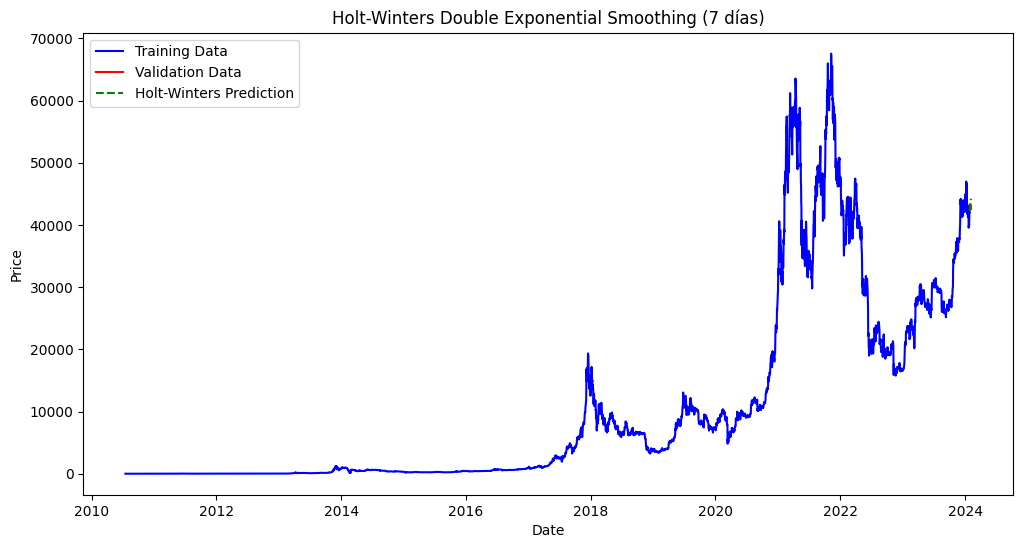

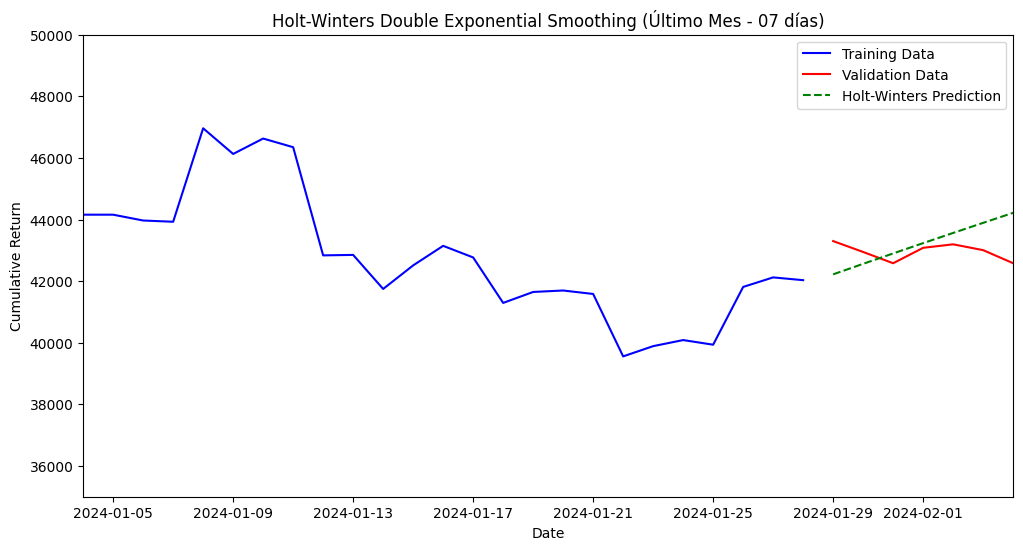

MAPE: 1.61%
MAE: 689.57
MSE: 719388.17
RMSE: 848.17
R² Score: -9.6062


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# División en entrenamiento, validación y test (entrenamiento fijo)
train_size = len(df) - (28 + 28)
train = df.iloc[:train_size]['Price']
val = df.iloc[train_size:train_size+7]['Price']  # Validación de 7 días
test = df.iloc[train_size+7:train_size+7+7]['Price']  # Test de 7 días

# Aplicar doble suavización Holt-Winters
alpha = 0.5  # Parámetro de nivel
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular los residuos (errores del modelo en el conjunto de entrenamiento)
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (7 días)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Visualización del último año de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(35000, 50000)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 07 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Variable Precio: Ventana 07 dias - Segunda parte.

       MAPE         MAE        RMSE            MSE        R²  \
0  1.607033  689.574329  848.167535  719388.167827 -9.606153   

   Ljung-Box (p-value)  Brock-Dechert-Scheinkman (p-value)  \
0        6.614373e-296                        7.220548e-09   

   Jarque-Bera (p-value)  
0                    0.0  


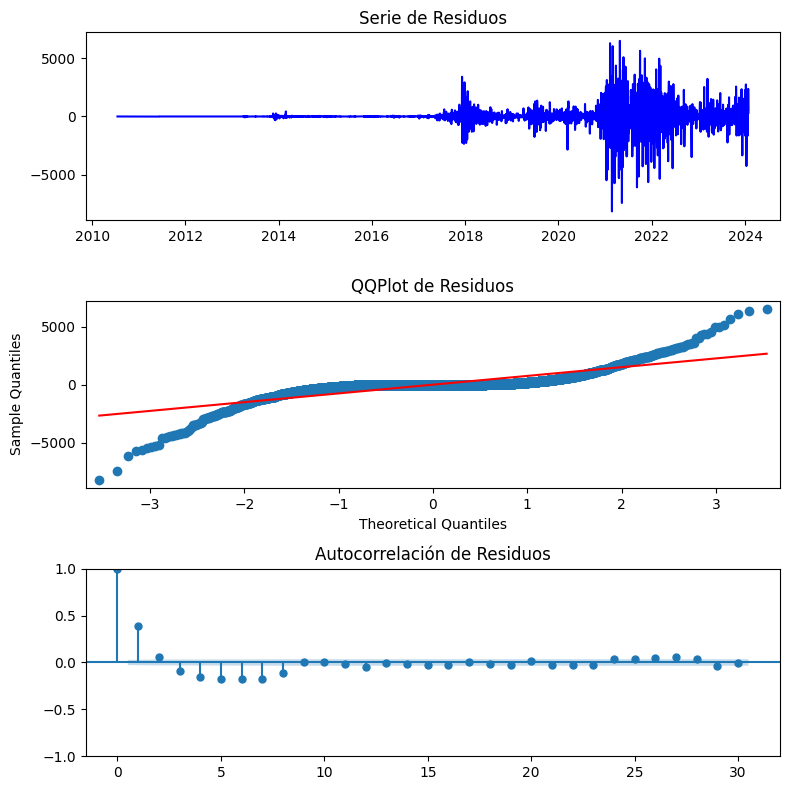

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from arch.unitroot import VarianceRatio

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Variable Precio: Ventana 14 dias - Primera parte.

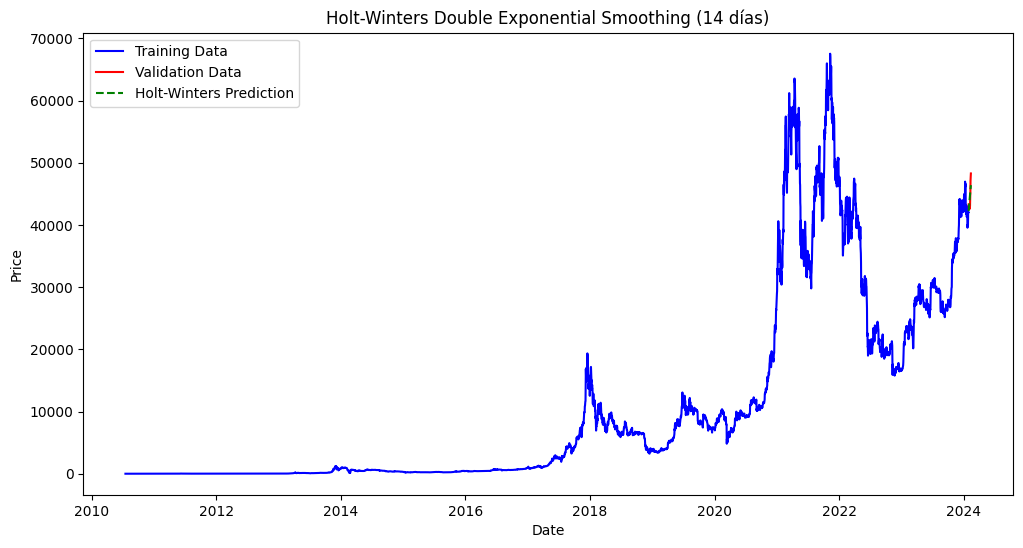

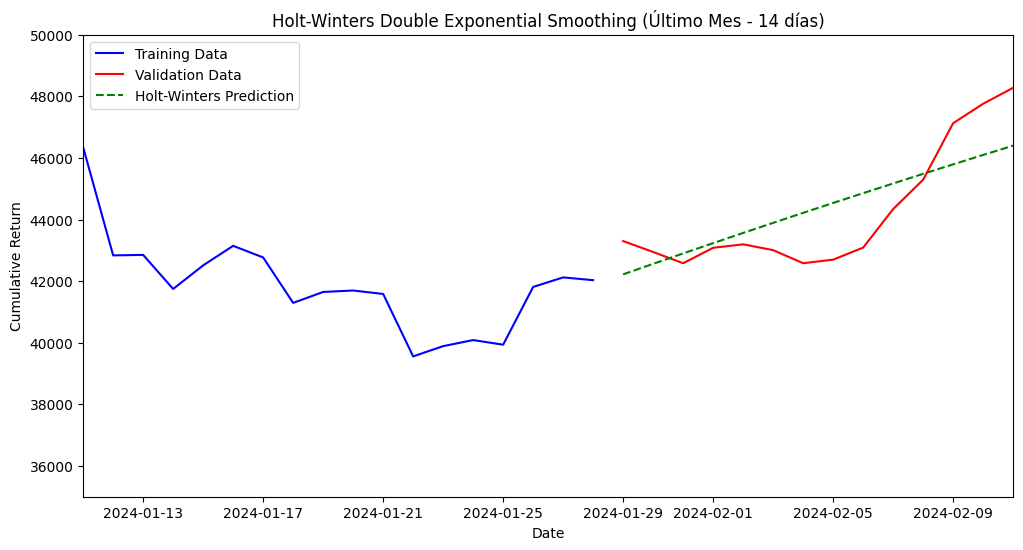

MAPE: 2.30%
MAE: 1023.76
MSE: 1453748.53
RMSE: 1205.71
R² Score: 0.6221


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# División en entrenamiento, validación y test para 14 días
train_size = len(df) - (28 + 28)  # El conjunto de entrenamiento es fijo
train = df.iloc[:train_size]['Price']
val = df.iloc[train_size:train_size+14]['Price']  # Validación de 14 días
test = df.iloc[train_size+14:train_size+14+14]['Price']  # Test de 14 días

# Aplicar doble suavización Holt-Winters
alpha = 0.5  # Parámetro de nivel
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular los residuos (errores del modelo en el conjunto de entrenamiento)
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (14 días)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Visualización del último año de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(35000, 50000)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 14 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Variable Precio: Ventana 14 dias - Segunda parte.

       MAPE          MAE         RMSE           MSE        R²  \
0  2.297289  1023.762866  1205.714944  1.453749e+06  0.622146   

   Ljung-Box (p-value)  Brock-Dechert-Scheinkman (p-value)  \
0        6.614373e-296                        7.220548e-09   

   Jarque-Bera (p-value)  
0                    0.0  


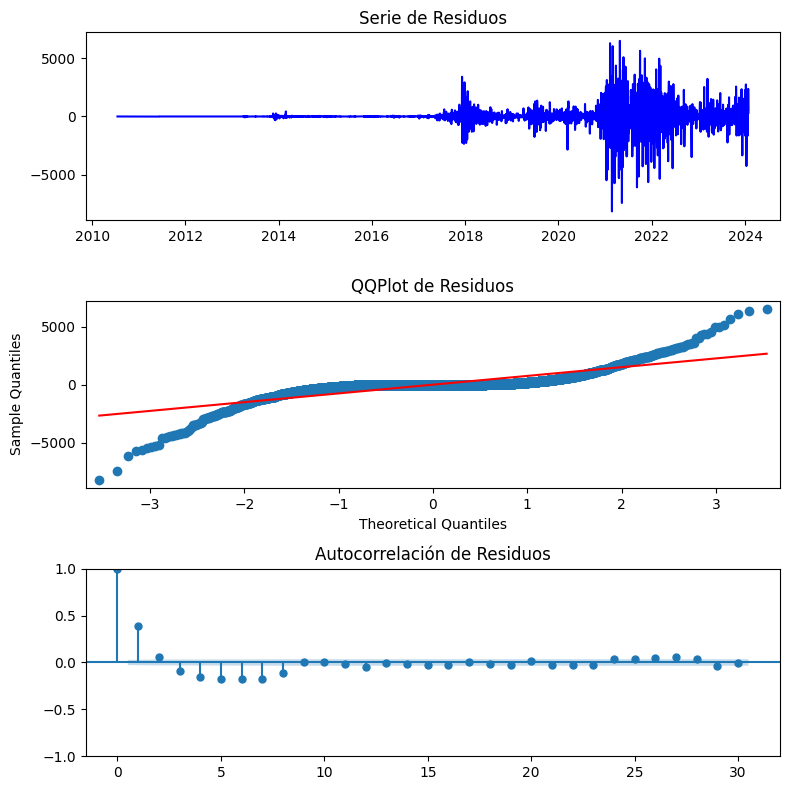

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from arch.unitroot import VarianceRatio

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Variable Precio: Ventana 21 dias - Primera parte.

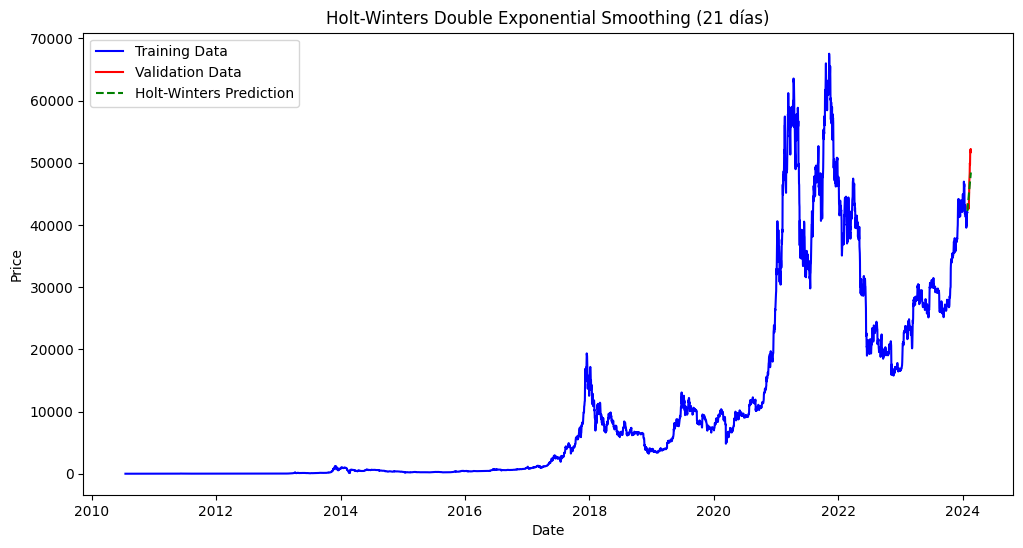

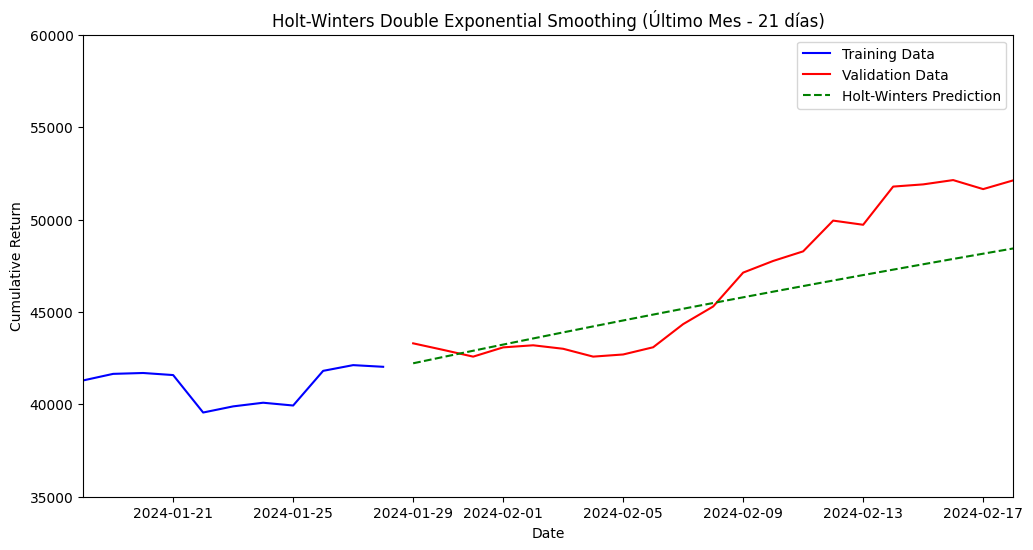

MAPE: 3.96%
MAE: 1931.46
MSE: 5769483.44
RMSE: 2401.97
R² Score: 0.5888
MAPE: 3.96%
MAE: 1931.46
MSE: 5769483.44
RMSE: 2401.97
R² Score: 0.5888


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# División en entrenamiento, validación y test para 21 días
train_size = len(df) - (28 + 28)
train = df.iloc[:train_size]['Price']
val = df.iloc[train_size:train_size+21]['Price']
test = df.iloc[train_size+21:]['Price']

# Aplicar doble suavización Holt-Winters
alpha = 0.5  # Parámetro de nivel
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular los residuos (errores del modelo en el conjunto de entrenamiento)
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (21 días)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Visualización del último año de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(35000, 60000)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 21 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mean_absolute_error(val, val_pred):.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Variable Precio: Ventana 21 dias - Segunda parte.

      MAPE          MAE         RMSE           MSE       R²  \
0  3.95995  1931.457935  2401.974903  5.769483e+06  0.58877   

   Ljung-Box (p-value)  Brock-Dechert-Scheinkman (p-value)  \
0        6.614373e-296                        7.220548e-09   

   Jarque-Bera (p-value)  
0                    0.0  


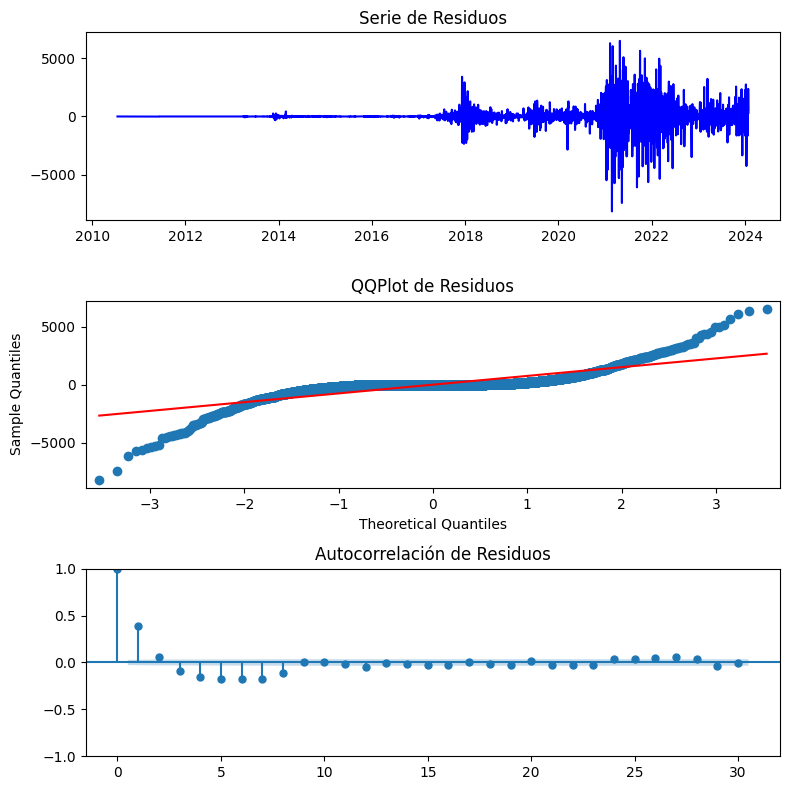

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from arch.unitroot import VarianceRatio

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Variable Precio: Ventana 28 dias - Primera parte.

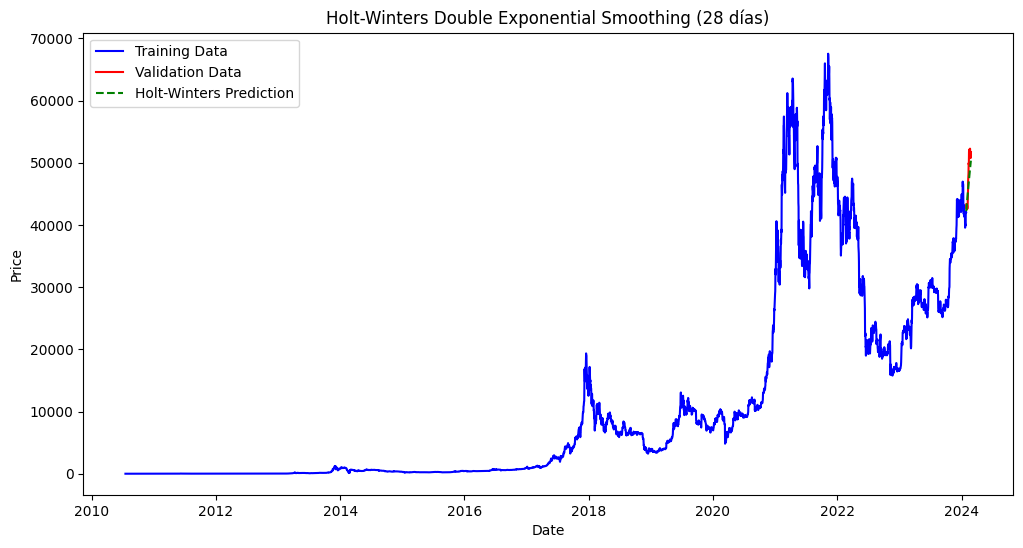

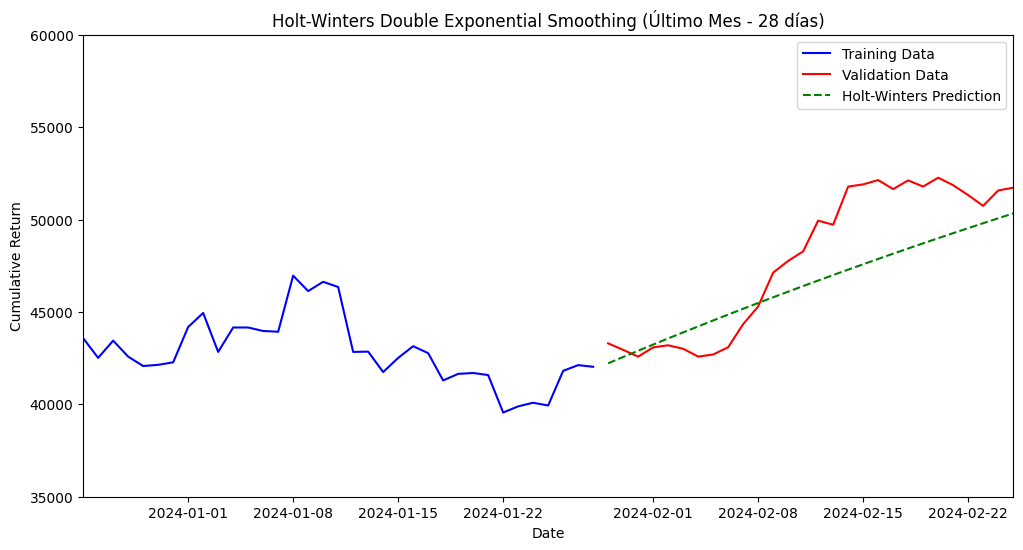

MAPE: 3.98%
MAE: 1968.95
MSE: 5583928.67
RMSE: 2363.03
R² Score: 0.6346


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# División en entrenamiento, validación y test
train_size = len(df) - (28 + 28)
train = df.iloc[:train_size]['Price']
val = df.iloc[train_size:train_size+28]['Price']
test = df.iloc[train_size+28:]['Price']

# Calcular los residuos (errores del modelo en el conjunto de entrenamiento)
residuals = train - hw_model.fittedvalues

# Aplicar doble suavización Holt-Winters
alpha = 0.5  # Parámetro de nivel
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (28 días)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Visualización del último año de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=2)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(35000, 60000)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 28 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')


Precio: Ventana 28 dias - Segunda parte.

       MAPE         MAE         RMSE           MSE        R²  \
0  3.975486  1968.95096  2363.033785  5.583929e+06  0.634637   

   Ljung-Box (p-value)  Brock-Dechert-Scheinkman (p-value)  \
0        6.614373e-296                        7.220548e-09   

   Jarque-Bera (p-value)  
0                    0.0  


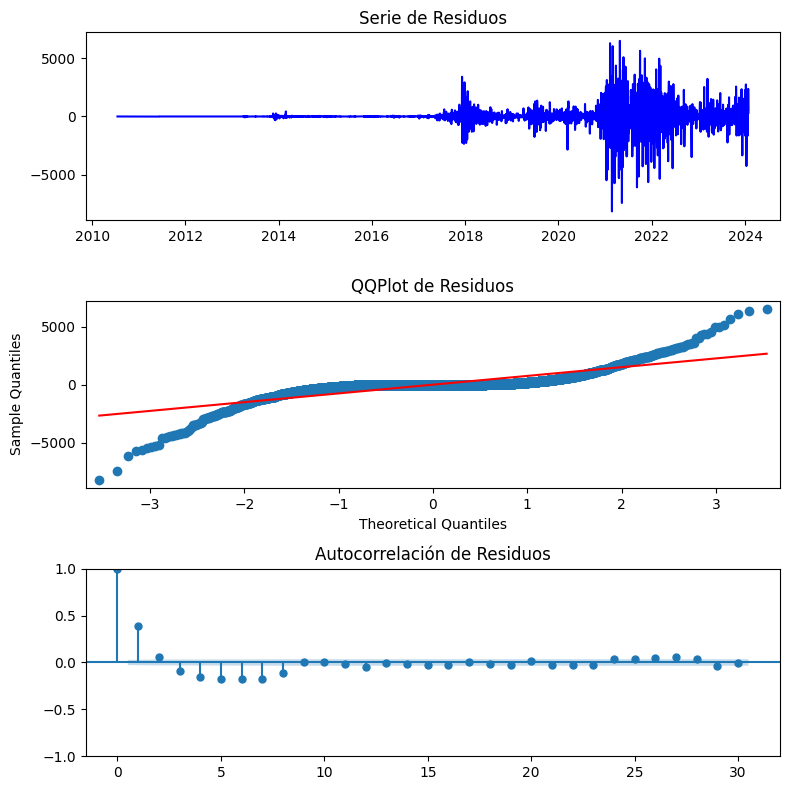

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from arch.unitroot import VarianceRatio

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Retorno Acumulado: Ventana 07 dias - Primera parte.

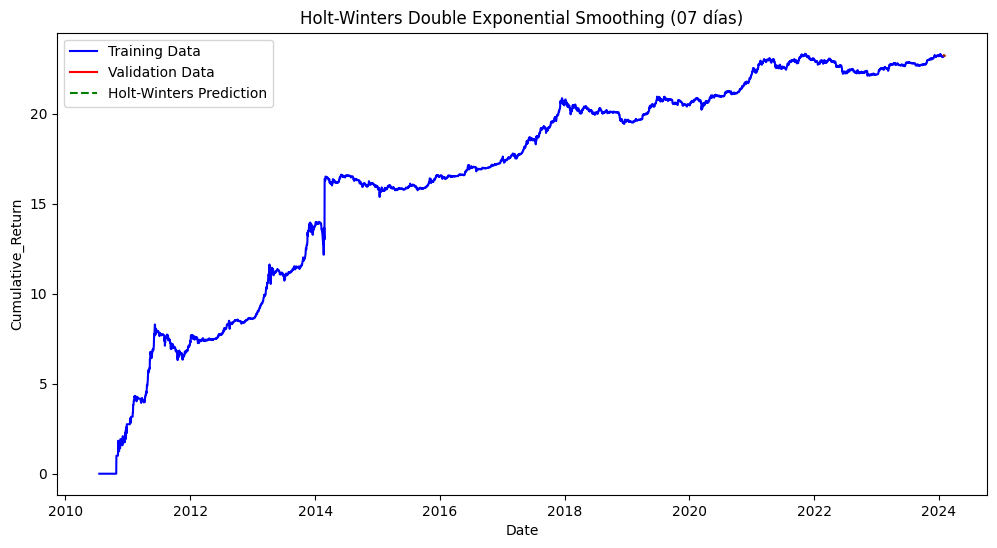

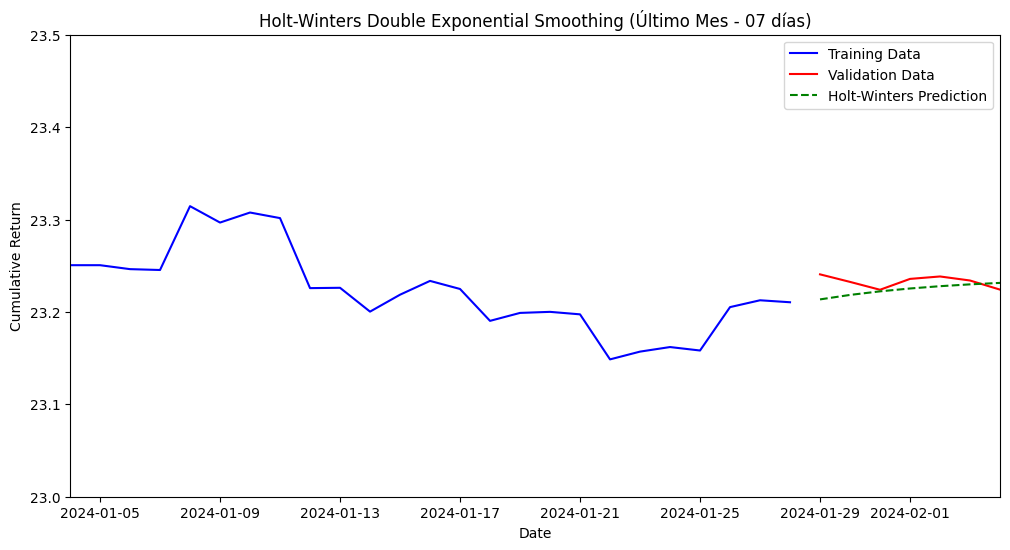

MAPE: 0.05%
MAE: 0.01
MSE: 0.00
RMSE: 0.01
R² Score: -3.7858


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# División en entrenamiento, validación y test para 7 días
train_size = len(df) - (28 + 28)  # El conjunto de entrenamiento es fijo
train = df.iloc[:train_size]['Cumulative_Return']
val = df.iloc[train_size:train_size+7]['Cumulative_Return']  # Validación de 7 días
test = df.iloc[train_size+7:train_size+7+7]['Cumulative_Return']  # Test de 7 días

# Aplicar doble suavización Holt-Winters
alpha = 0.5  # Parámetro de nivel
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular los residuos (errores del modelo en el conjunto de entrenamiento)
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (07 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative_Return')
plt.show()

# Visualización del último año de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(23, 23.5)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 07 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mean_absolute_error(val, val_pred):.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Retorno Acumulado: Ventana 07 dias - Segunda parte.

       MAPE       MAE      RMSE       MSE        R²  Ljung-Box (p-value)  \
0  0.046269  0.010751  0.013229  0.000175 -3.785782        1.508391e-127   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.177048                    0.0  


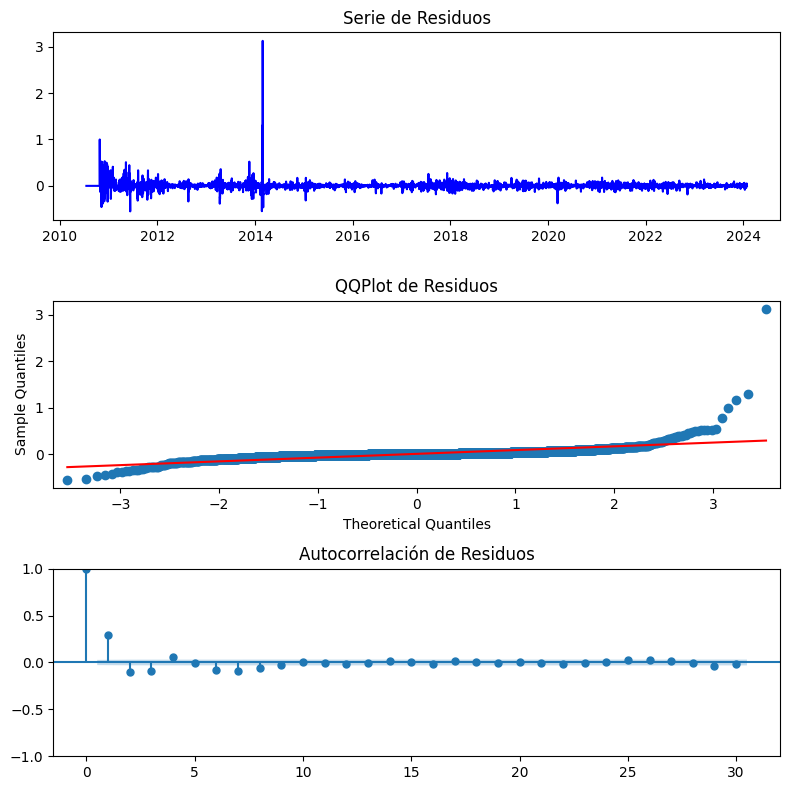

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from arch.unitroot import VarianceRatio

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Retorno Acumulado: Ventana 14 dias - Primera parte.

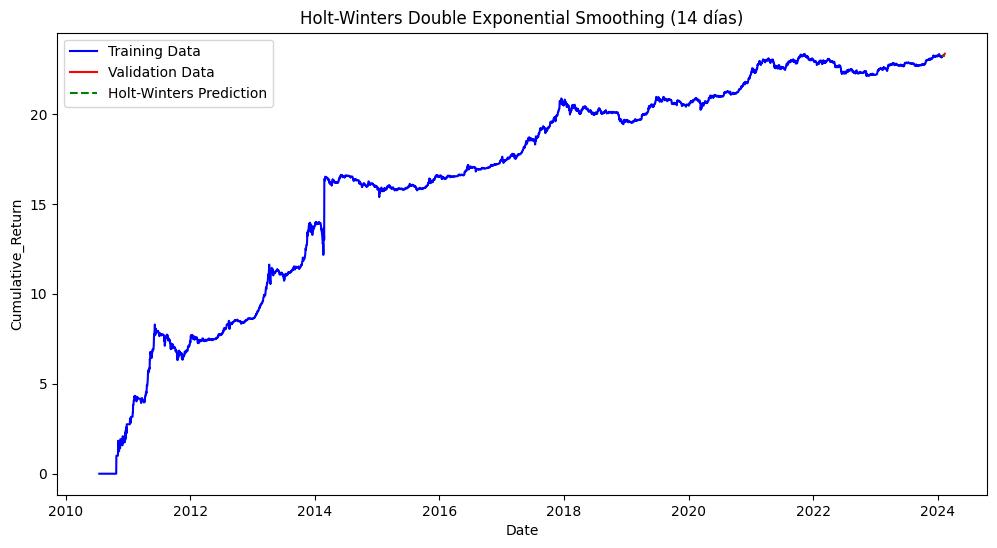

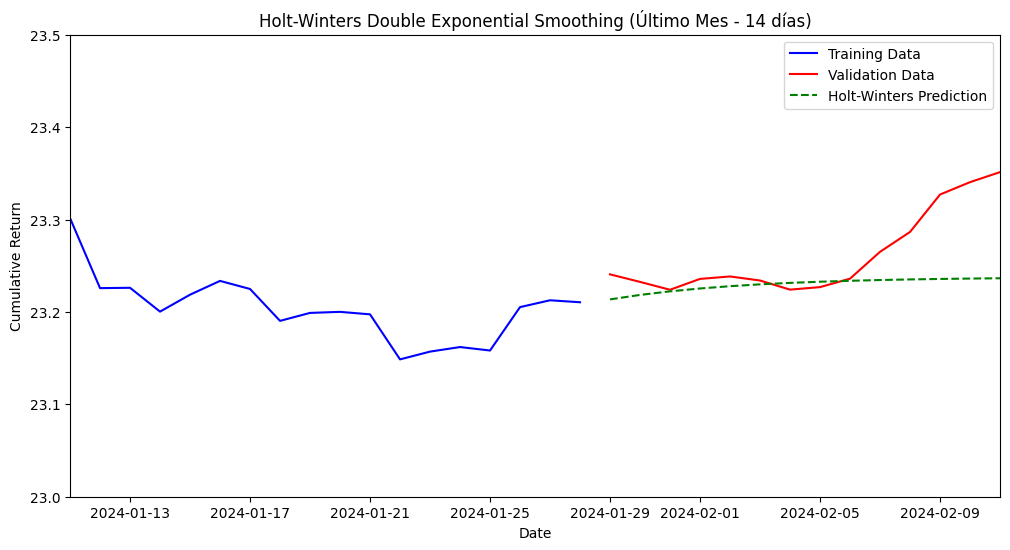

MAPE: 0.15%
MAE: 0.03
MSE: 0.00
RMSE: 0.05
R² Score: -0.3742


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# División en entrenamiento, validación y test para 14 días
train_size = len(df) - (28 + 28)  # El conjunto de entrenamiento es fijo
train = df.iloc[:train_size]['Cumulative_Return']
val = df.iloc[train_size:train_size+14]['Cumulative_Return']  # Validación de 14 días
test = df.iloc[train_size+14:train_size+14+14]['Cumulative_Return']  # Test de 14 días

# Aplicar doble suavización Holt-Winters
alpha = 0.5  # Parámetro de nivel
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular los residuos (errores del modelo en el conjunto de entrenamiento)
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (14 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative_Return')
plt.show()

# Visualización del último año de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')


# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(23, 23.5)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 14 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Retorno Acumulado: Ventana 14 dias - Segunda parte.

      MAPE       MAE      RMSE       MSE        R²  Ljung-Box (p-value)  \
0  0.14582  0.033993  0.051595  0.002662 -0.374168        1.508391e-127   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.177048                    0.0  


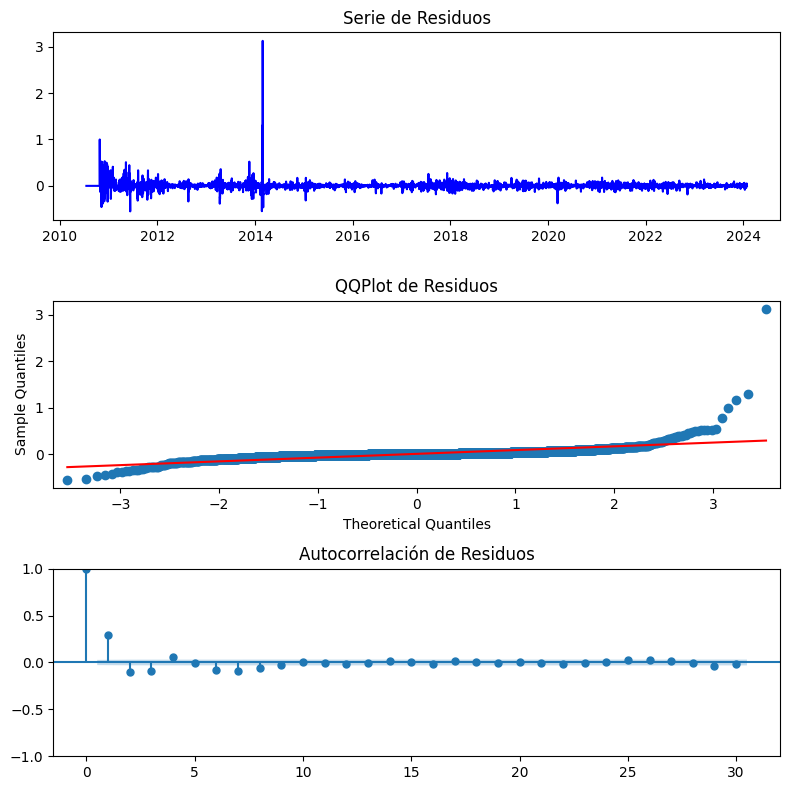

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from arch.unitroot import VarianceRatio

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Retorno Acumulado: Ventana 21 dias - Primera parte.

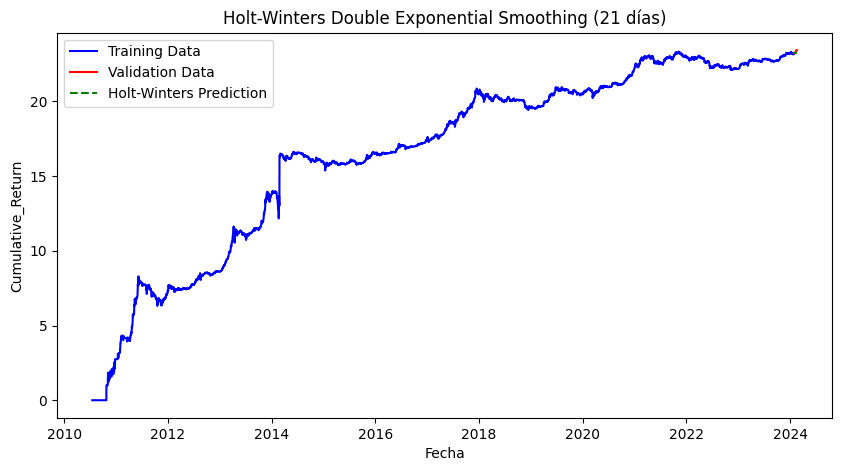

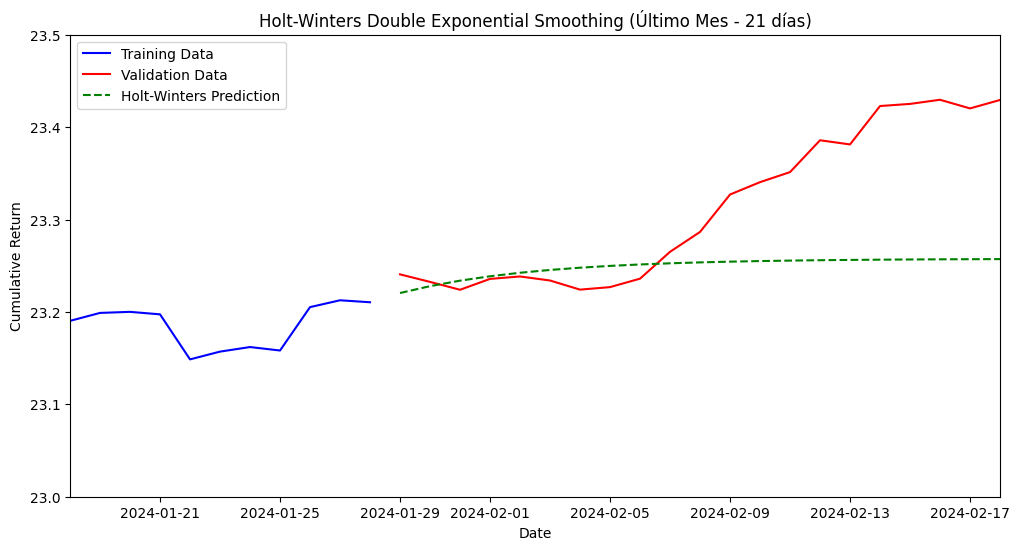

MAPE: 0.31%
MAE: 0.07
MSE: 0.01
RMSE: 0.10
R² Score: -0.4534


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Definir el tamaño del conjunto de entrenamiento (fijo)
train_size = len(df) - (28 + 28)  # Se resta 21 días de validación y 21 días de prueba

# Dividir la serie temporal en conjuntos de entrenamiento, validación y prueba
train = df.iloc[:train_size]['Cumulative_Return']
val = df.iloc[train_size:train_size+21]['Cumulative_Return']
test = df.iloc[train_size+21:train_size+42]['Cumulative_Return']

# Aplicar modelo Holt-Winters con suavización exponencial
alpha = 0.5  # Parámetro de suavización
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=alpha)
val_pred = hw_model.forecast(steps=len(val))

# Calcular residuos
residuos = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.xlabel('Fecha')
plt.ylabel('Cumulative_Return')
plt.title('Holt-Winters Double Exponential Smoothing (21 días)')
plt.legend()
plt.show()

# Zoom de  resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(23, 23.5)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 21 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Retorno Acumulado: Ventana 21 dias - Segunda parte.

      MAPE       MAE      RMSE       MSE       R²  Ljung-Box (p-value)  \
0  0.30783  0.071986  0.097482  0.009503 -0.45339        1.508391e-127   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.177048                    0.0  


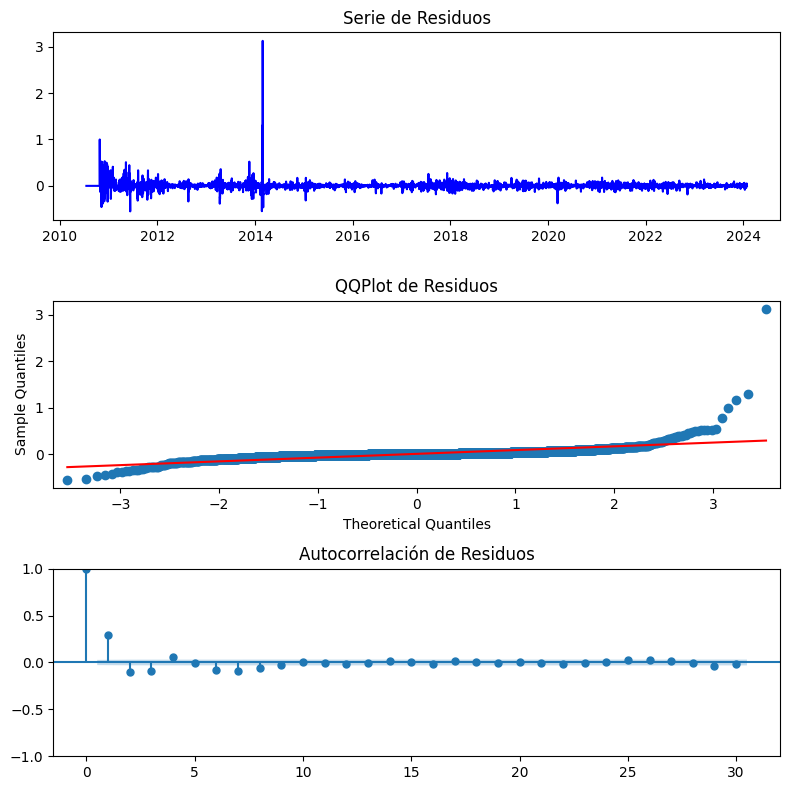

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Retorno Acumulado: Ventana 28 dias - Primera parte.

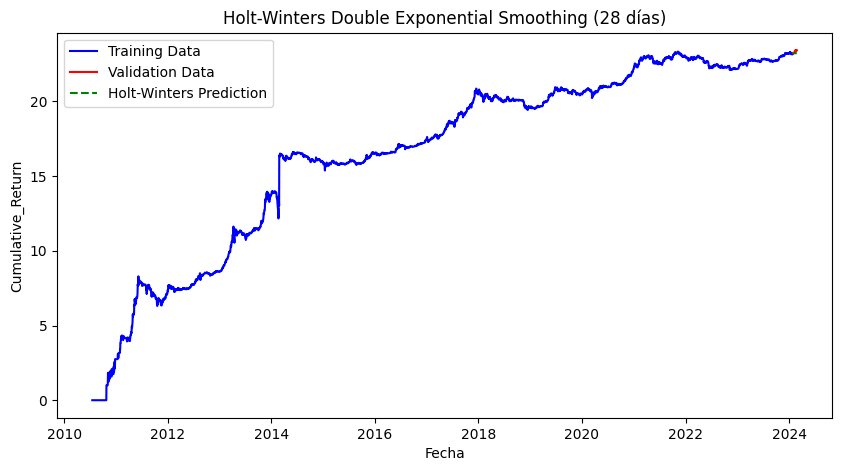

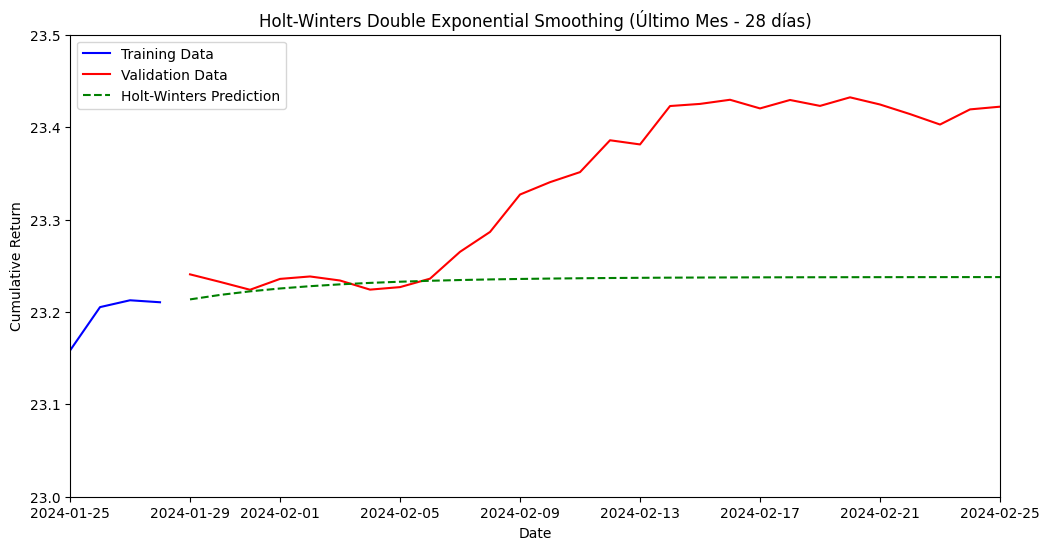

MAPE: 0.46%
MAE: 0.11
MSE: 0.02
RMSE: 0.13
R² Score: -1.4686


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Definir el tamaño del conjunto de entrenamiento (fijo)
train_size = len(df) - (28 + 28)  # Se resta 28 días de validación y 28 días de prueba

# Dividir la serie temporal en conjuntos de entrenamiento, validación y prueba
train = df.iloc[:train_size]['Cumulative_Return']
val = df.iloc[train_size:train_size+28]['Cumulative_Return']
test = df.iloc[train_size+28:train_size+56]['Cumulative_Return']

# Aplicar modelo Holt-Winters con suavización exponencial
alpha = 0.5  # Parámetro de suavización
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular residuos
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.xlabel('Fecha')
plt.ylabel('Cumulative_Return')
plt.title('Holt-Winters Double Exponential Smoothing (28 días)')
plt.legend()
plt.show()

# Zoom de  resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(23, 23.5)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 28 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Retorno Acumulado: Ventana 28 dias - Segunda parte.

       MAPE       MAE      RMSE       MSE        R²  Ljung-Box (p-value)  \
0  0.455481  0.106586  0.132275  0.017497 -1.468552        1.508391e-127   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.177048                    0.0  


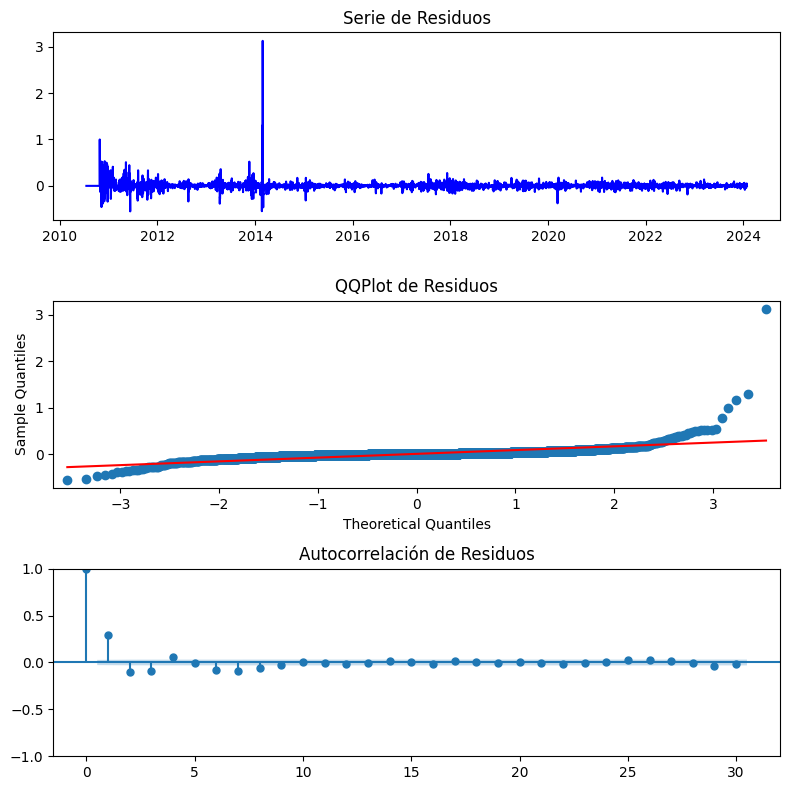

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Volatilidad: Ventana 07 días - Primera parte

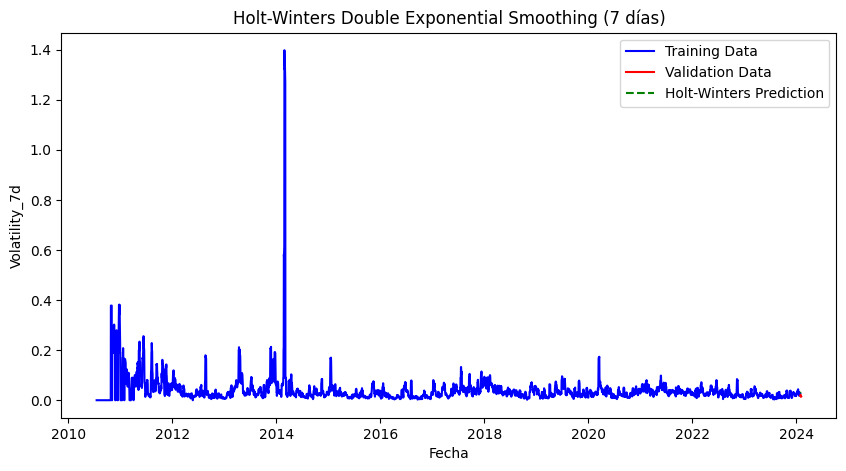

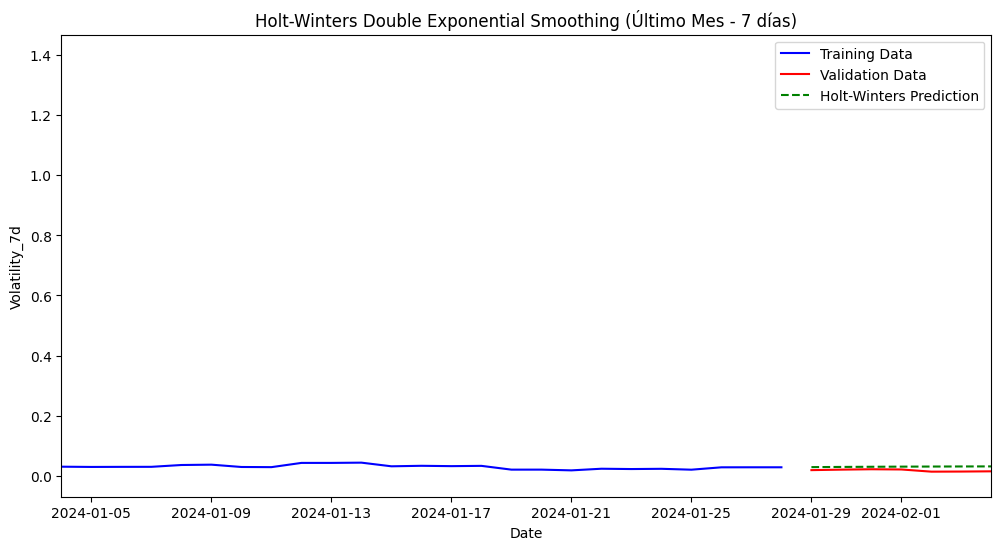

MAPE: 77.38%
MAE: 0.01
MSE: 0.00
RMSE: 0.01
R² Score: -15.1827


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_7d"]]

# Definir el tamaño del conjunto de entrenamiento (fijo)
train_size = len(df) - (28 + 28)  # Se resta 28 días de validación y 28 días de prueba

# Dividir la serie temporal en conjuntos de entrenamiento, validación y prueba (7 días de validación y prueba)
train = df.iloc[:train_size]['Volatility_7d']
val = df.iloc[train_size:train_size+7]['Volatility_7d']
test = df.iloc[train_size+7:train_size+14]['Volatility_7d']

# Aplicar modelo Holt-Winters con suavización exponencial
alpha = 0.5  # Parámetro de suavización
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular residuos
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.xlabel('Fecha')
plt.ylabel('Volatility_7d')
plt.title('Holt-Winters Double Exponential Smoothing (7 días)')
plt.legend()
plt.show()

# Zoom de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 7 días)')
plt.xlabel('Date')
plt.ylabel('Volatility_7d')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Volatilidad: Ventana 07 días - Segunda parte

        MAPE       MAE      RMSE       MSE         R²  Ljung-Box (p-value)  \
0  77.380763  0.012434  0.013002  0.000169 -15.182702                  0.0   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.220369                    0.0  


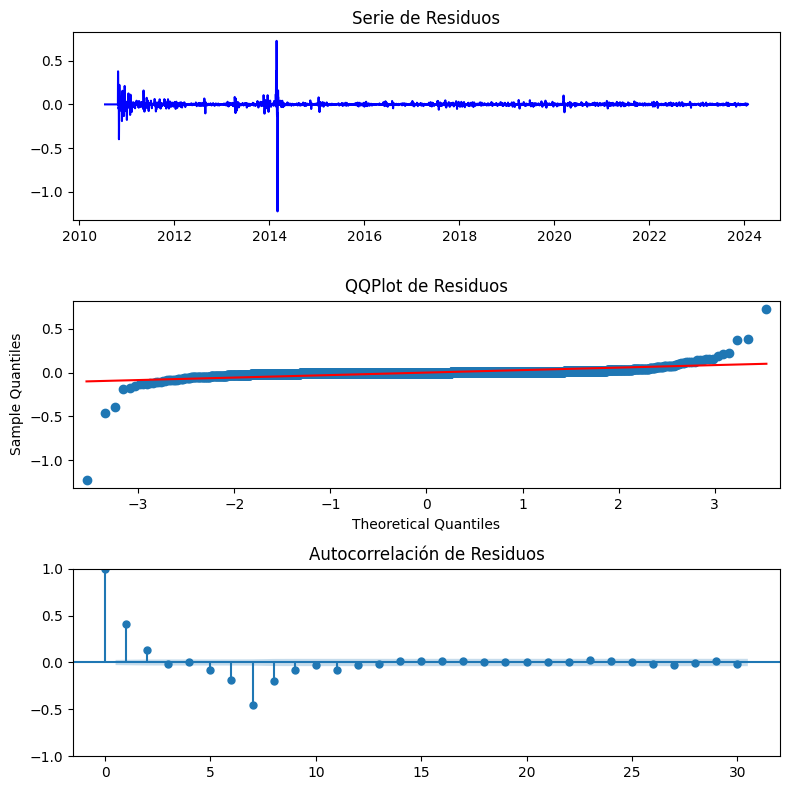

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_7d"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Volatilidad: Ventana 14 días - Primera parte

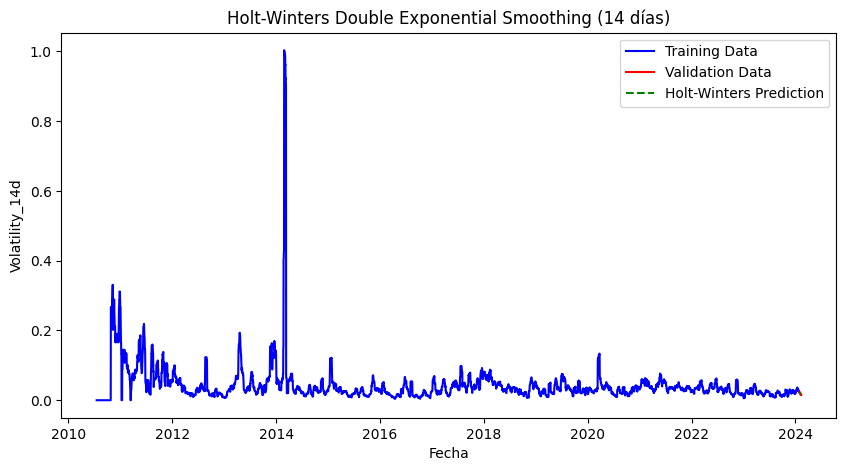

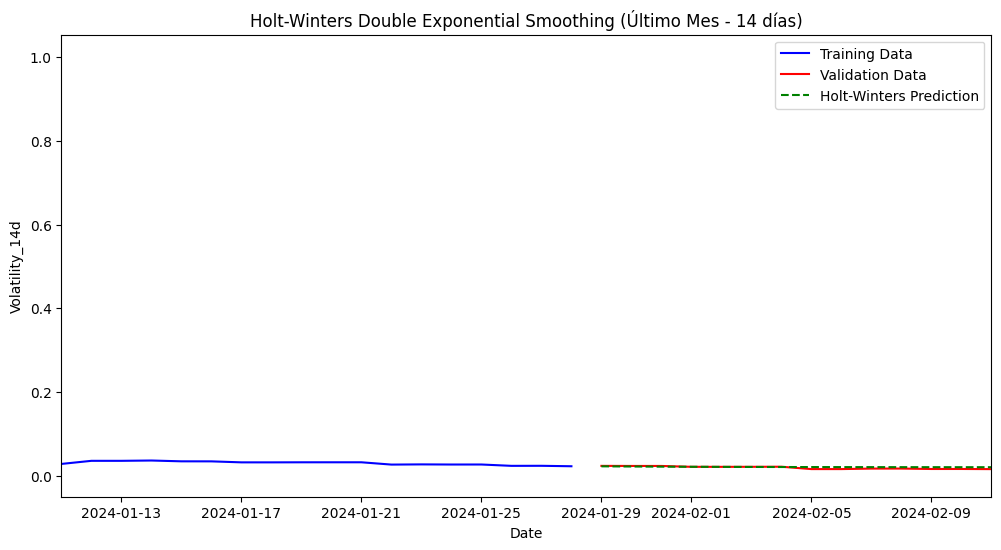

MAPE: 14.80%
MAE: 0.00
MSE: 0.00
RMSE: 0.00
R² Score: -0.0069


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_14d"]]

# Definir el tamaño del conjunto de entrenamiento (fijo)
train_size = len(df) - (28 + 28)  # Se resta 28 días de validación y 28 días de prueba

# Dividir la serie temporal en conjuntos de entrenamiento, validación y prueba (14 días de validación y prueba)
train = df.iloc[:train_size]['Volatility_14d']
val = df.iloc[train_size:train_size+14]['Volatility_14d']
test = df.iloc[train_size+14:train_size+28]['Volatility_14d']

# Aplicar modelo Holt-Winters con suavización exponencial
alpha = 0.5  # Parámetro de suavización
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular residuos
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.xlabel('Fecha')
plt.ylabel('Volatility_14d')
plt.title('Holt-Winters Double Exponential Smoothing (14 días)')
plt.legend()
plt.show()

# Zoom de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 14 días)')
plt.xlabel('Date')
plt.ylabel('Volatility_14d')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Volatilidad: Ventana 14 días - Segunda parte

        MAPE       MAE      RMSE      MSE        R²  Ljung-Box (p-value)  \
0  14.800085  0.002504  0.003104  0.00001 -0.006932        9.202753e-148   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.298405                    0.0  


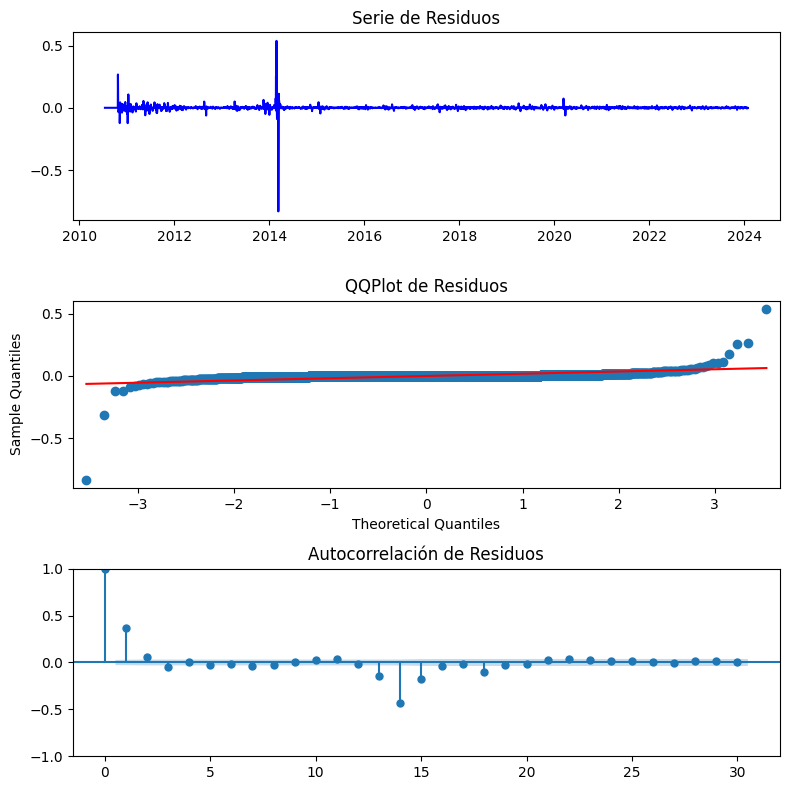

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_14d"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Volatilidad: Ventana 21 días - Primera parte

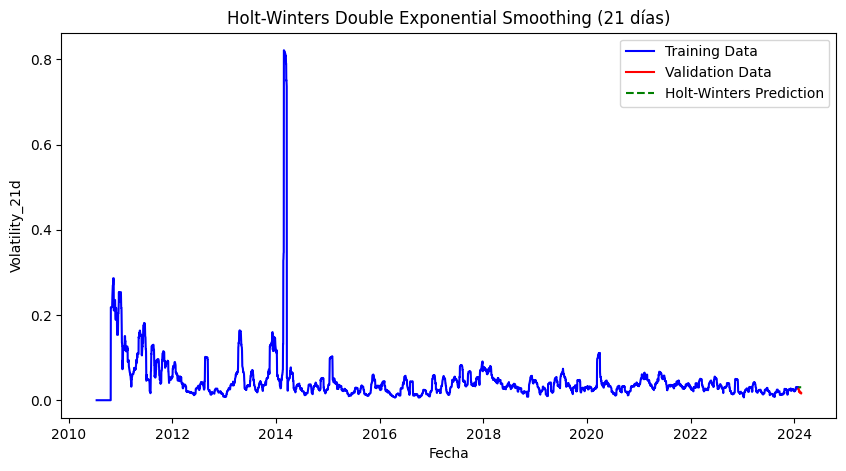

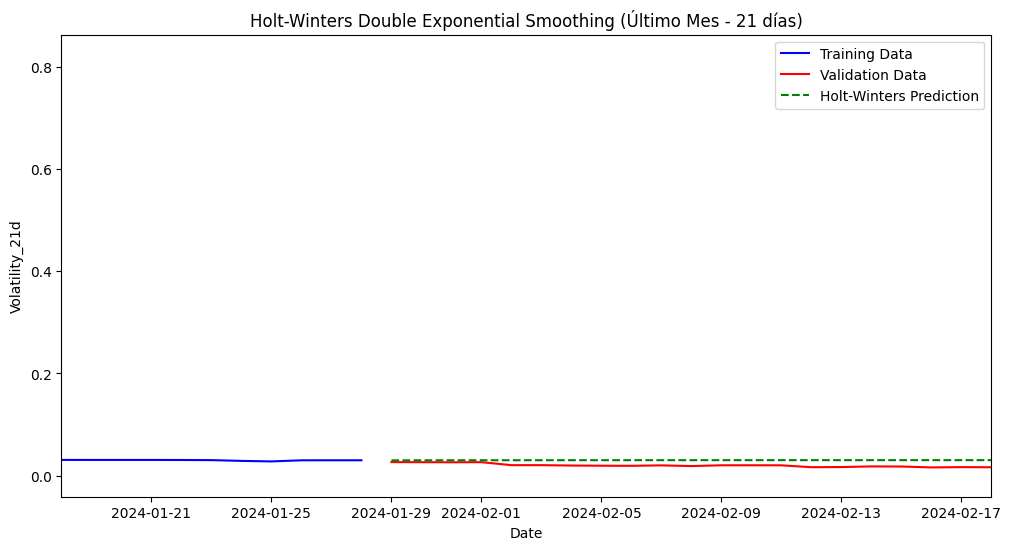

MAPE: 53.54%
MAE: 0.01
MSE: 0.00
RMSE: 0.01
R² Score: -9.2236


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_21d"]]

# Definir el tamaño del conjunto de entrenamiento (fijo)
train_size = len(df) - (28 + 28)  # Se resta 28 días de validación y 28 días de prueba

# Dividir la serie temporal en conjuntos de entrenamiento, validación y prueba (21 días de validación y prueba)
train = df.iloc[:train_size]['Volatility_21d']
val = df.iloc[train_size:train_size+21]['Volatility_21d']
test = df.iloc[train_size+21:train_size+42]['Volatility_21d']

# Aplicar modelo Holt-Winters con suavización exponencial
alpha = 0.5  # Parámetro de suavización
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular residuos
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.xlabel('Fecha')
plt.ylabel('Volatility_21d')
plt.title('Holt-Winters Double Exponential Smoothing (21 días)')
plt.legend()
plt.show()

# Zoom de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 21 días)')
plt.xlabel('Date')
plt.ylabel('Volatility_21d')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Volatilidad: Ventana 21 días - Segunda parte

        MAPE      MAE      RMSE       MSE        R²  Ljung-Box (p-value)  \
0  53.542646  0.01009  0.010656  0.000114 -9.223559        2.682208e-156   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.324522                    0.0  


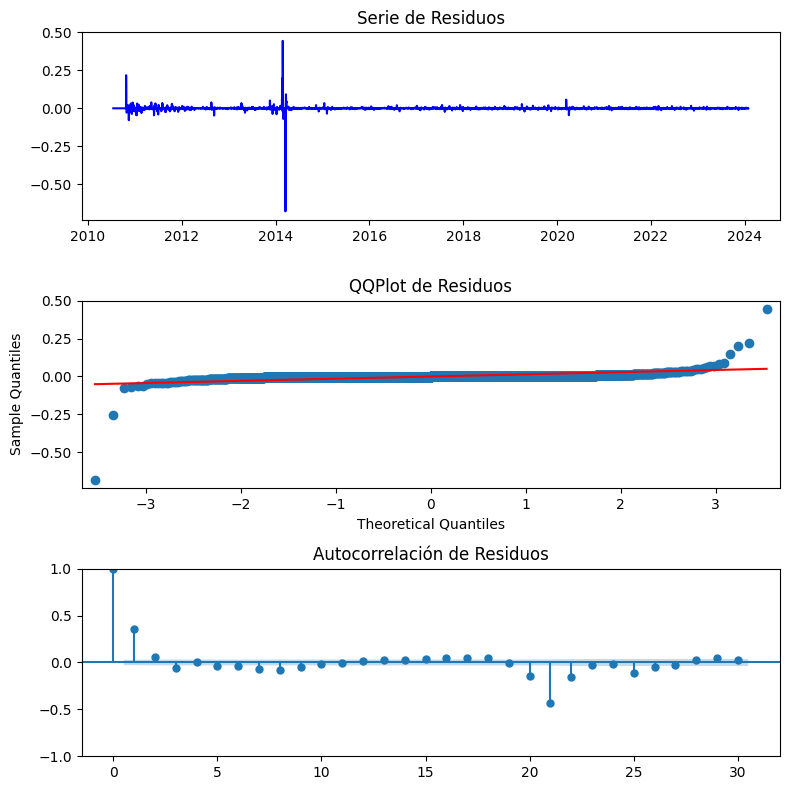

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_21d"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Volatilidad: Ventana 28 días - Primera parte

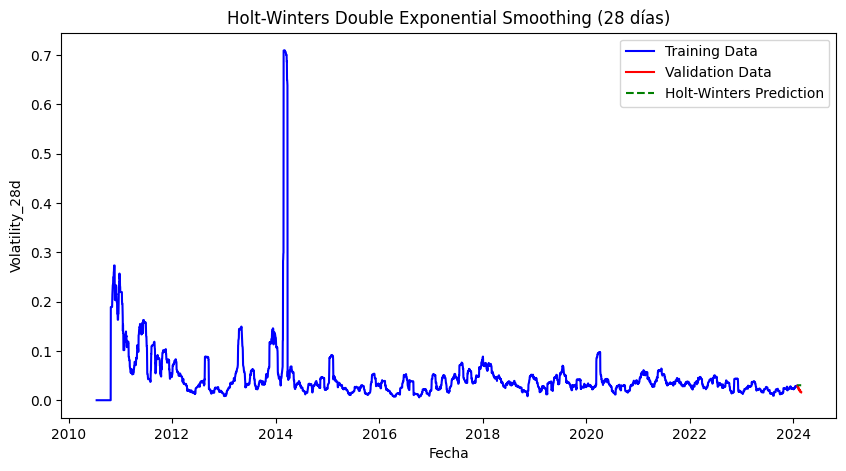

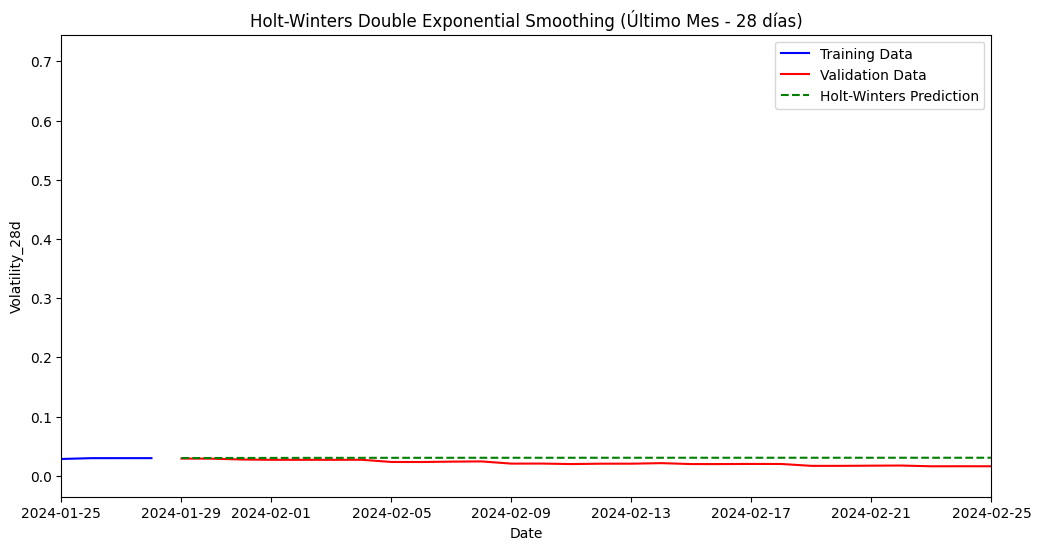

MAPE: 45.45%
MAE: 0.01
MSE: 0.00
RMSE: 0.01
R² Score: -4.4975


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_28d"]]

# Definir el tamaño del conjunto de entrenamiento (fijo)
train_size = len(df) - (28 + 28)  # Se resta 28 días de validación y 28 días de prueba

# Dividir la serie temporal en conjuntos de entrenamiento, validación y prueba (28 días de validación y prueba)
train = df.iloc[:train_size]['Volatility_28d']
val = df.iloc[train_size:train_size+28]['Volatility_28d']
test = df.iloc[train_size+28:train_size+56]['Volatility_28d']

# Aplicar modelo Holt-Winters con suavización exponencial
alpha = 0.5  # Parámetro de suavización
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular residuos
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.xlabel('Fecha')
plt.ylabel('Volatility_28d')
plt.title('Holt-Winters Double Exponential Smoothing (28 días)')
plt.legend()
plt.show()

# Zoom de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 28 días)')
plt.xlabel('Date')
plt.ylabel('Volatility_28d')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Volatilidad: Ventana 28 días - Segunda parte

        MAPE       MAE      RMSE       MSE       R²  Ljung-Box (p-value)  \
0  45.448421  0.008682  0.009666  0.000093 -4.49746        1.988208e-147   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.329657                    0.0  


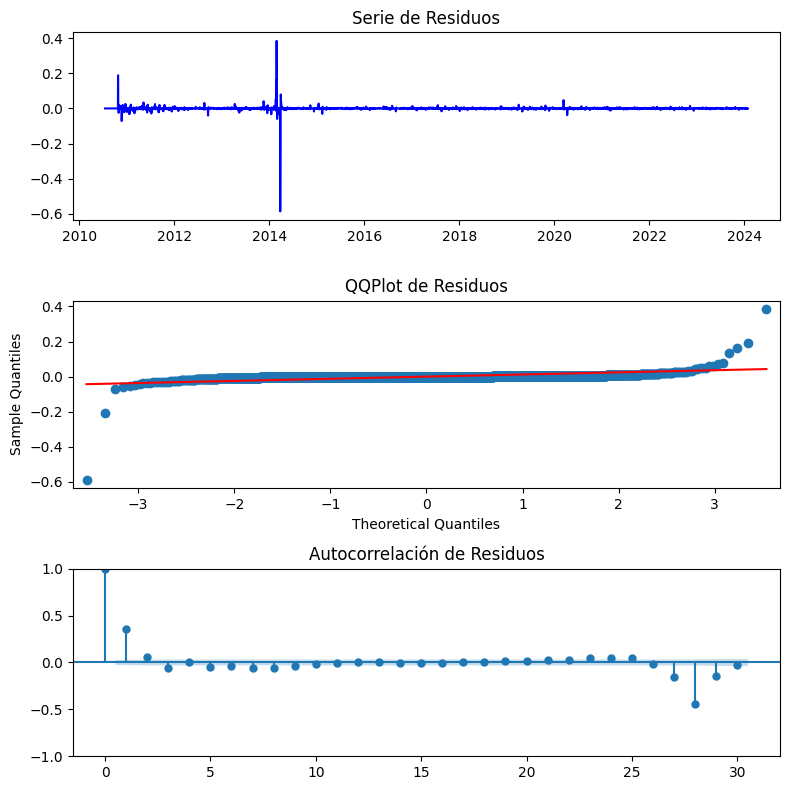

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_28d"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()